# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


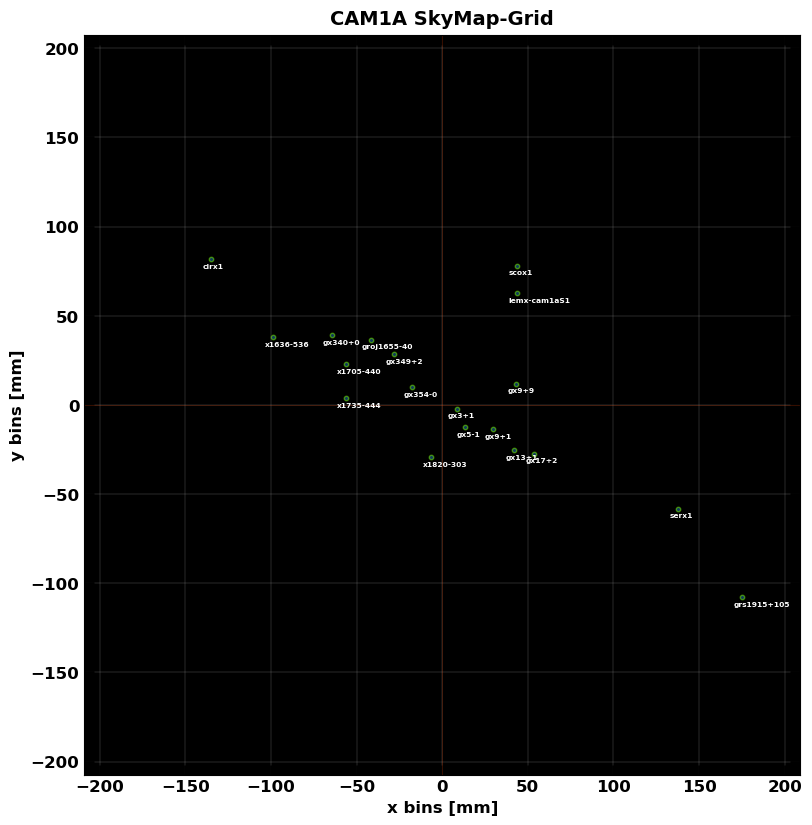

,CAM1A,CAM1A SNR,CAM1A SX,CAM1A SY
0,scox1,749.152433,43.909233,78.034729
1,gx5-1,78.307137,13.525157,-12.530141
2,gx349+2,60.073791,-28.163703,28.647628
3,gx17+2,51.405661,53.591681,-27.281381
4,gx9+1,46.722344,29.852447,-13.424243
5,gx340+0,34.820543,-64.630984,39.059065
6,groj1655-40,29.005915,-41.782597,36.564674
7,gx3+1,26.115363,8.412702,-2.092406
8,gx13+1,25.410615,41.882117,-25.187341
9,x1820-303,24.144542,-6.263894,-29.313634


In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds

def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)



skyfield = "GalacticCenter"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
#cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
#simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, _ = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")


ds.skyfield_map(
    log=log_camA,
    camera=wfm,
)
pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        f"{log_camA.name} SX": log_camA.log['shift_x'],
        f"{log_camA.name} SY": log_camA.log['shift_y'],
    },
)

In [18]:
from typing import NamedTuple

from numpy.typing import NDArray

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.optim import model_shadowgram # as bm_shadowgram

# from fract_shift import model_shadowgram


class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float

def retrieve_detector(
    candidates: tuple[Candidate],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    img = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        shadowgram = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        img += (f * shadowgram)
    return img


_UP_TO = 9

candidates = tuple(
    Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
        log_camA.log['shift_x'][:_UP_TO],
        log_camA.log['shift_y'][:_UP_TO],
        log_camA.log['fluence'][:_UP_TO],
        log_camA.log['snr'][:_UP_TO],
    )
)

print(
    f"Selected sources: {len(candidates)}\n"
    f"{log_camA.log['ID'][:_UP_TO]}"
)

Selected sources: 9
['scox1', 'gx5-1', 'gx349+2', 'gx17+2', 'gx9+1', 'gx340+0', 'groj1655-40', 'gx3+1', 'gx13+1']


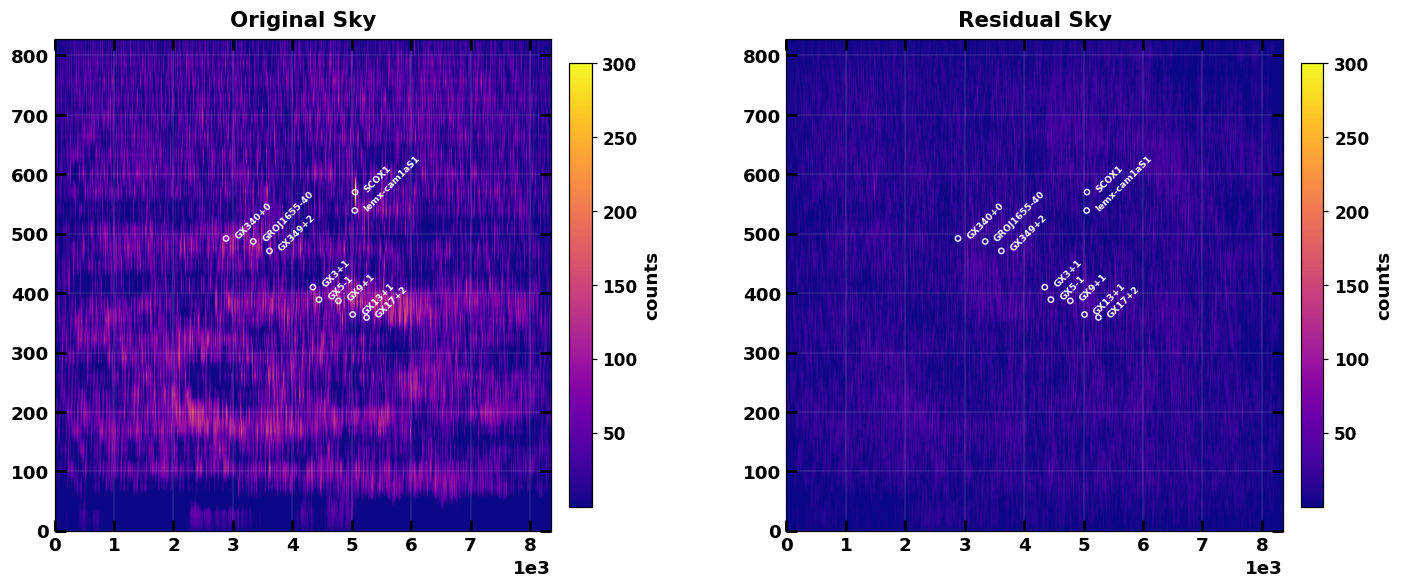

In [19]:
from bloodmoon.mask import count, decode

from darksun.types import Tag
from darksun.optim import bkg_smoothing

from var import sky_variance, sky_significance

detector = count(wfm, sdlA.DLdata)[0]
varmap = sky_variance(wfm, detector)
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

# residual detector
retrieved = retrieve_detector(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
retrieved_sky = decode(wfm, retrieved)
resdet = detector - retrieved
res_sky = decode(wfm, resdet)


EXP = 0.5
tags = tuple(
    Tag(ID.upper(), y, x) for ID, y, x in zip(
        log_camA.log['ID'][:_UP_TO], log_camA.log['y'][:_UP_TO], log_camA.log['x'][:_UP_TO],
    )
)
ghost_tag = Tag(
    ID=f'{log_camA.log['ID'][-1]}', y=log_camA.log['y'][-1], x=log_camA.log['x'][-1],
)
tags = (*tags, ghost_tag)

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=sqrt_display(simul_sky_camA, EXP),
            title='Original Sky',
            cbarlabel='counts',
            tags=tags,
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 300,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_sky, EXP),
            title='Residual Sky',
            cbarlabel='counts',
            tags=tags,
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 300,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

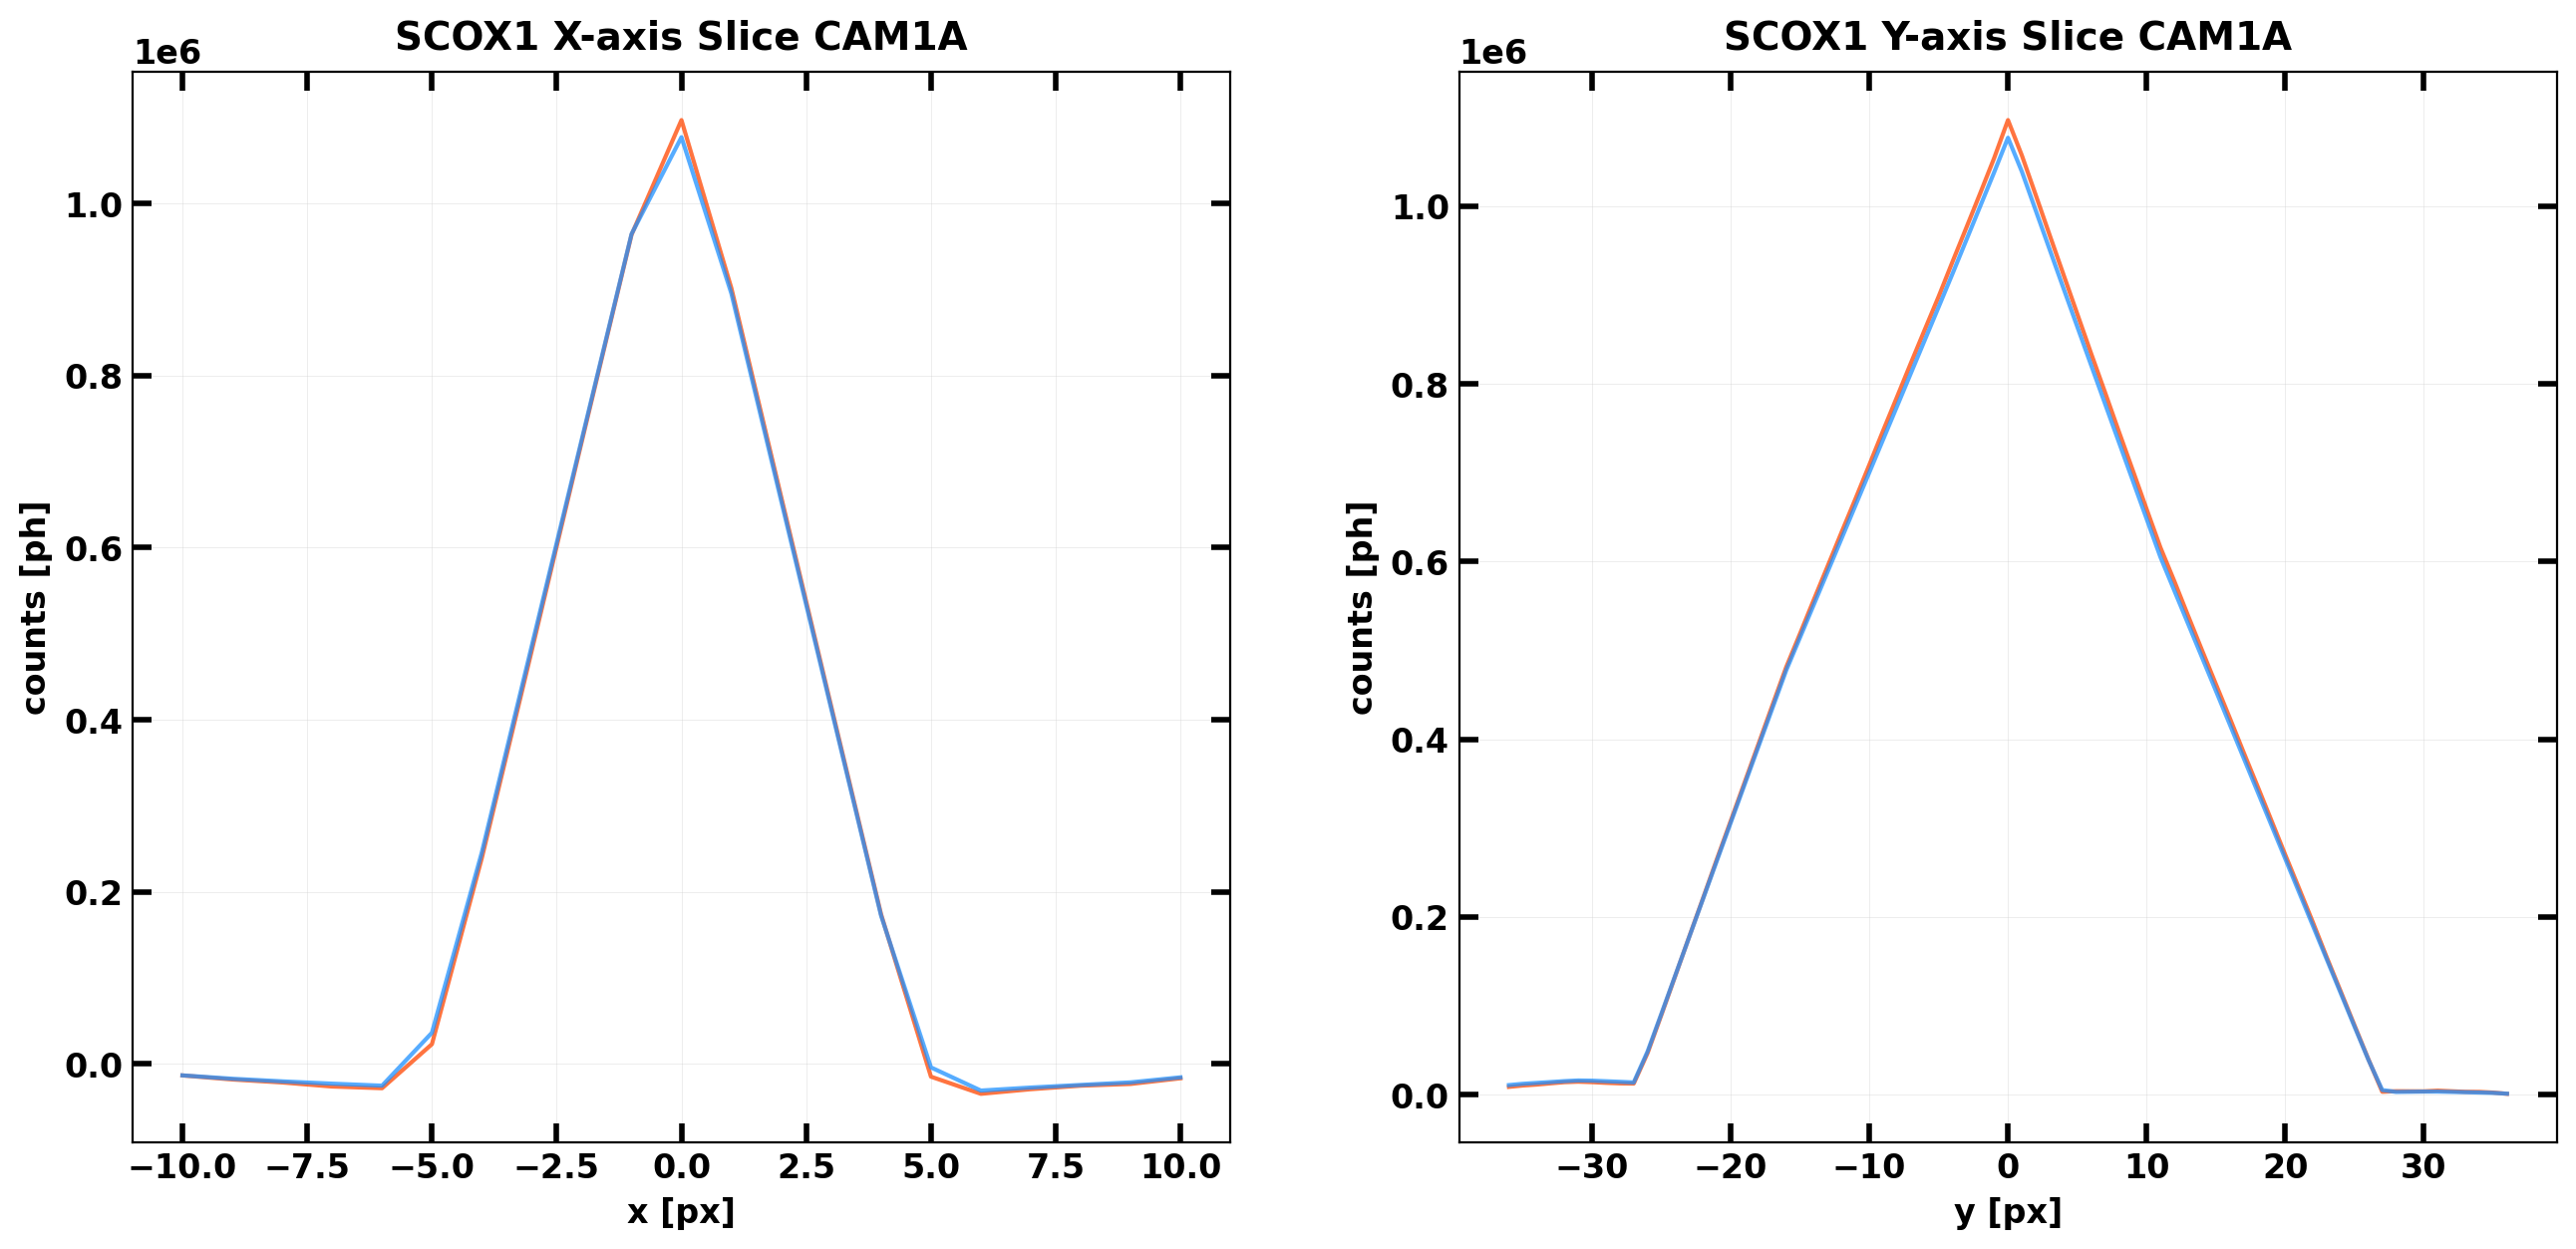

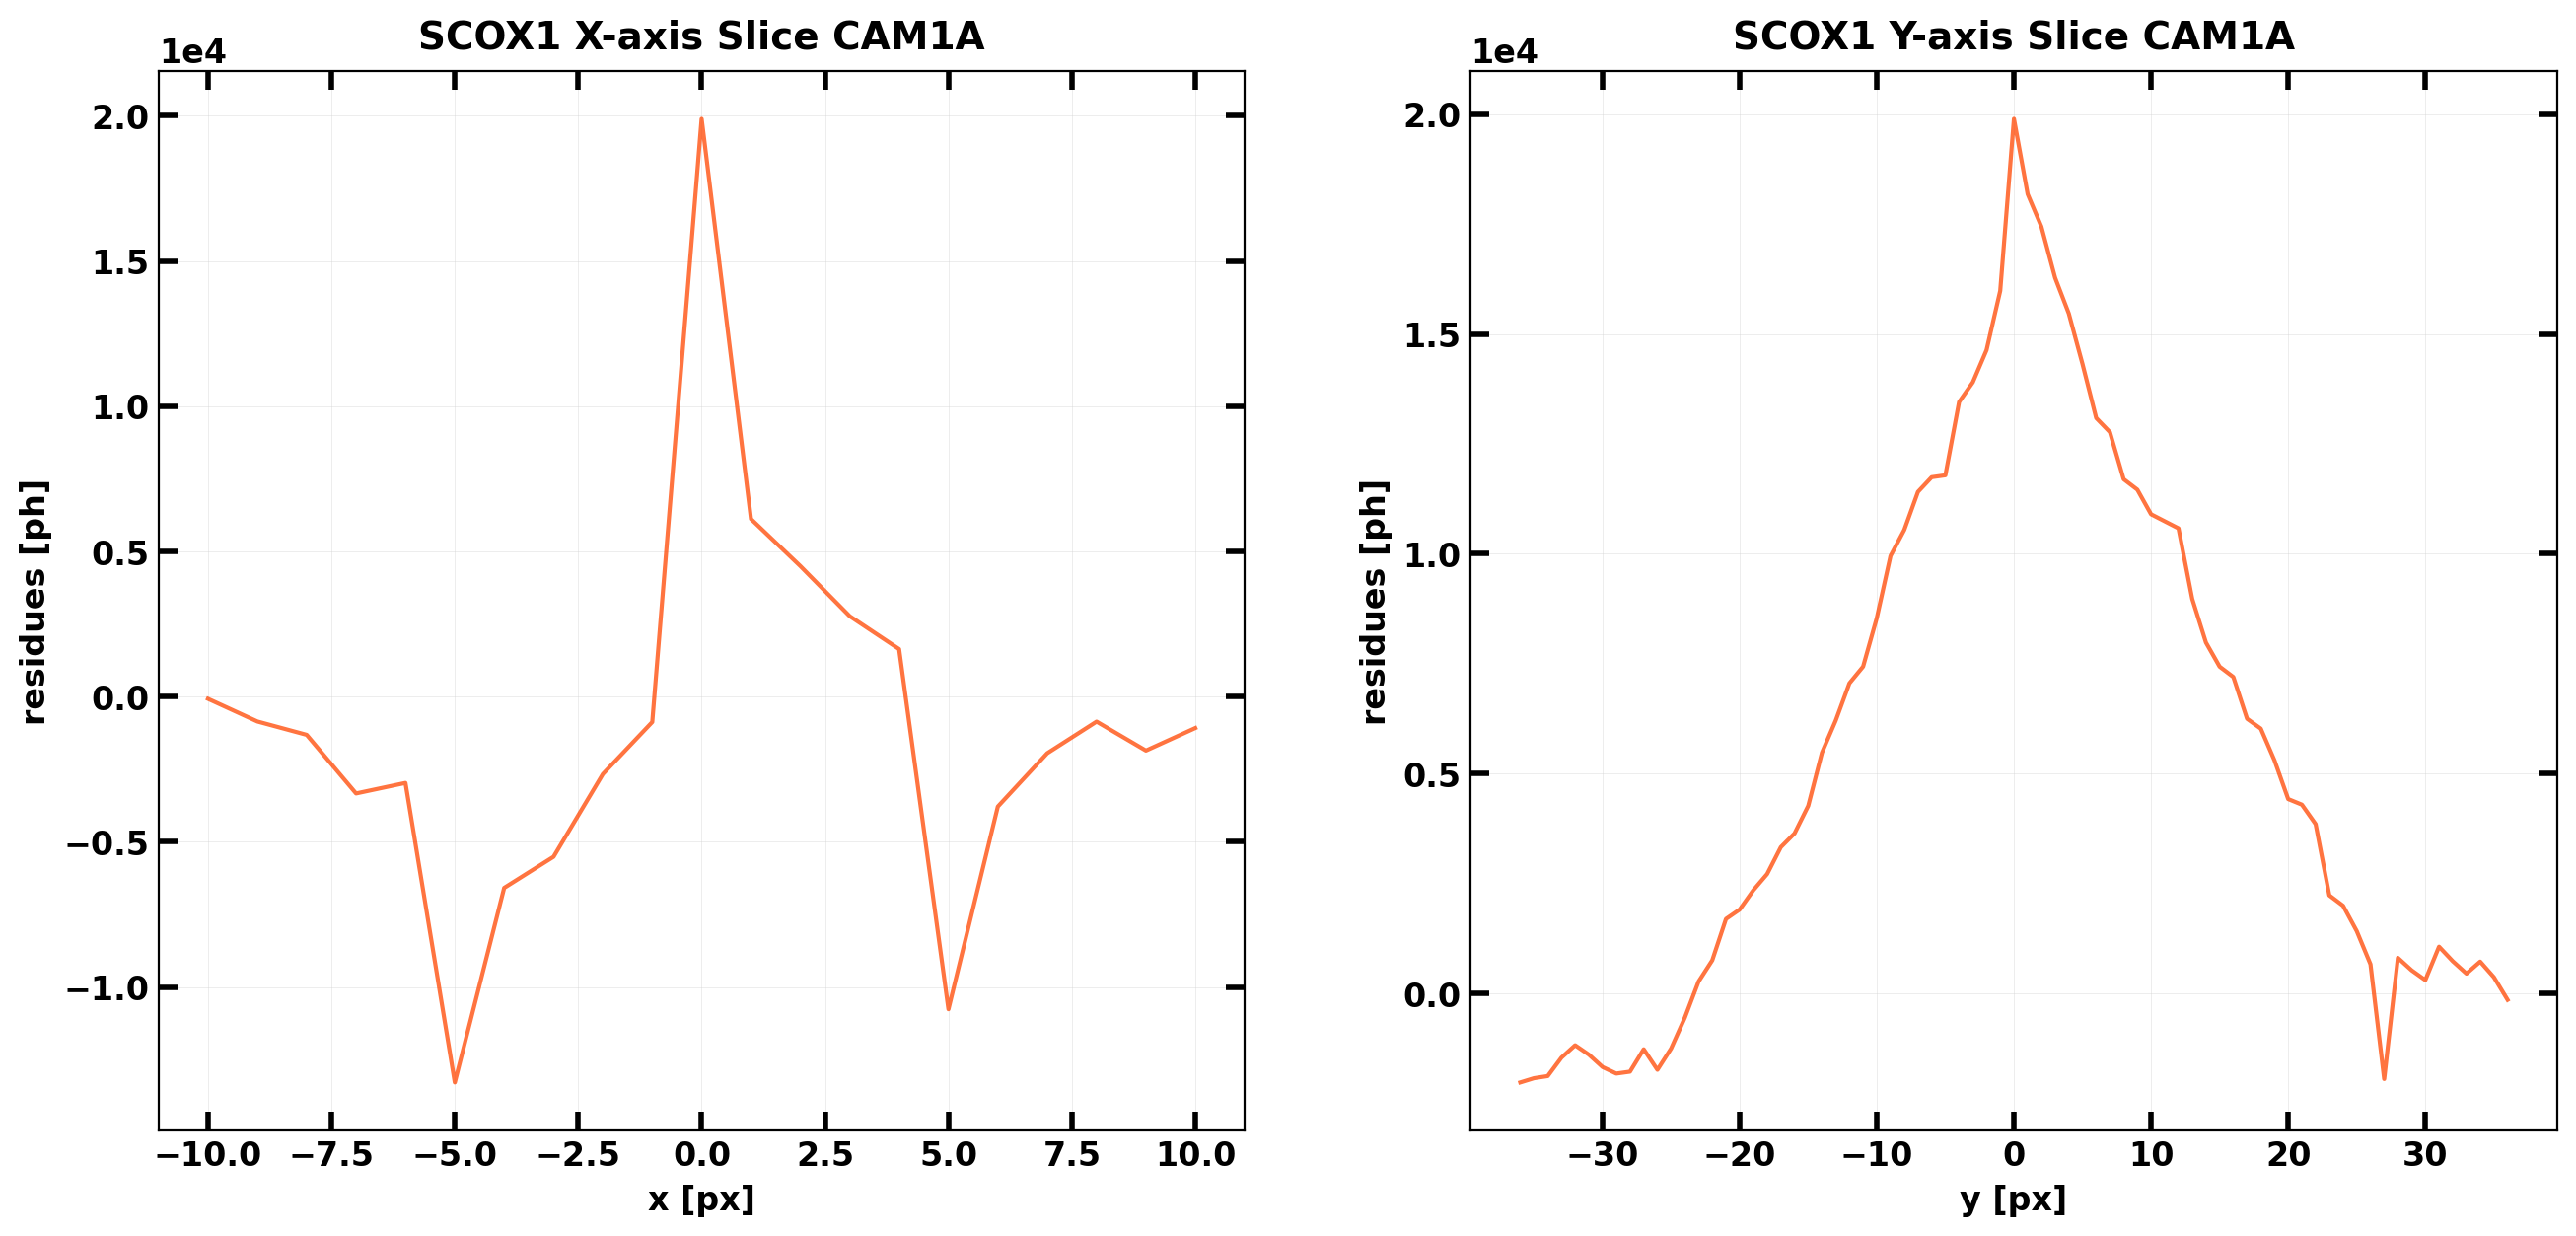

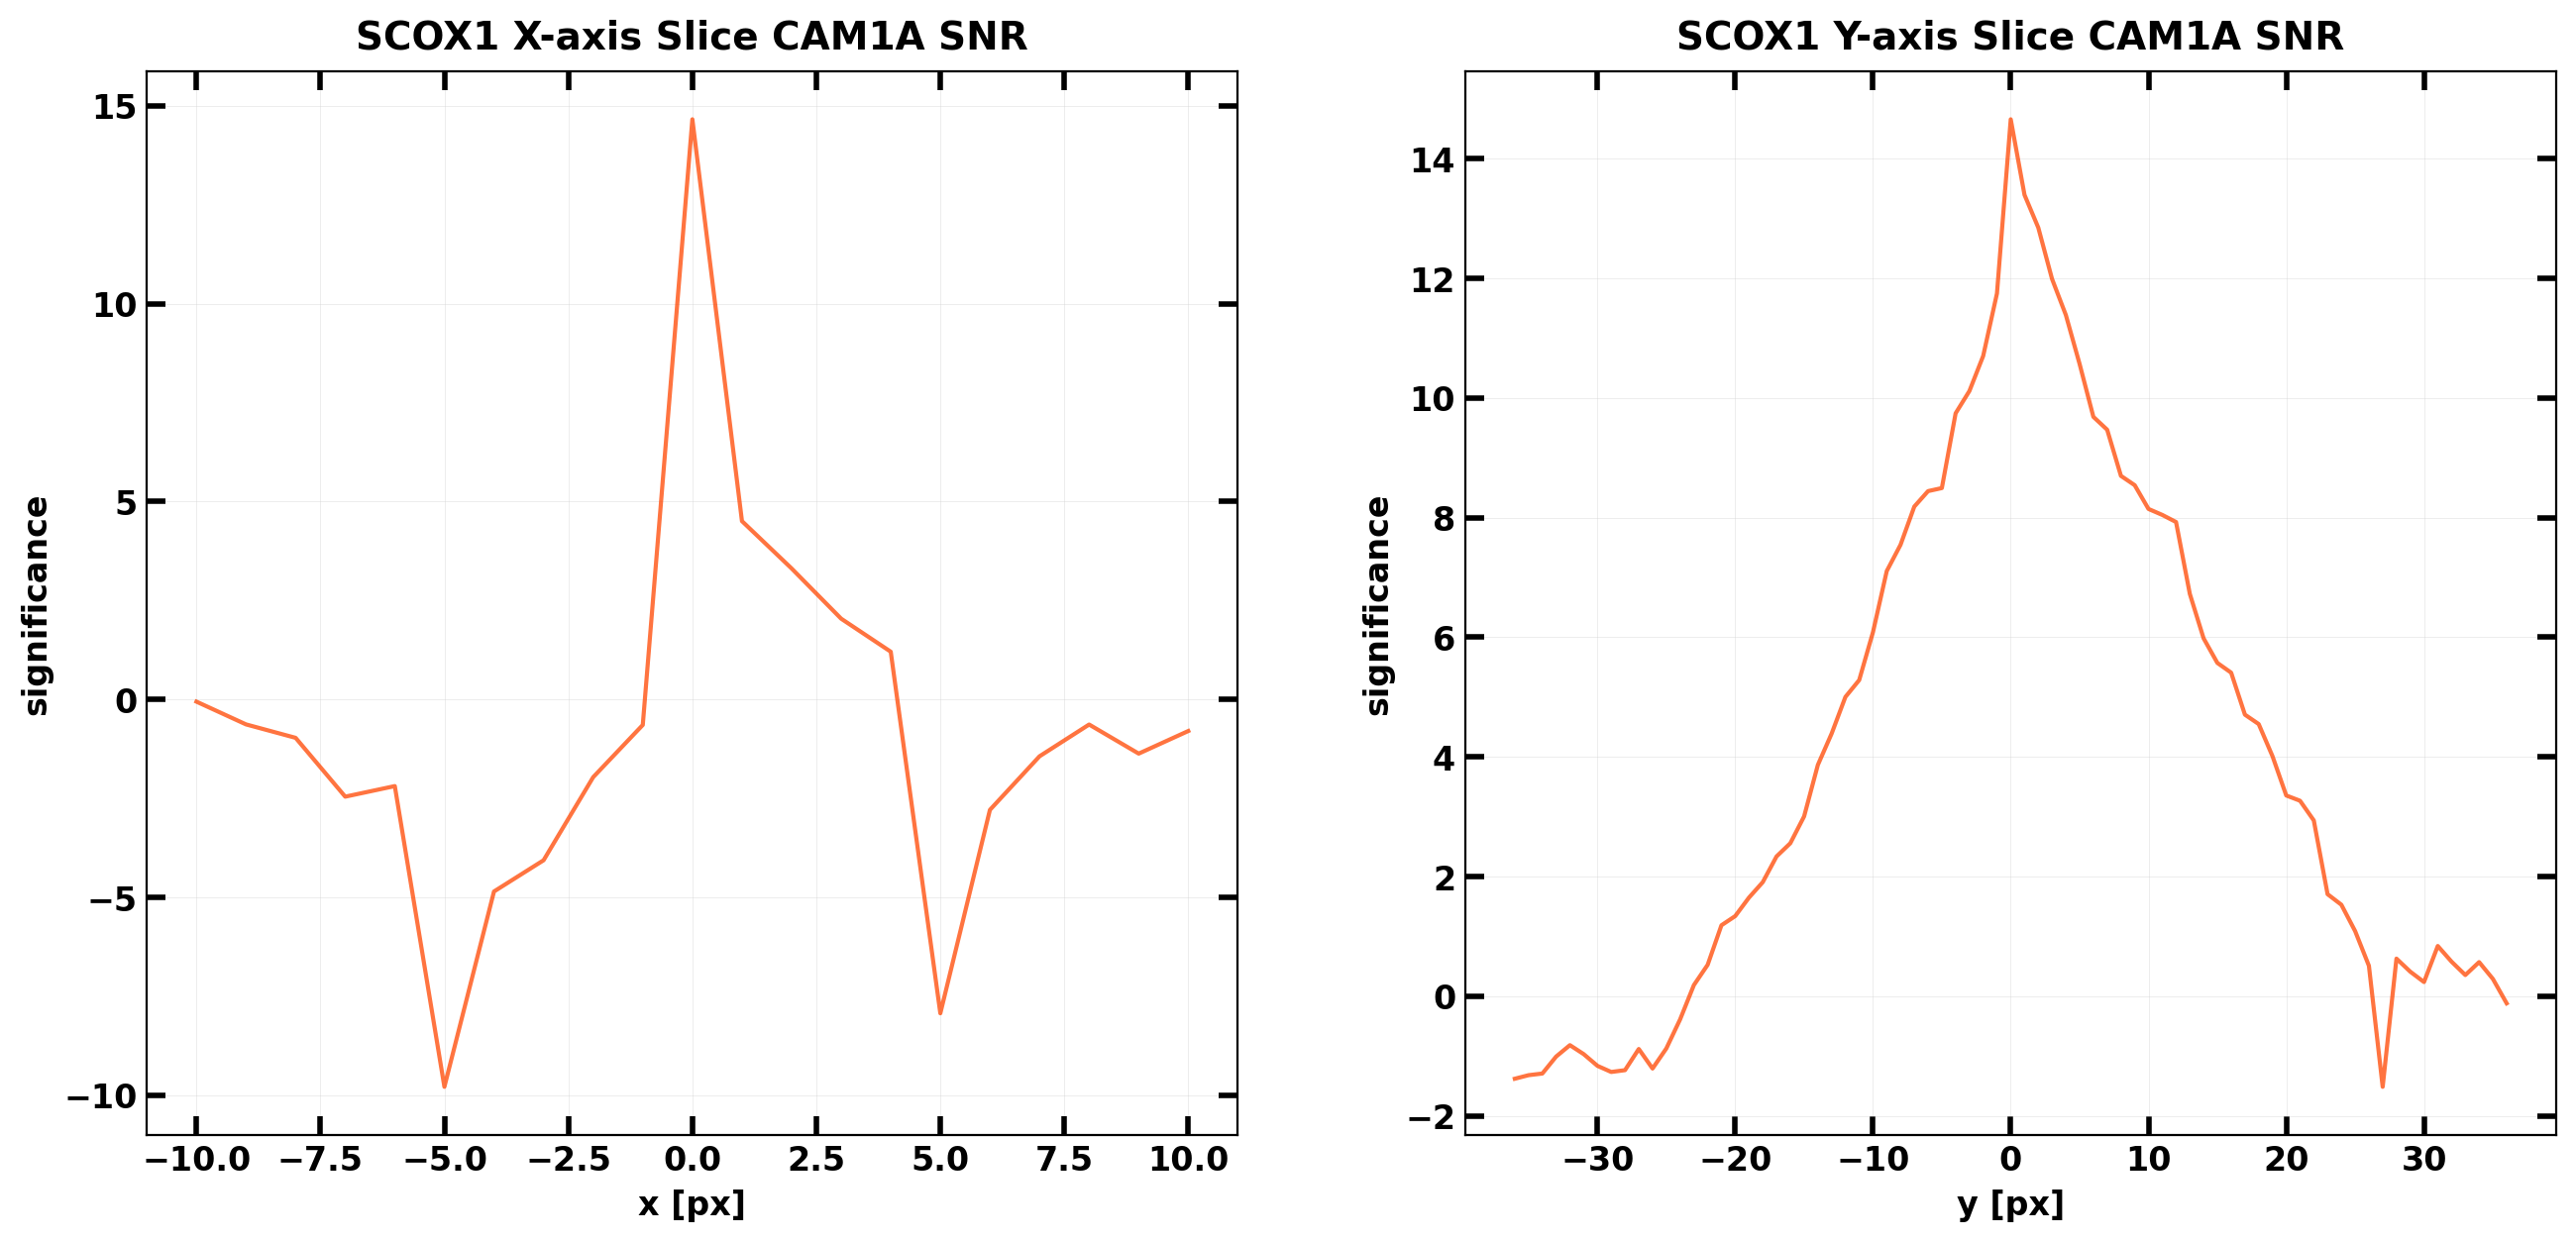

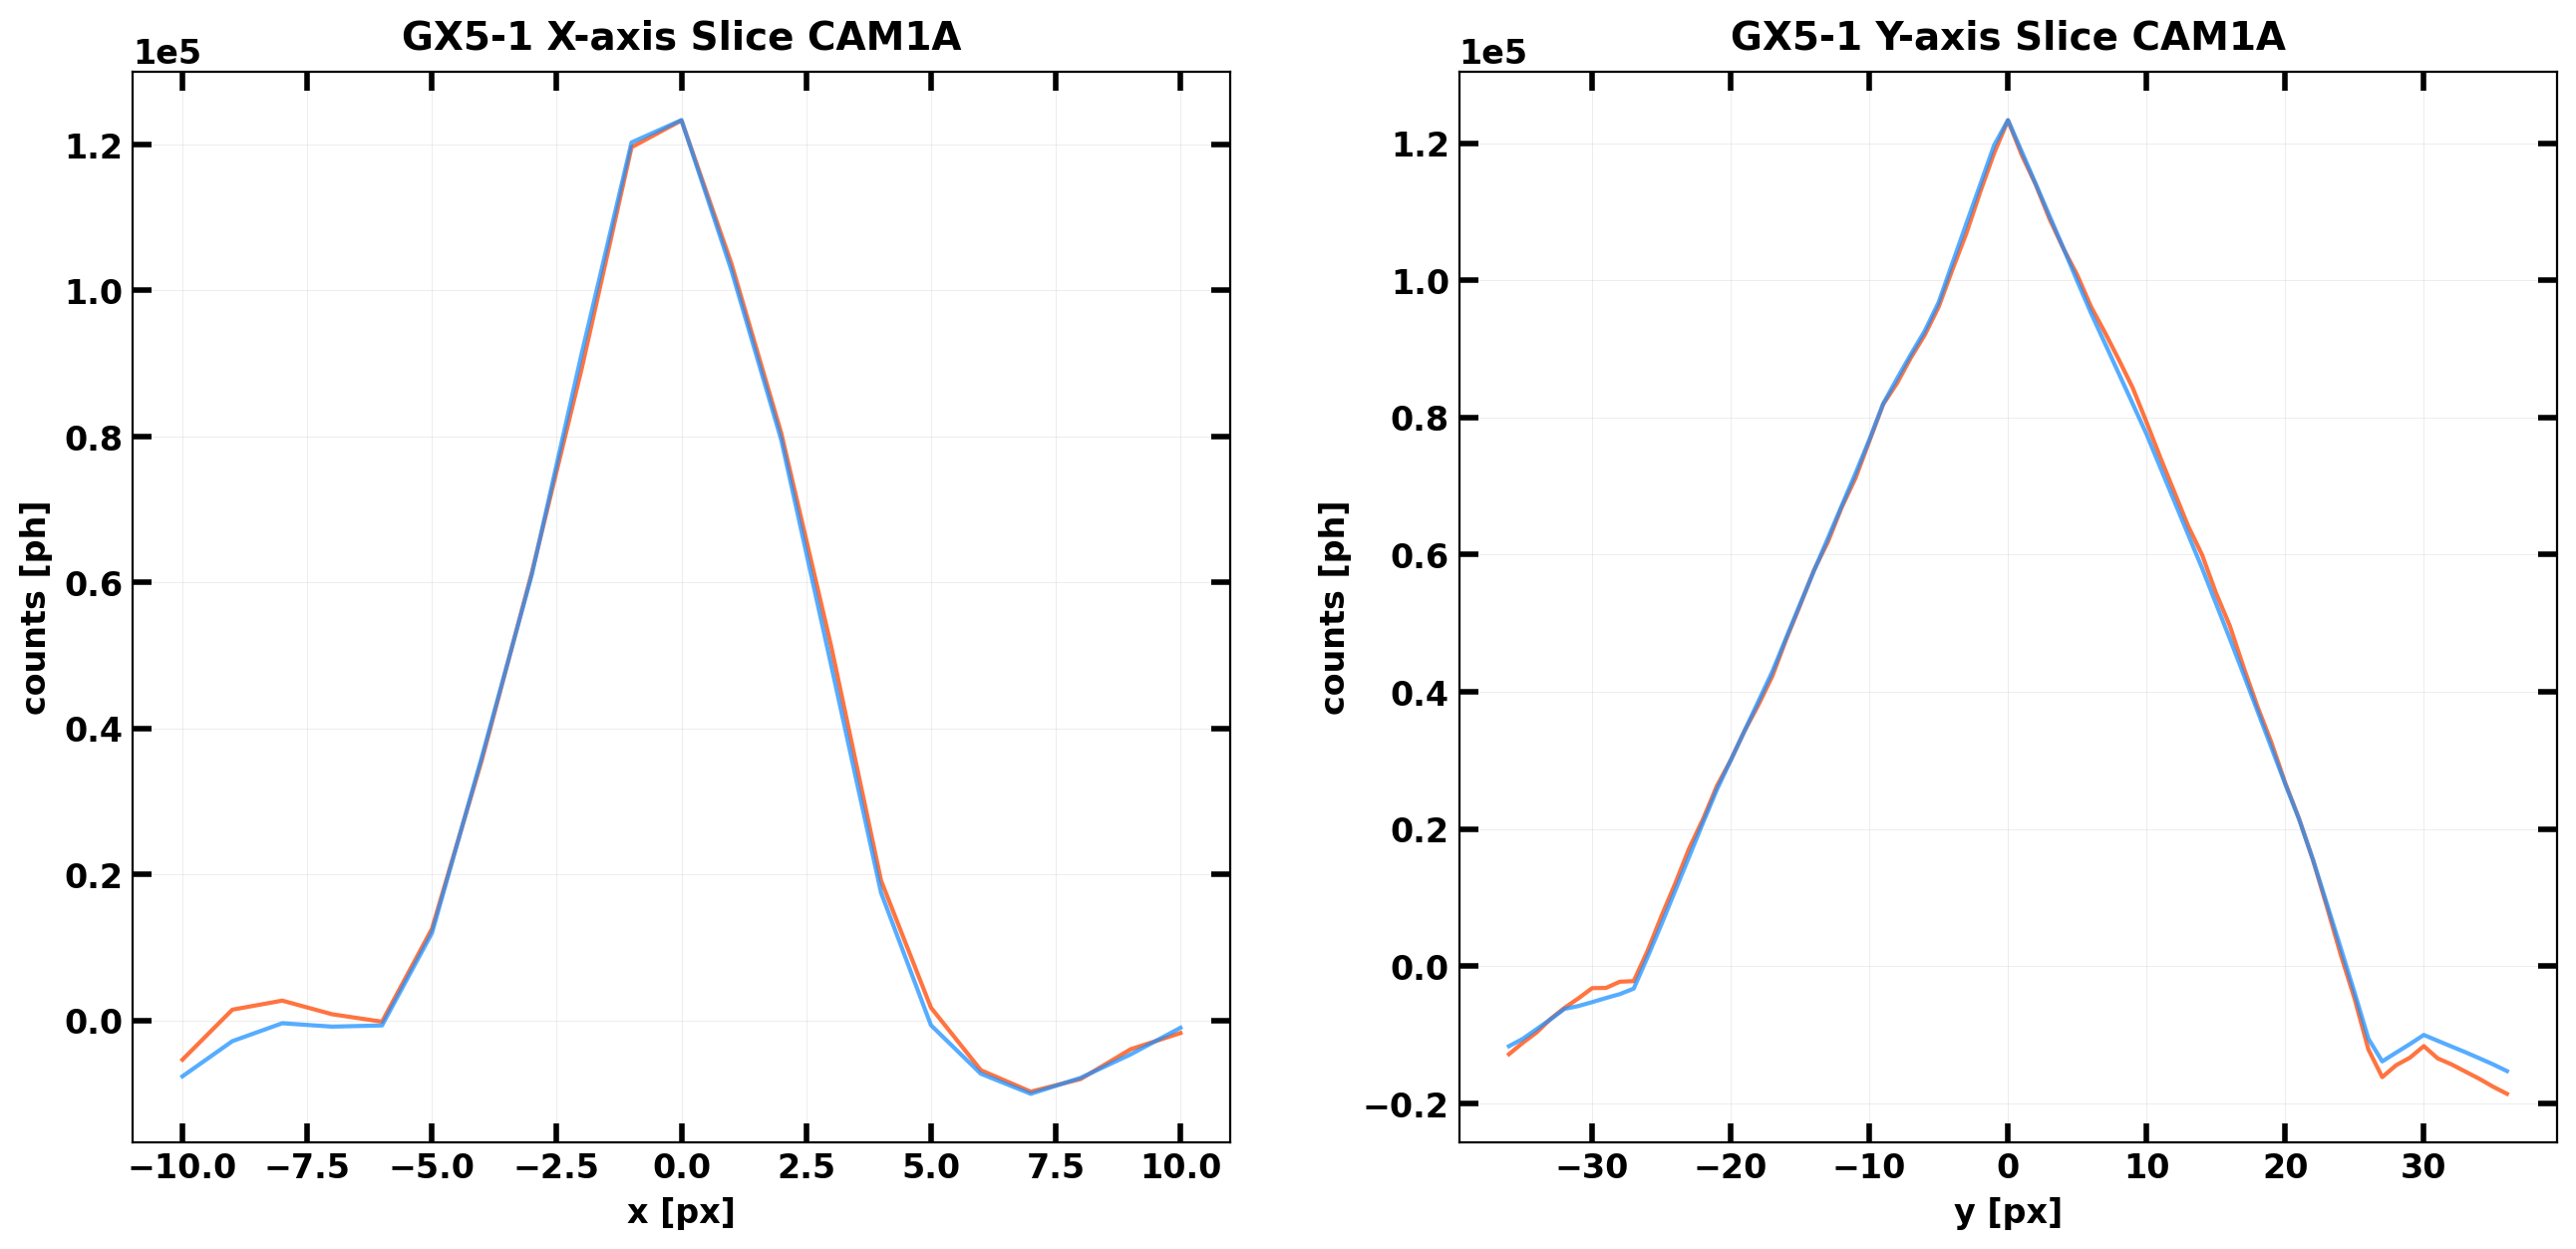

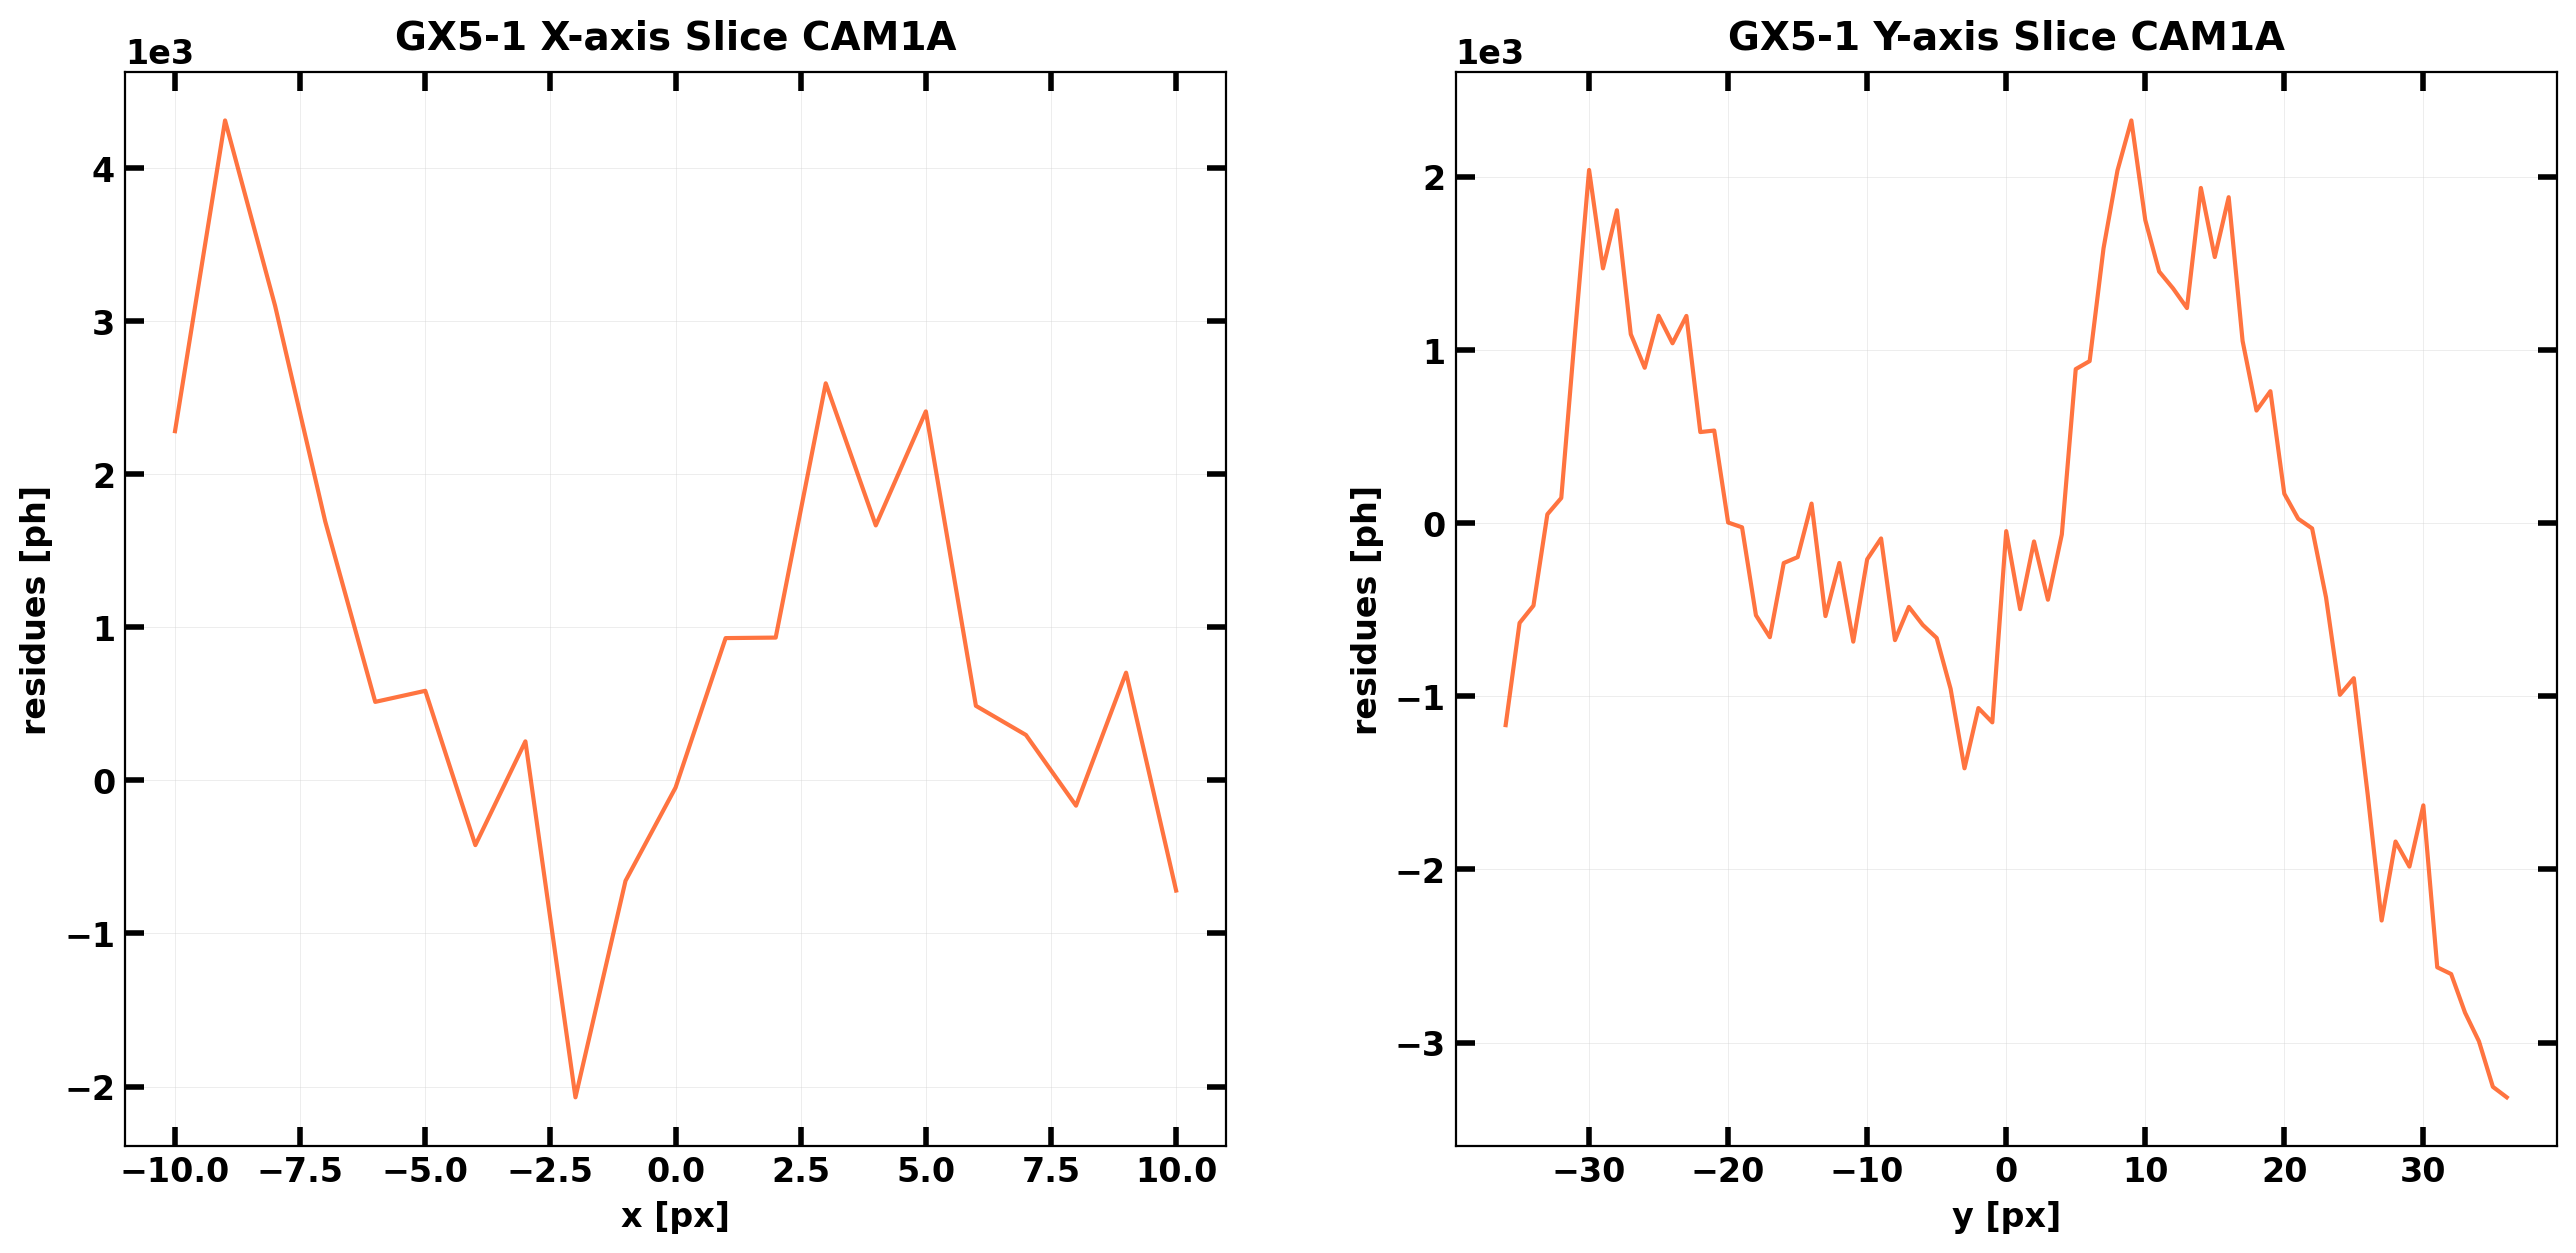

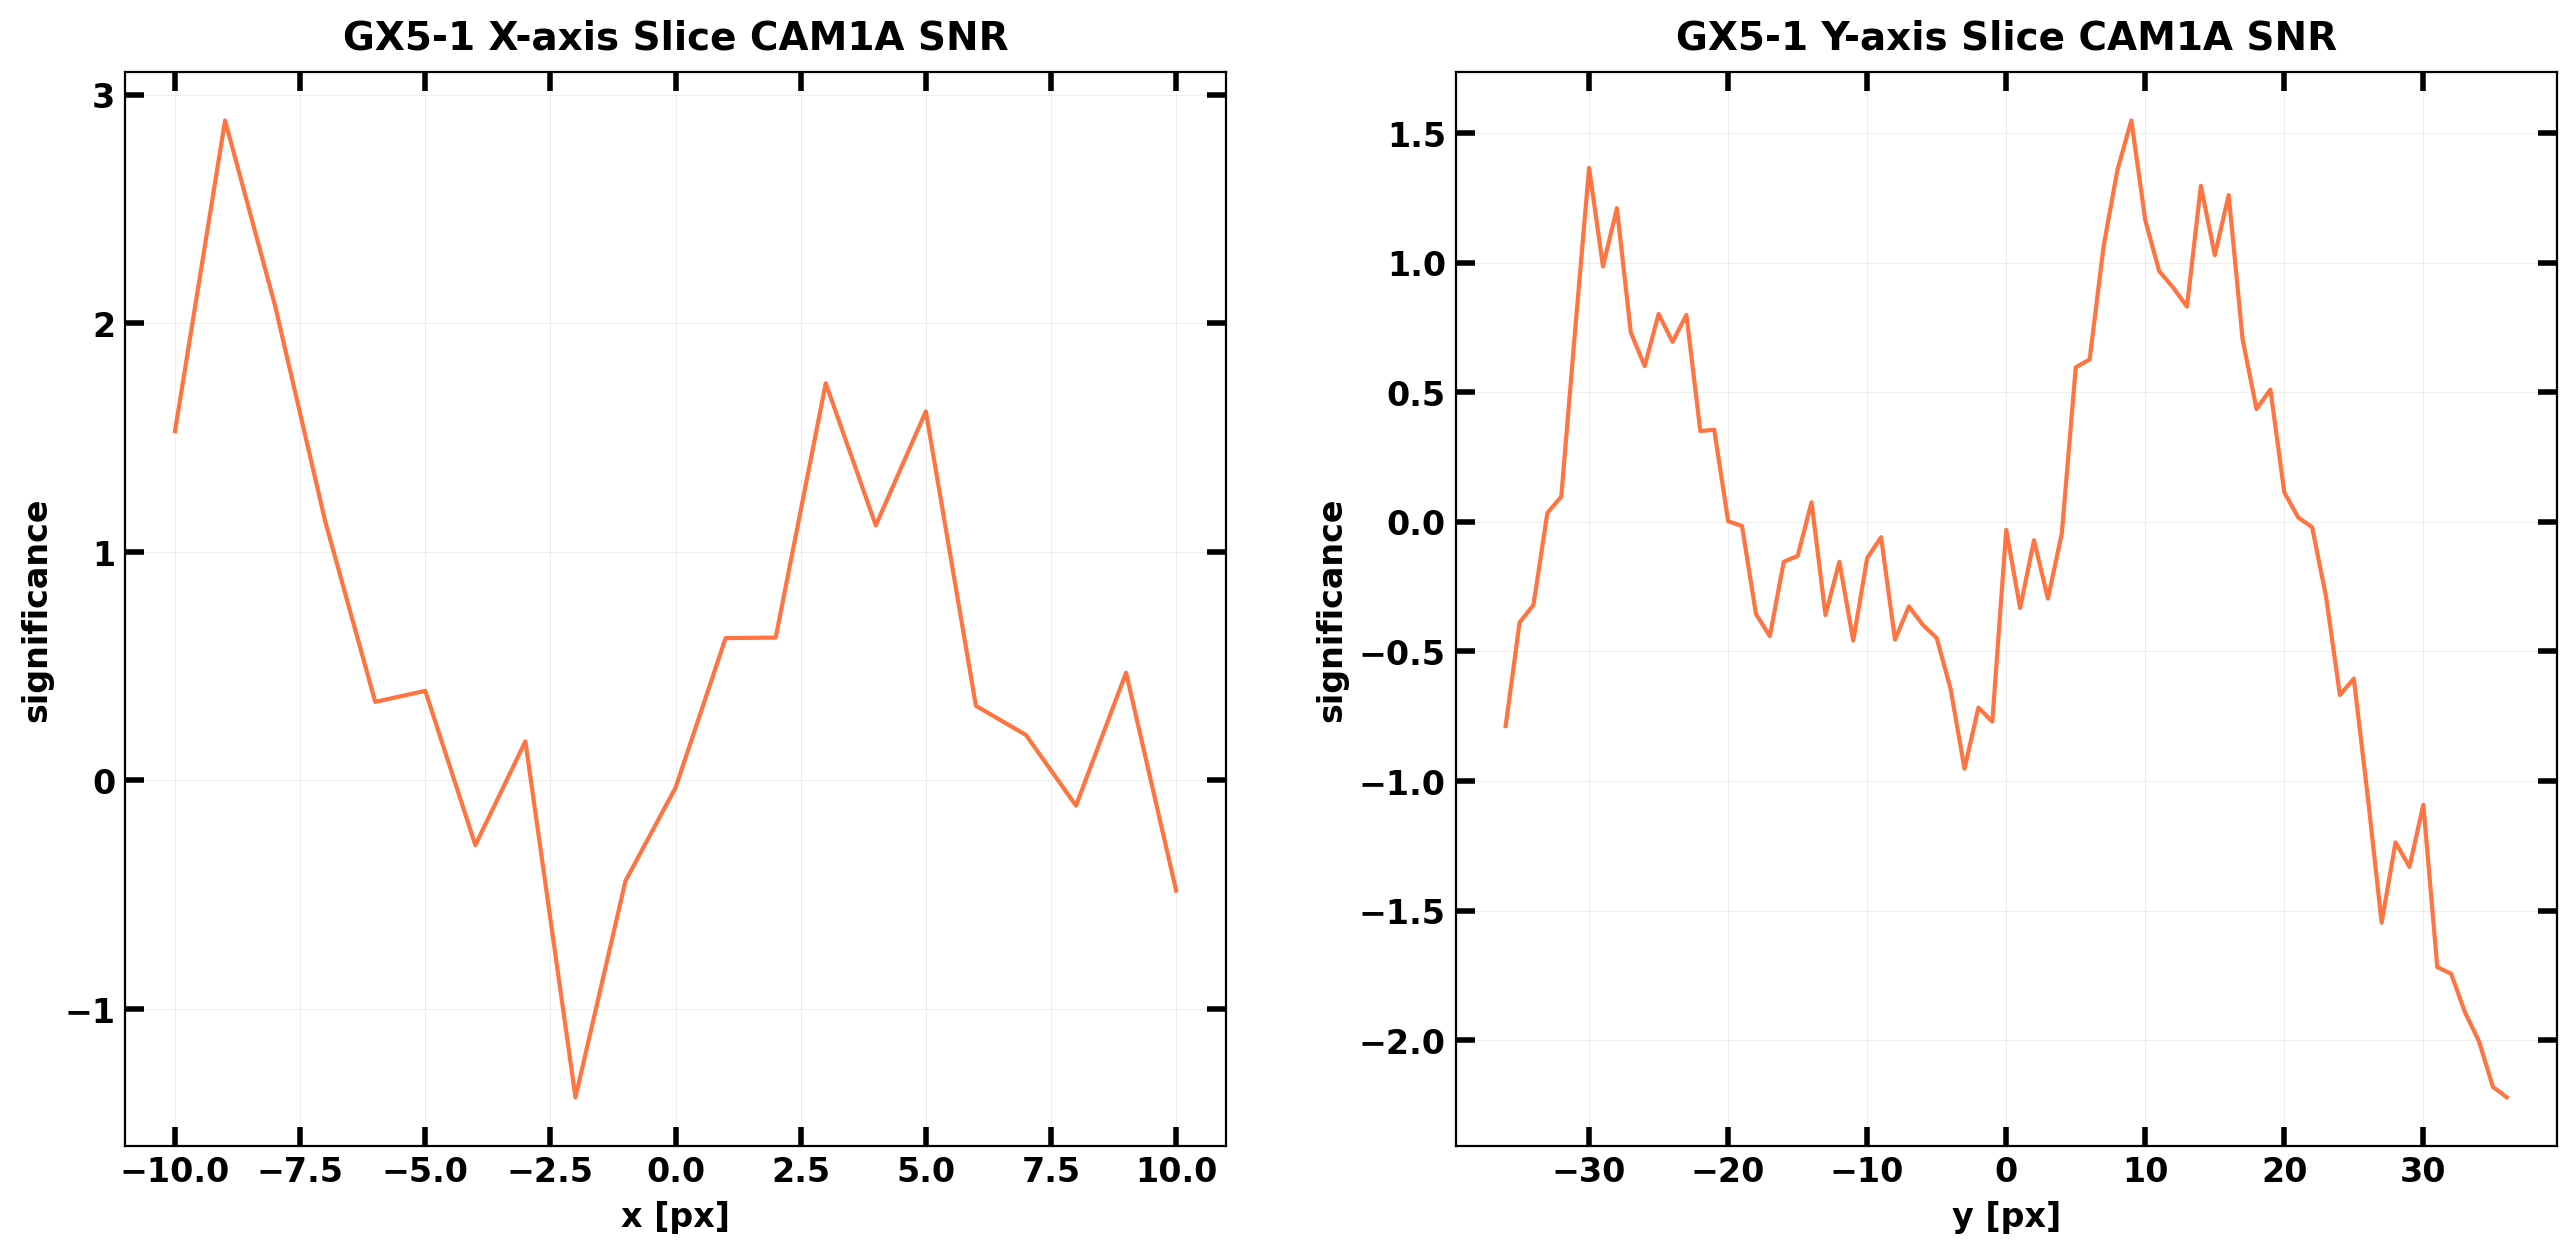

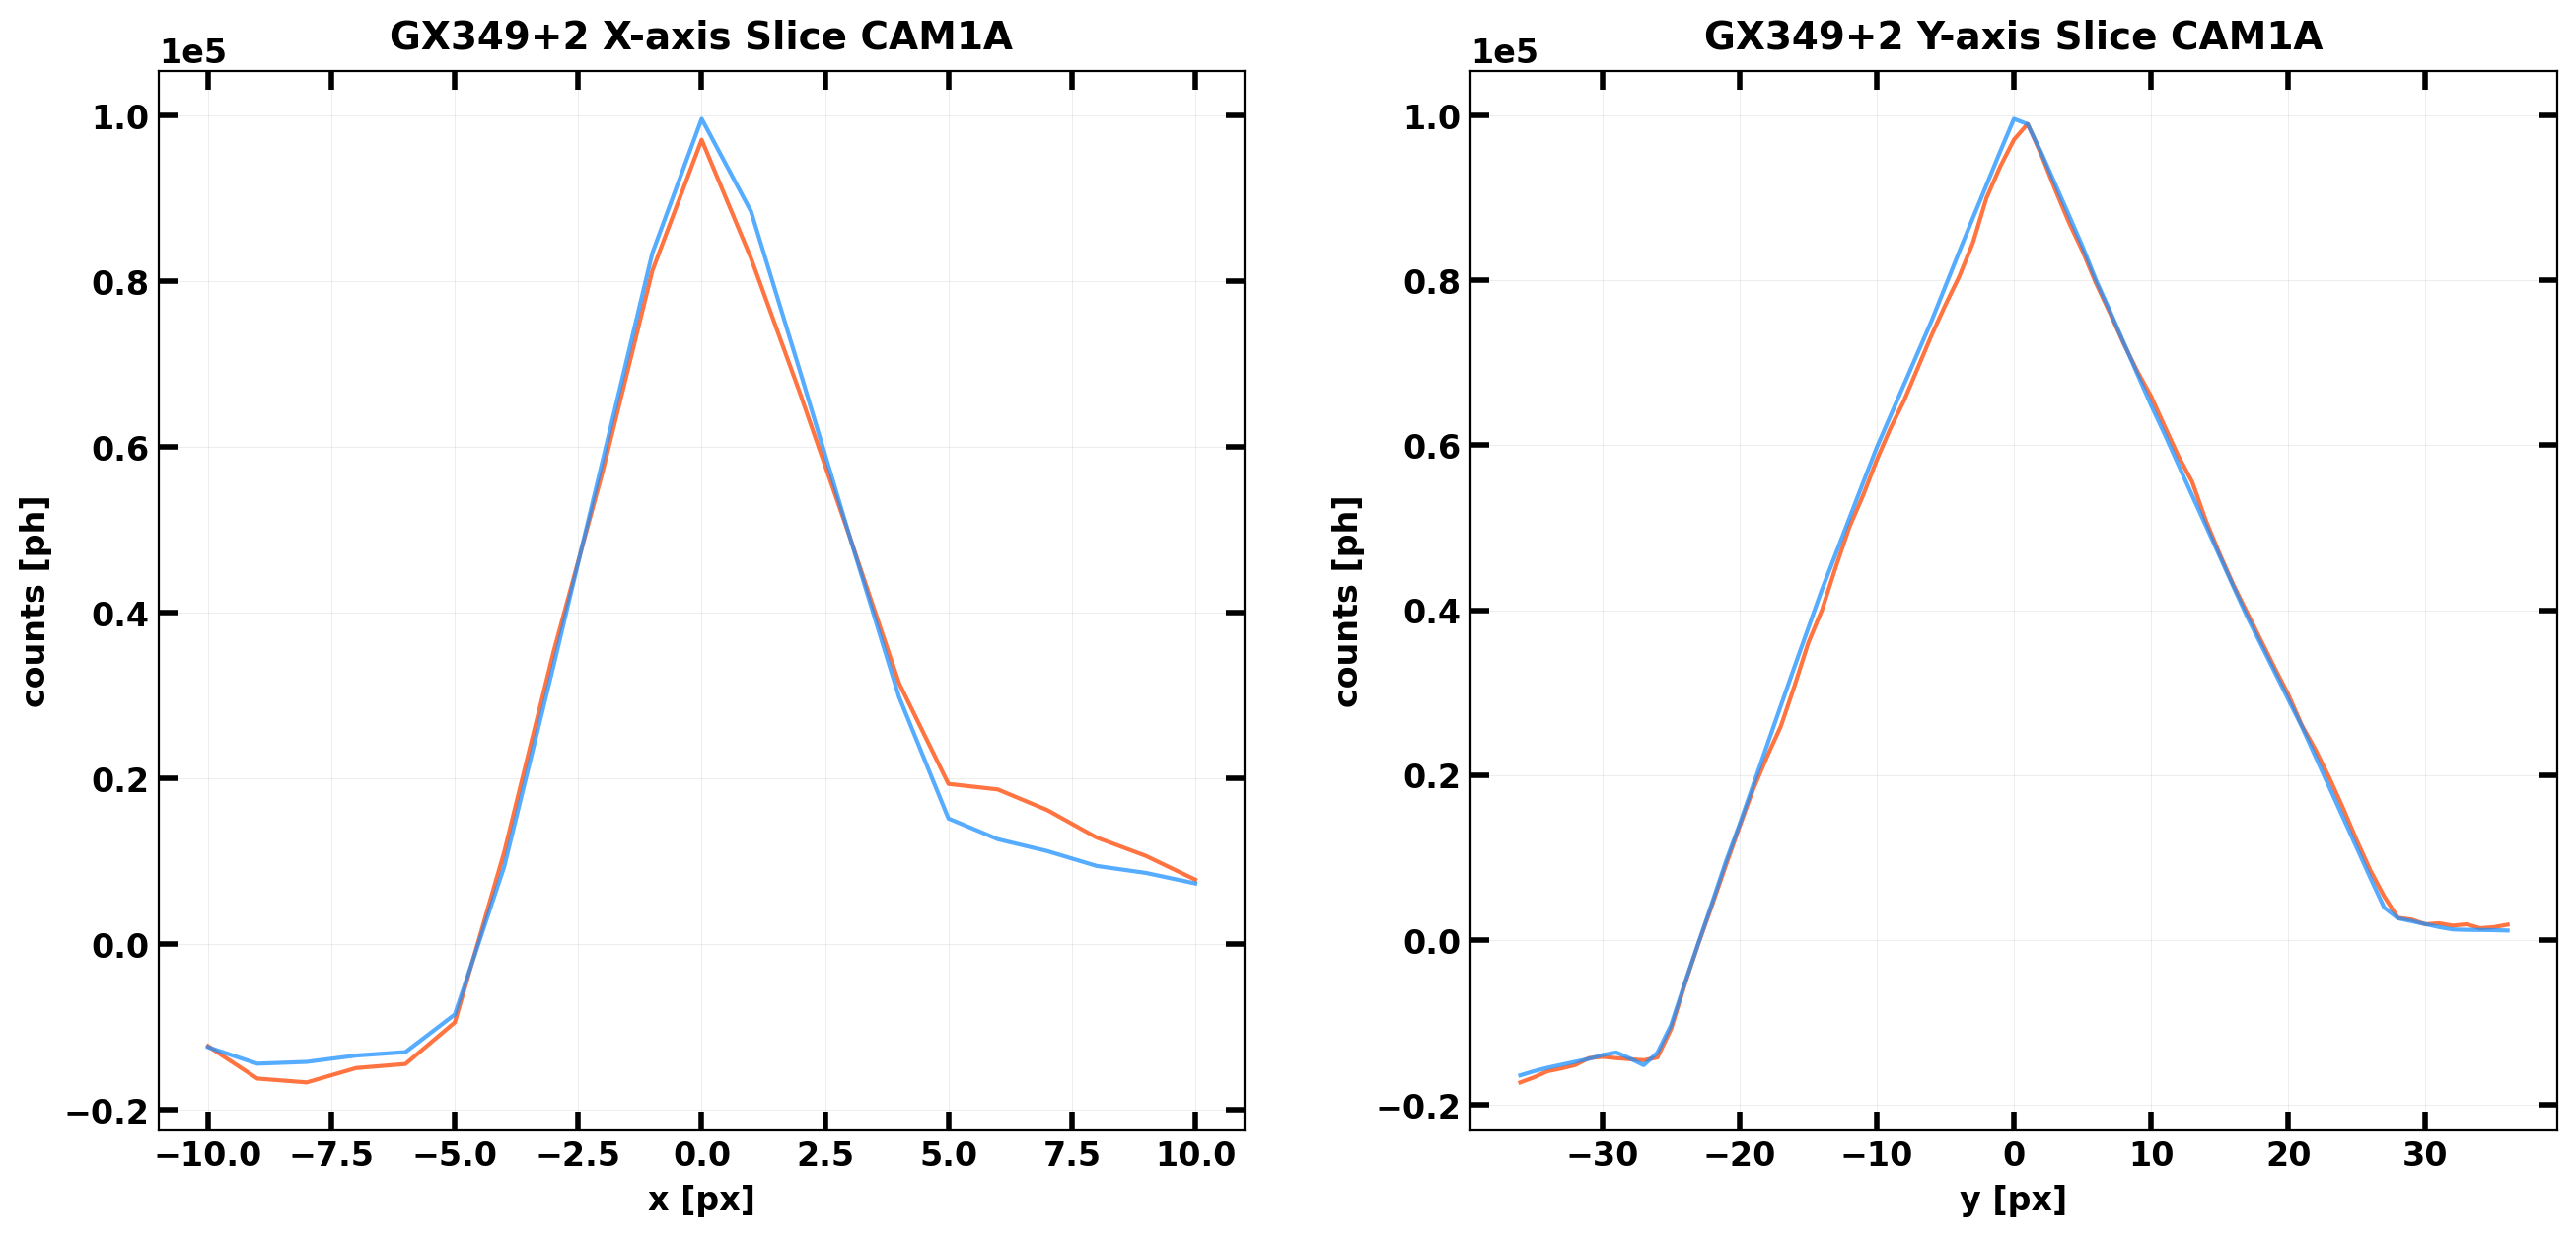

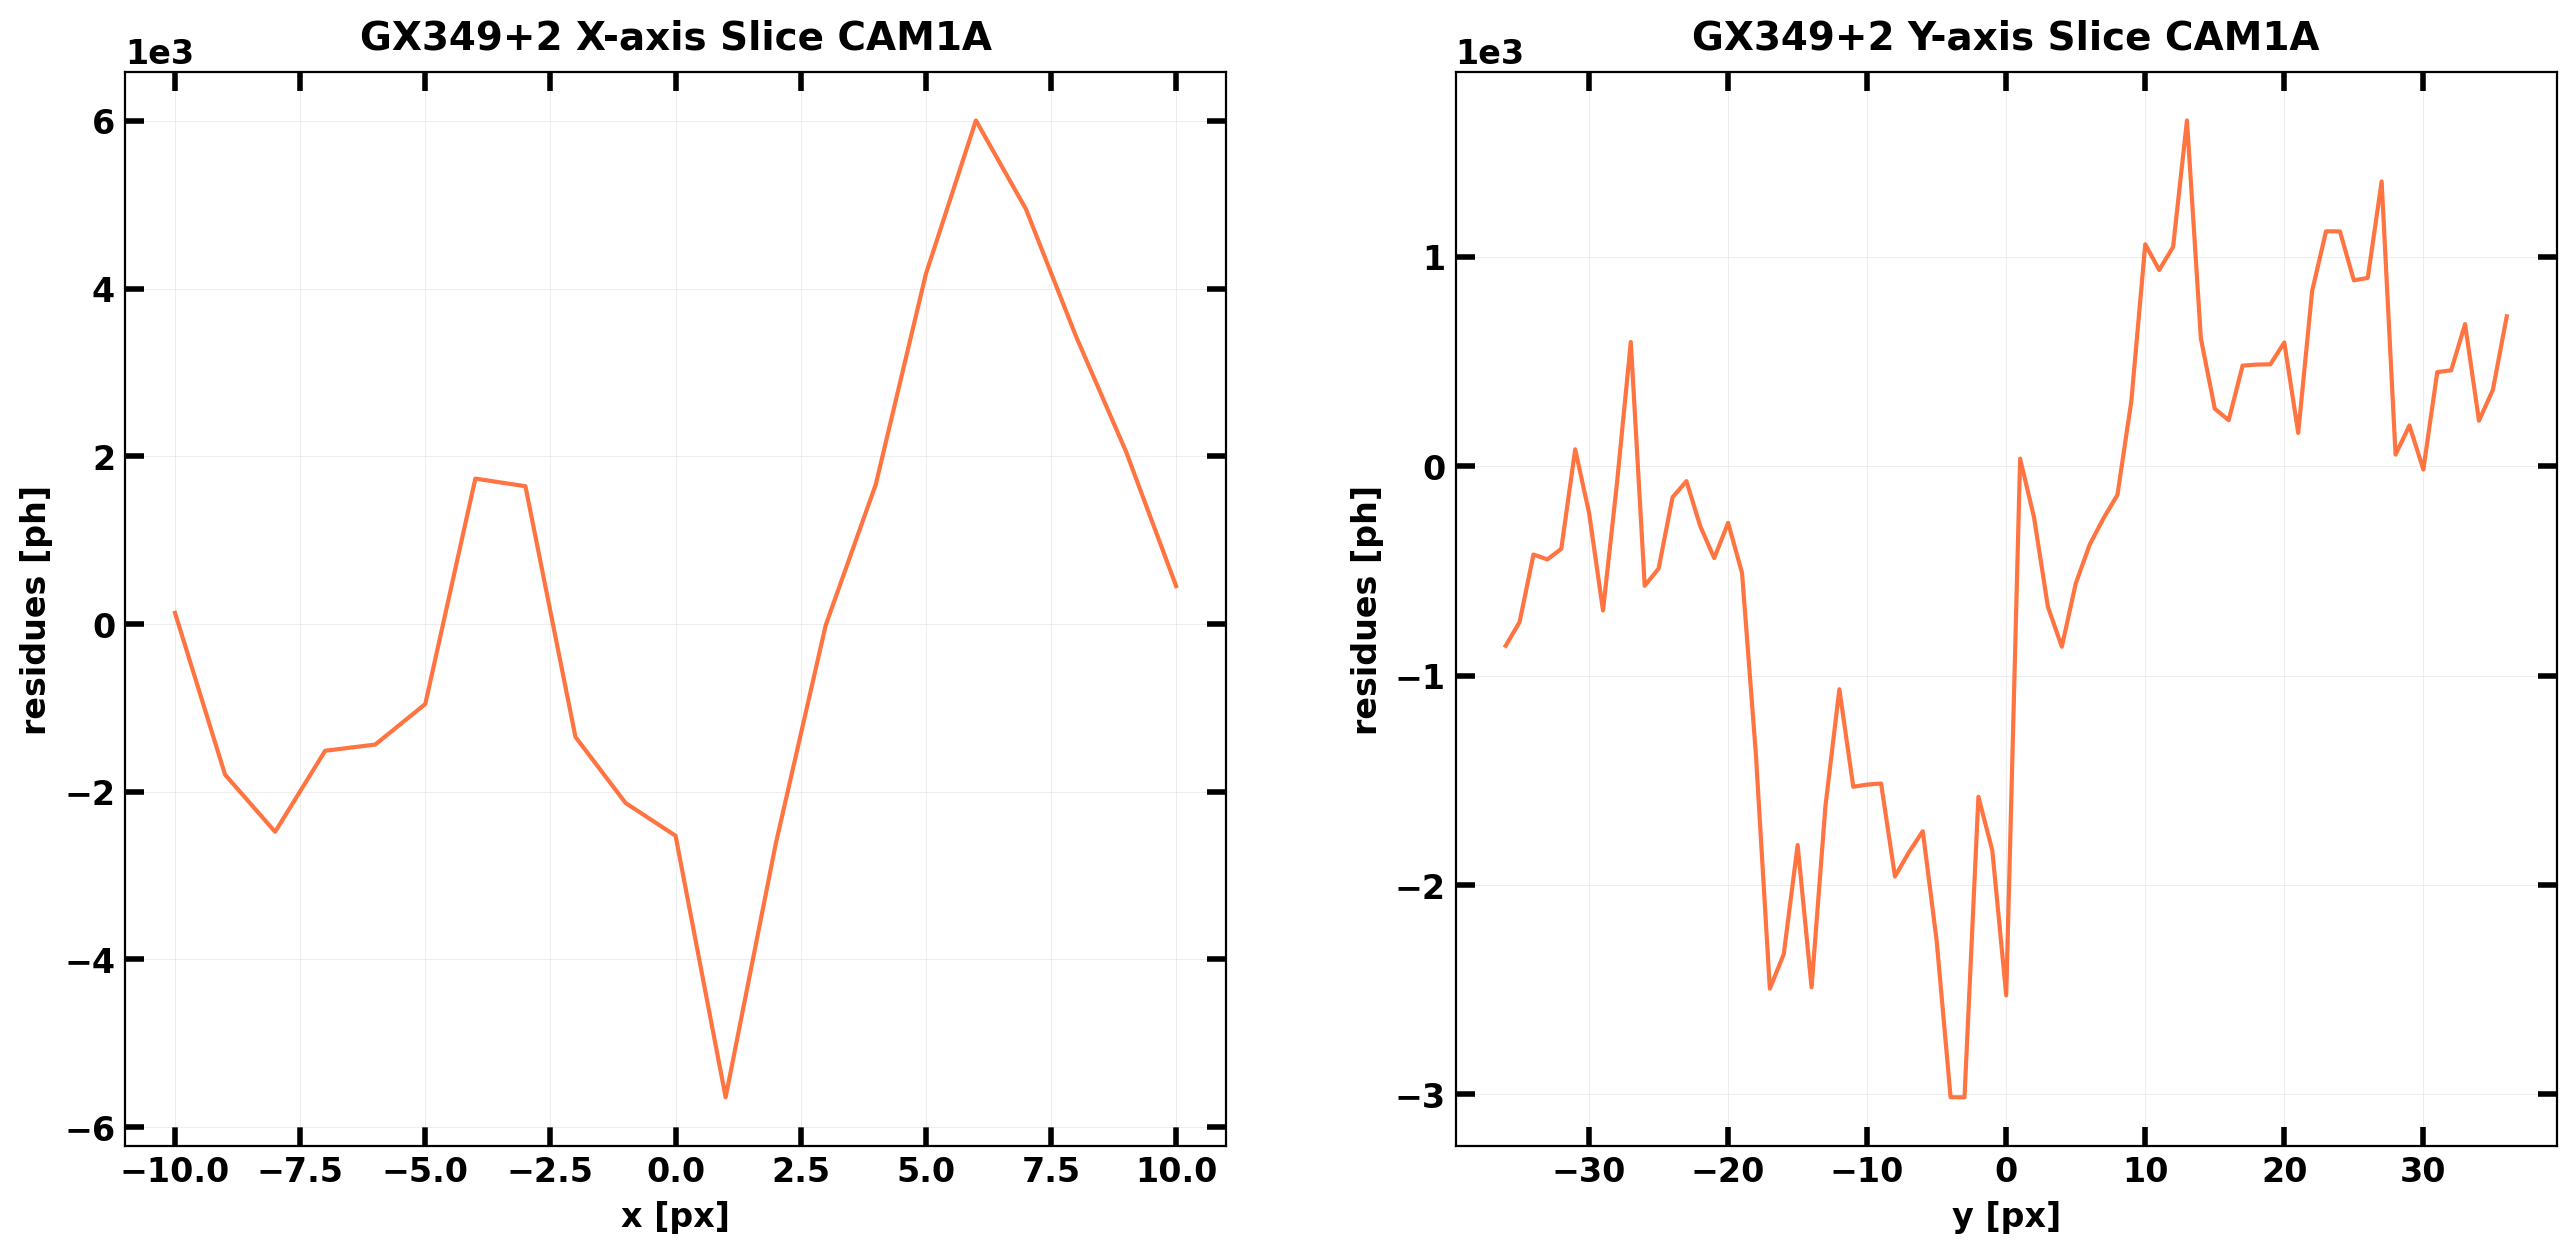

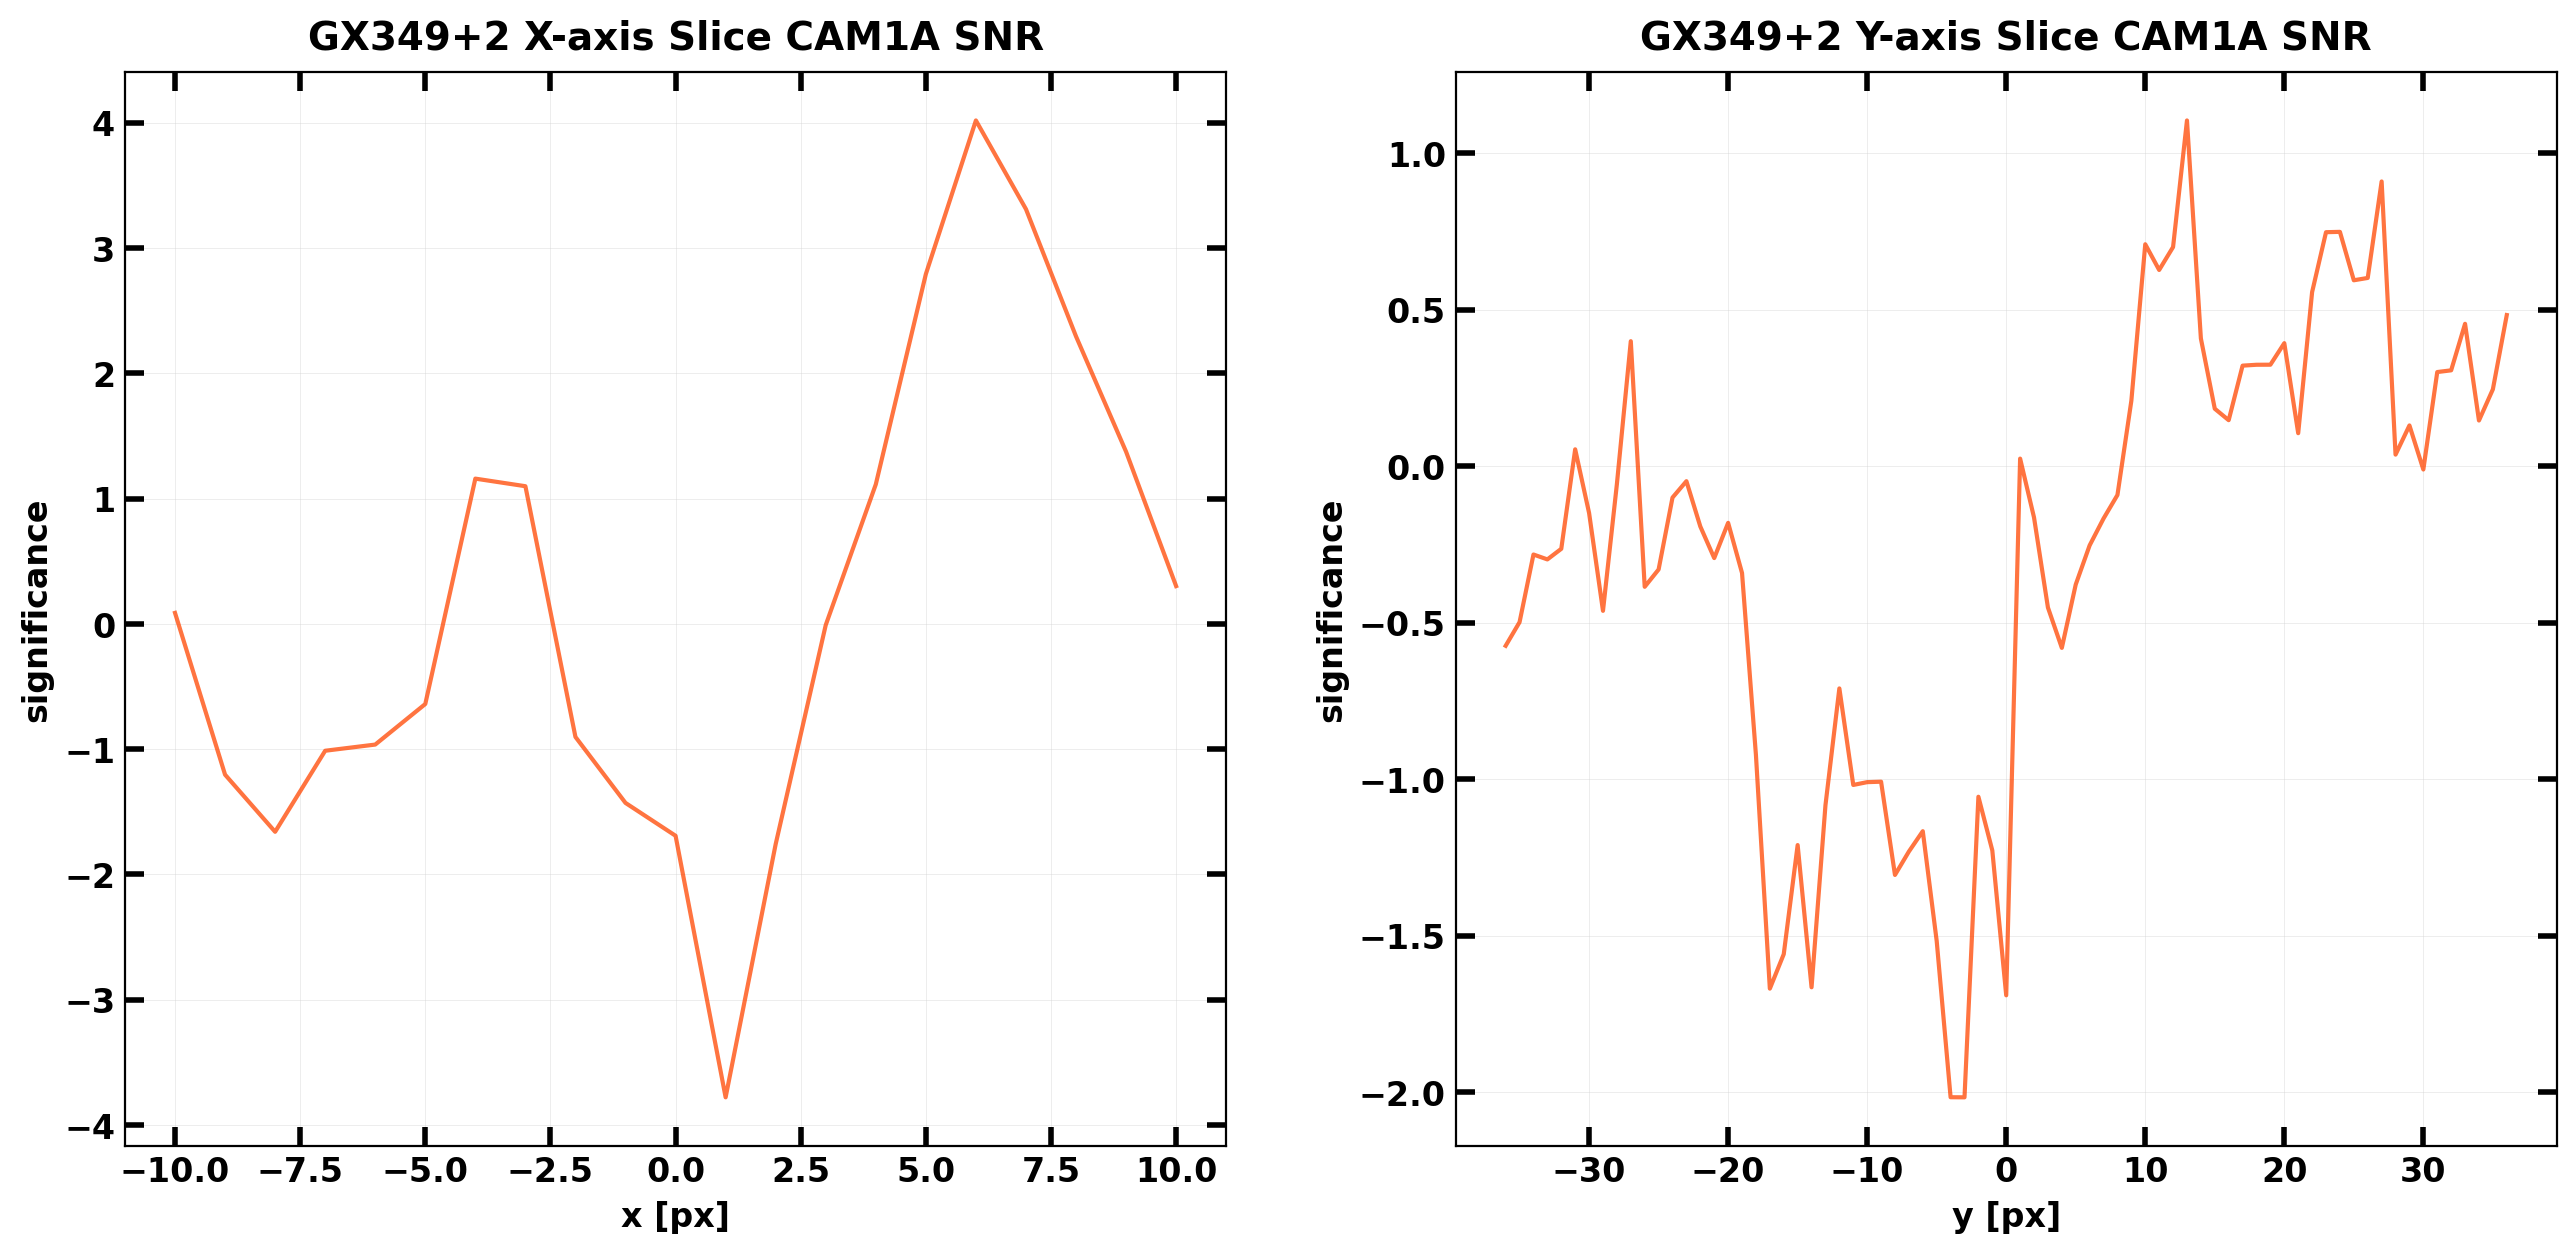

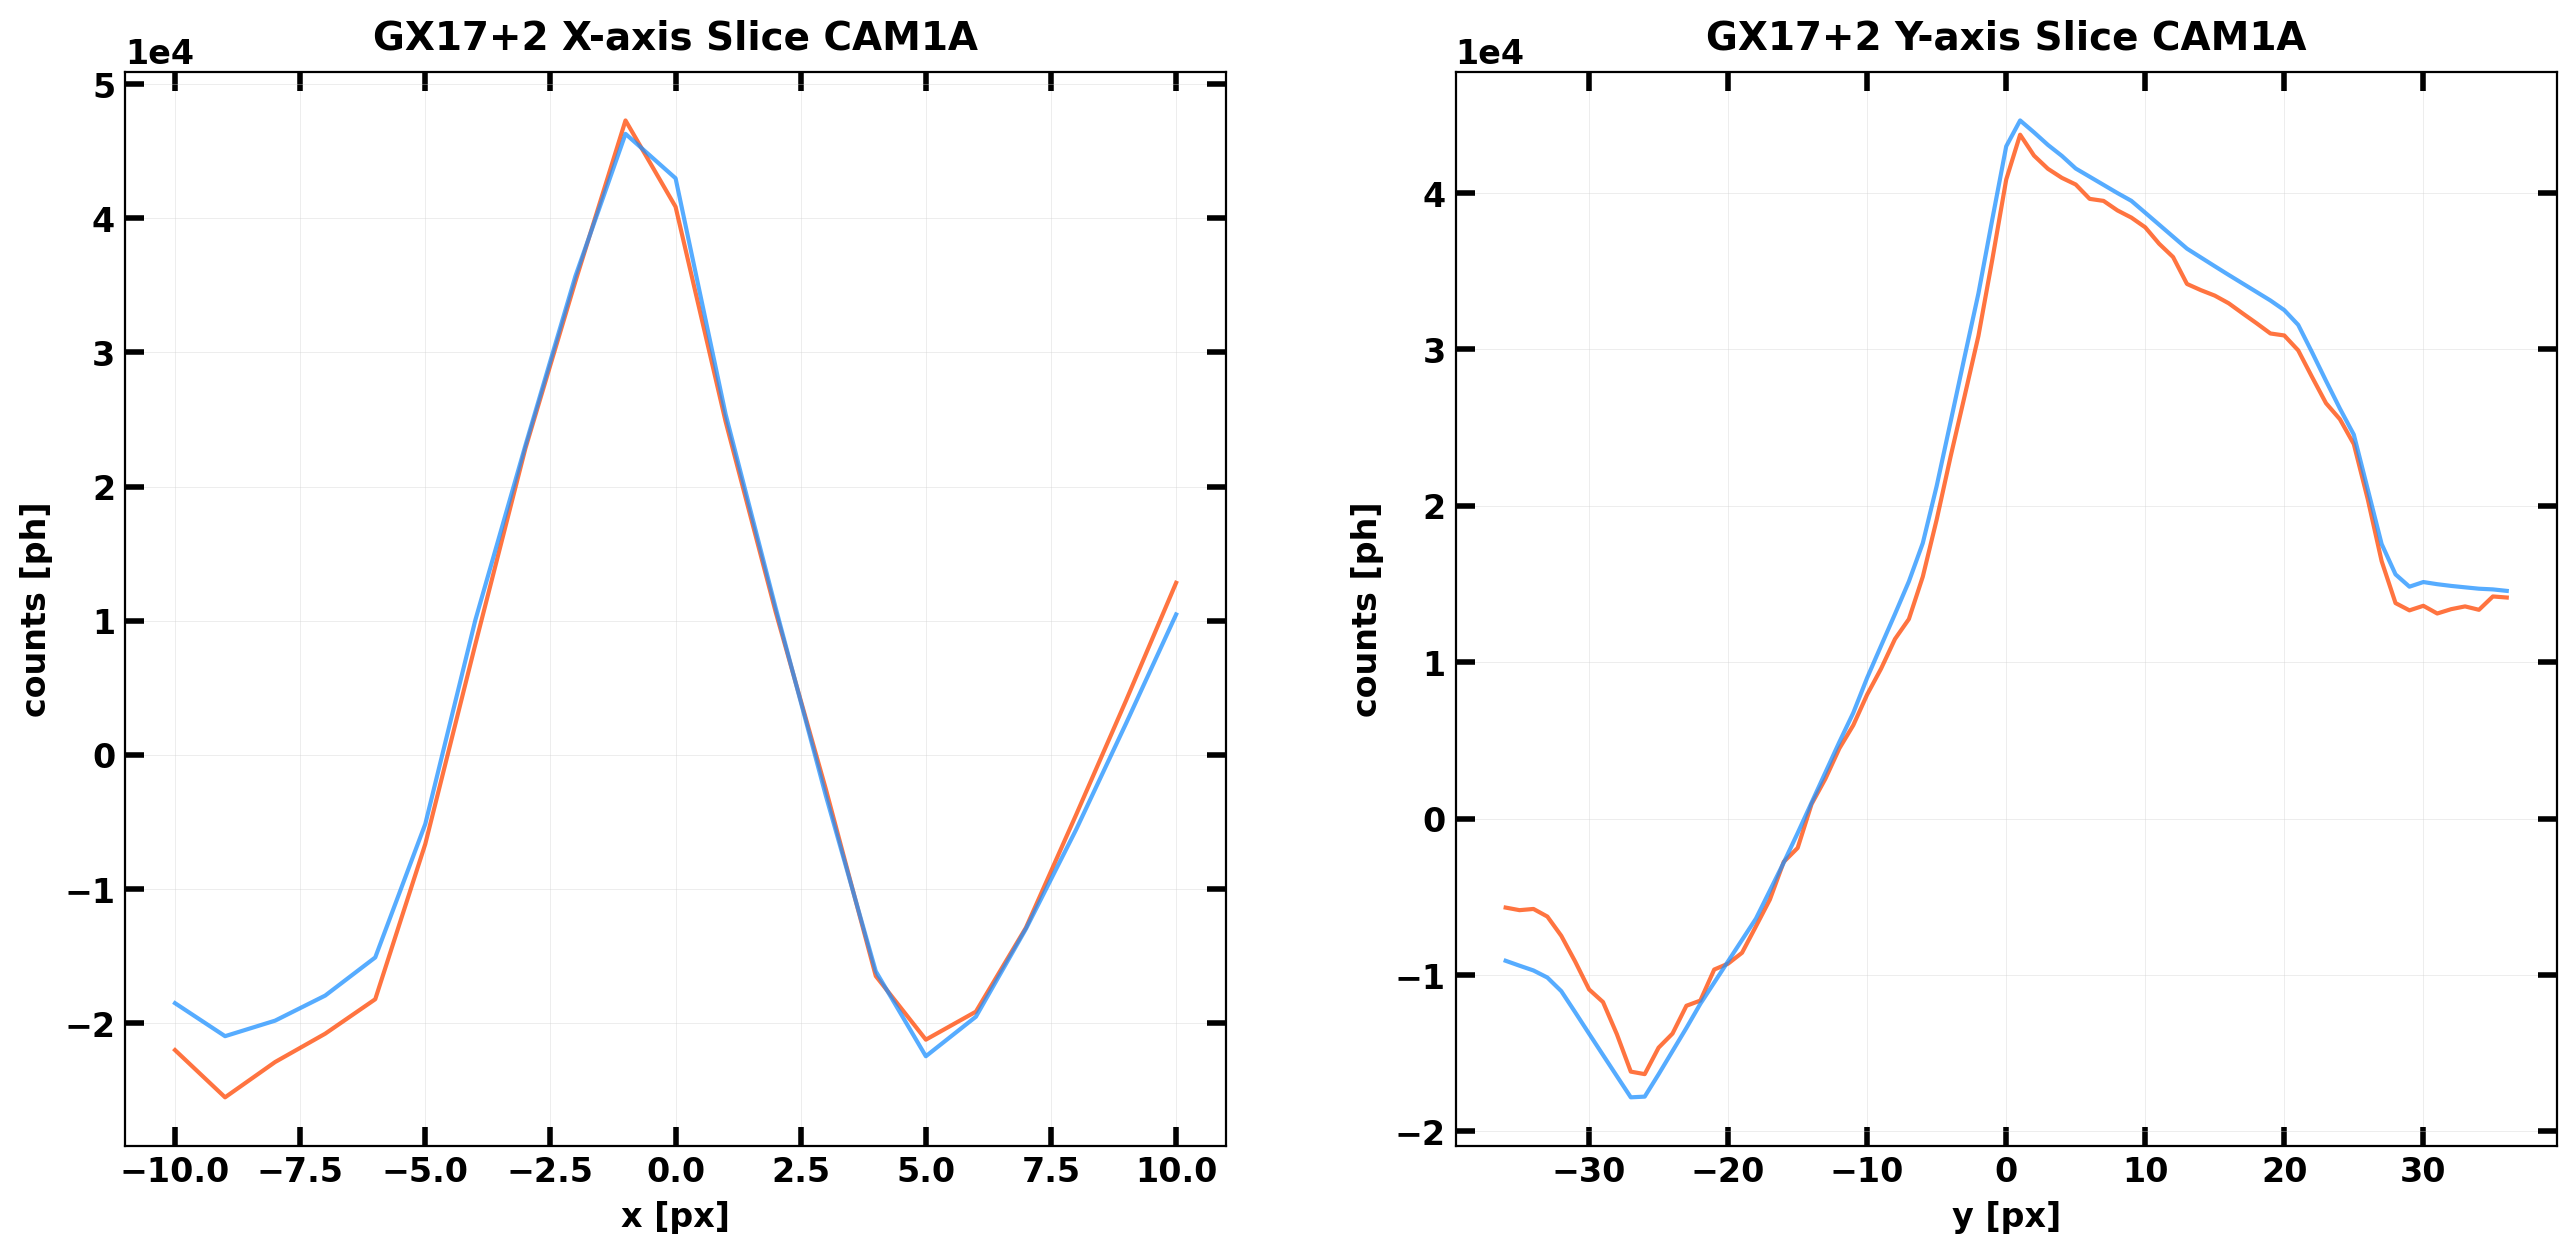

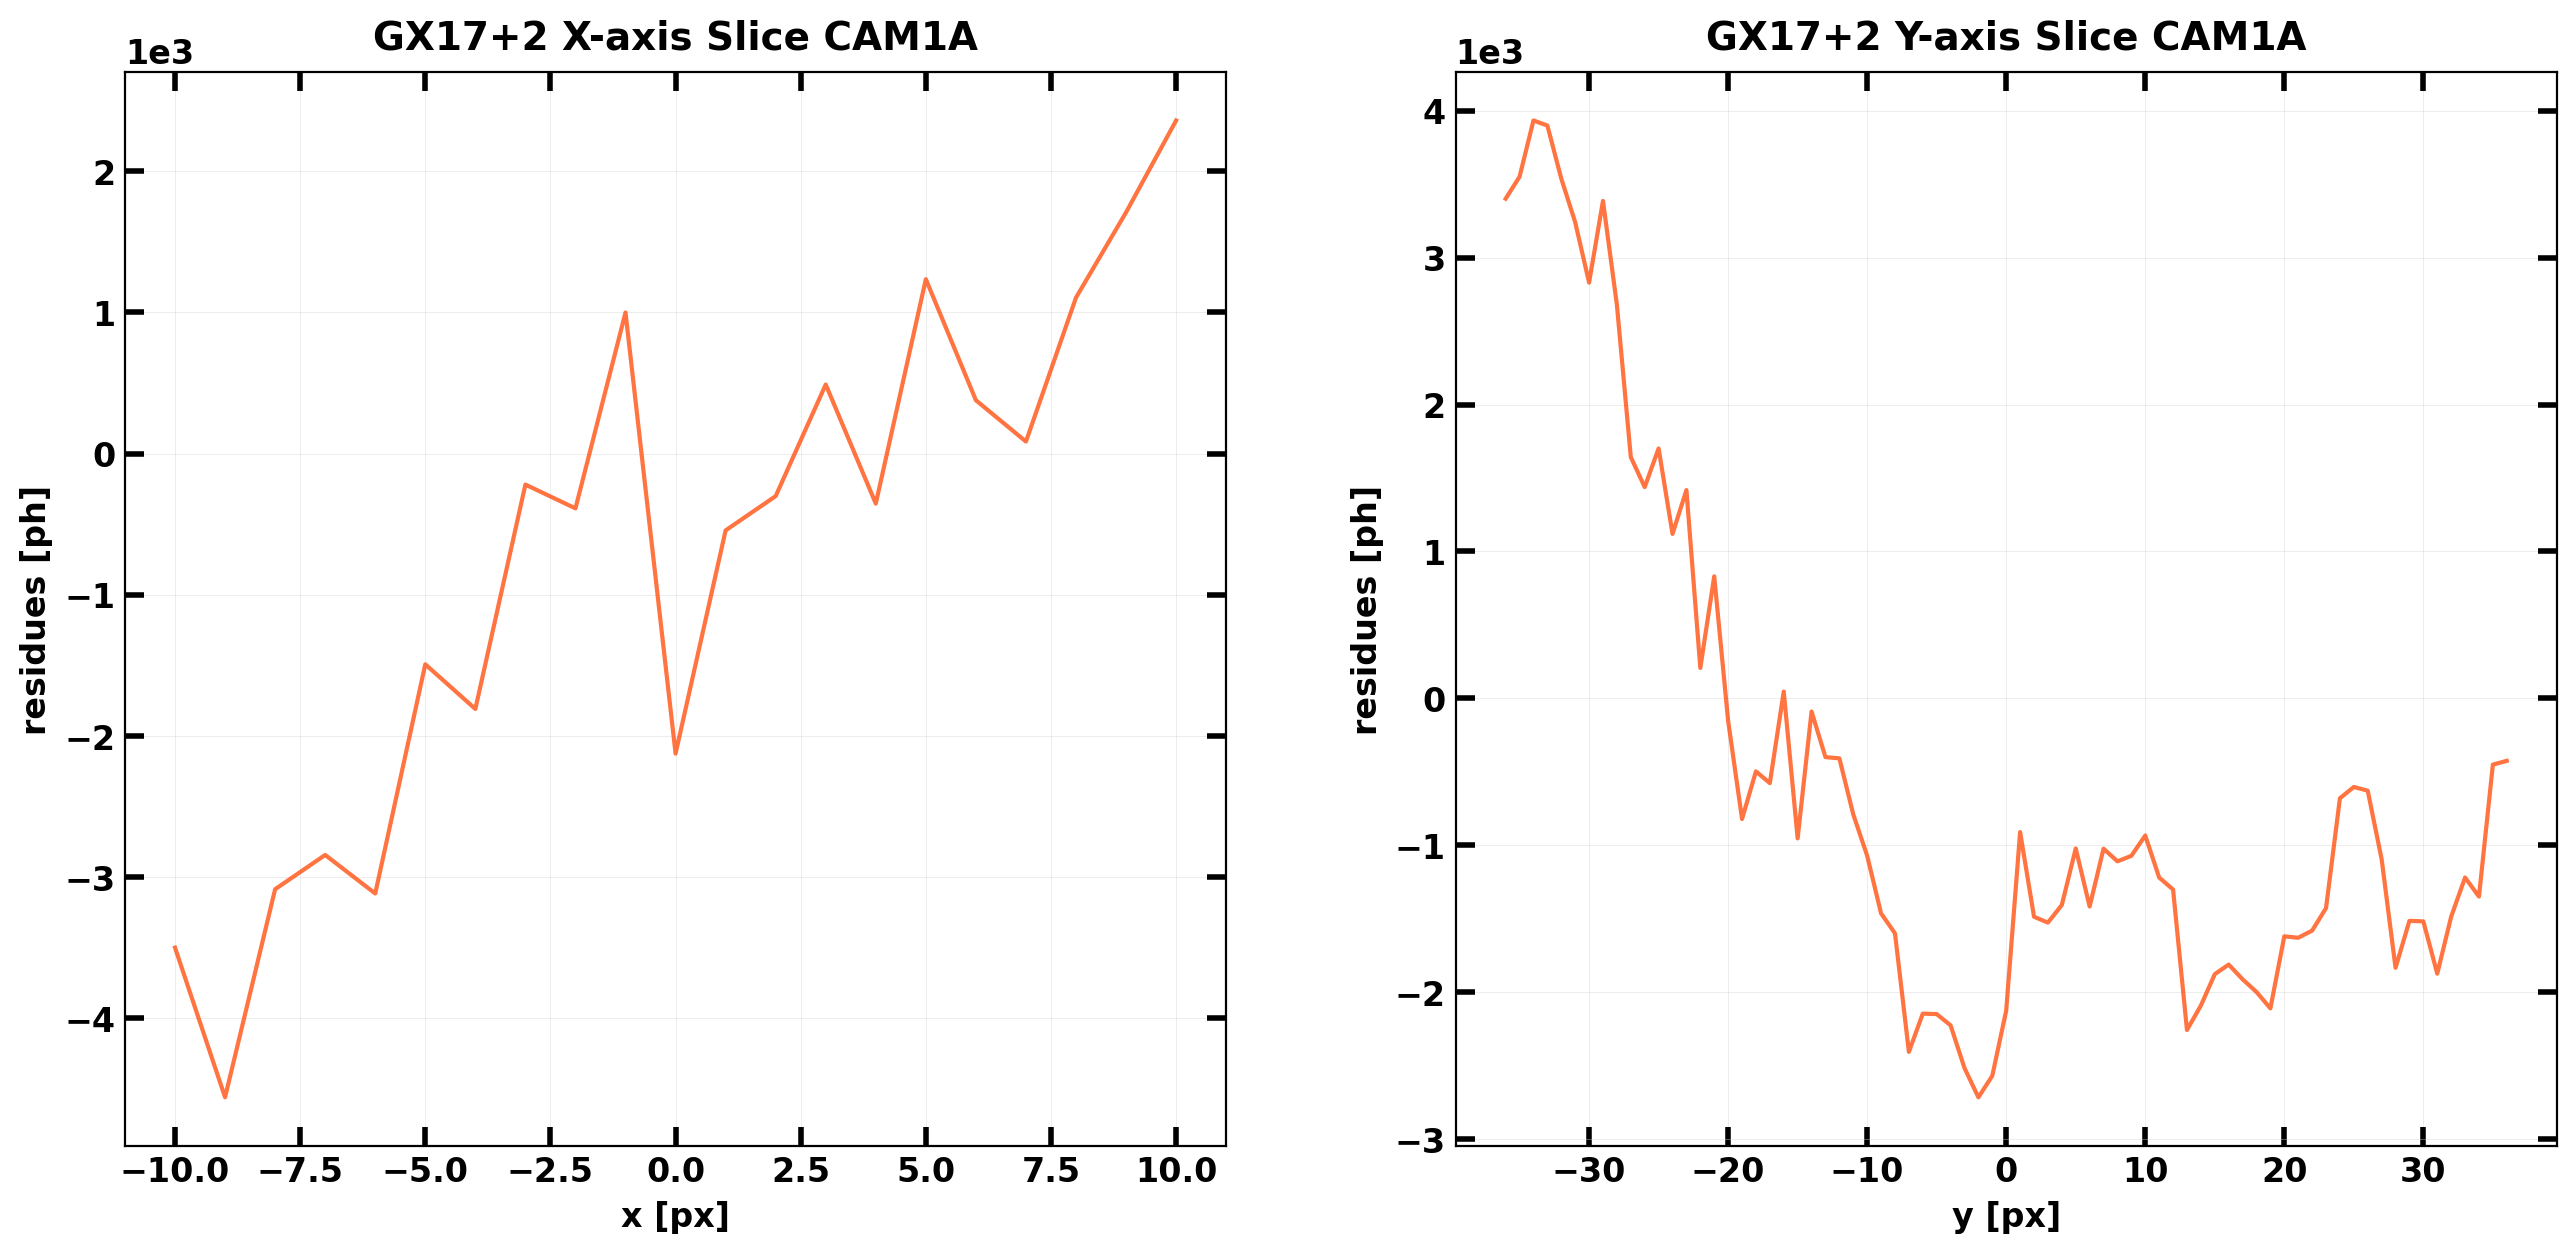

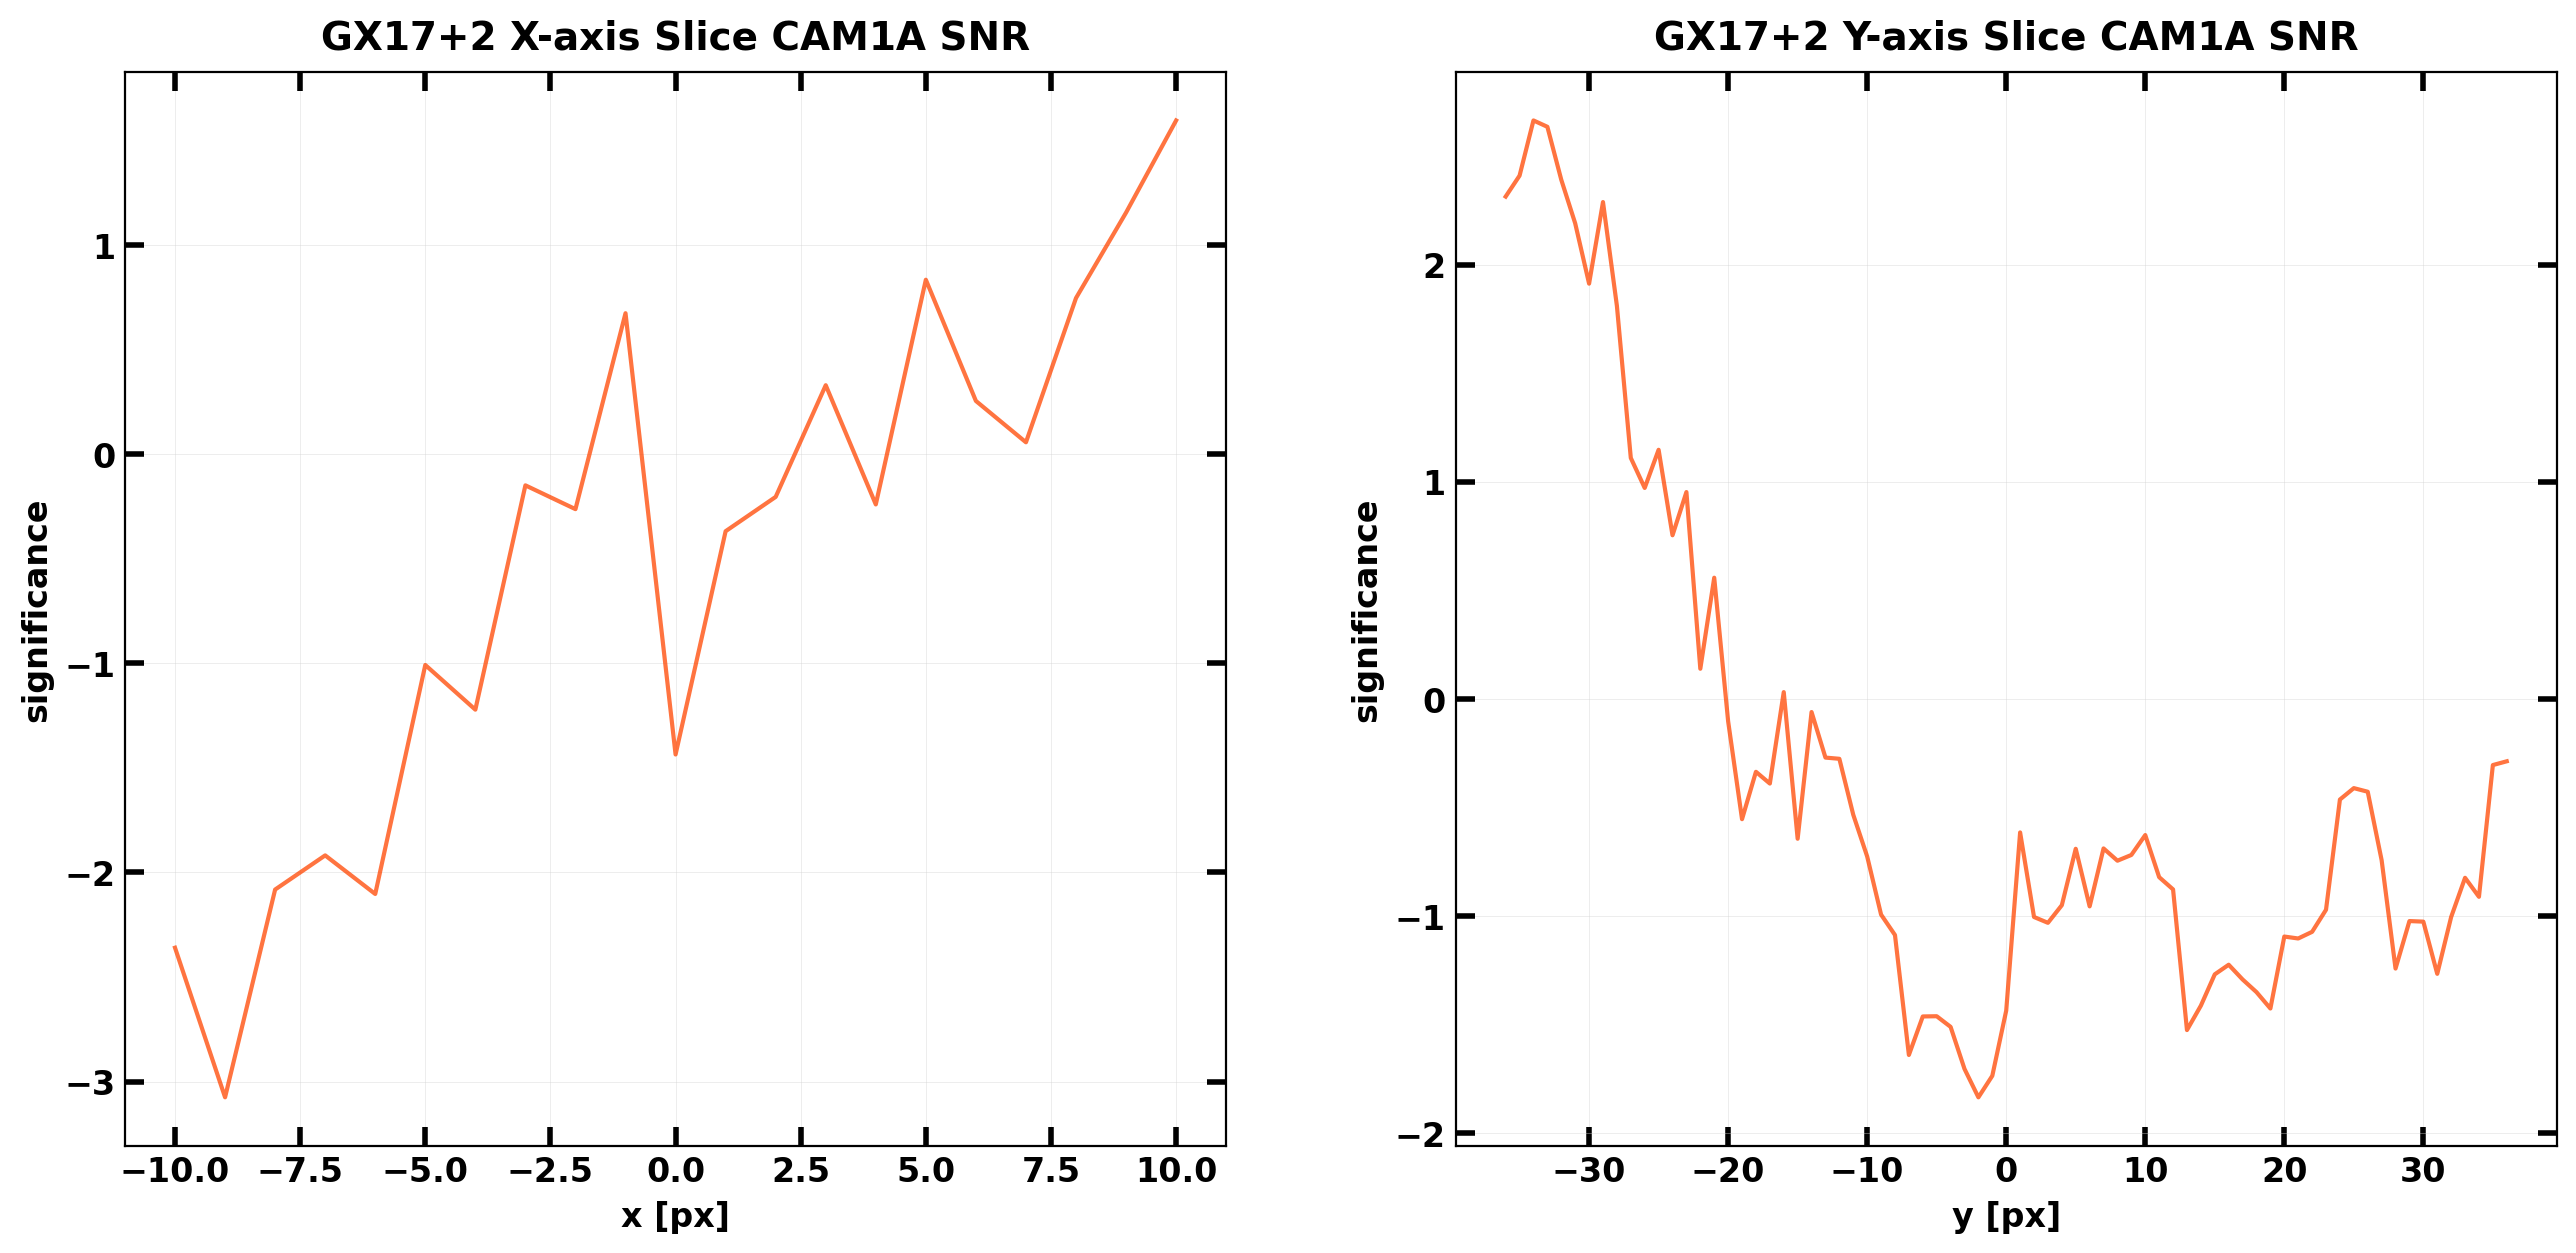

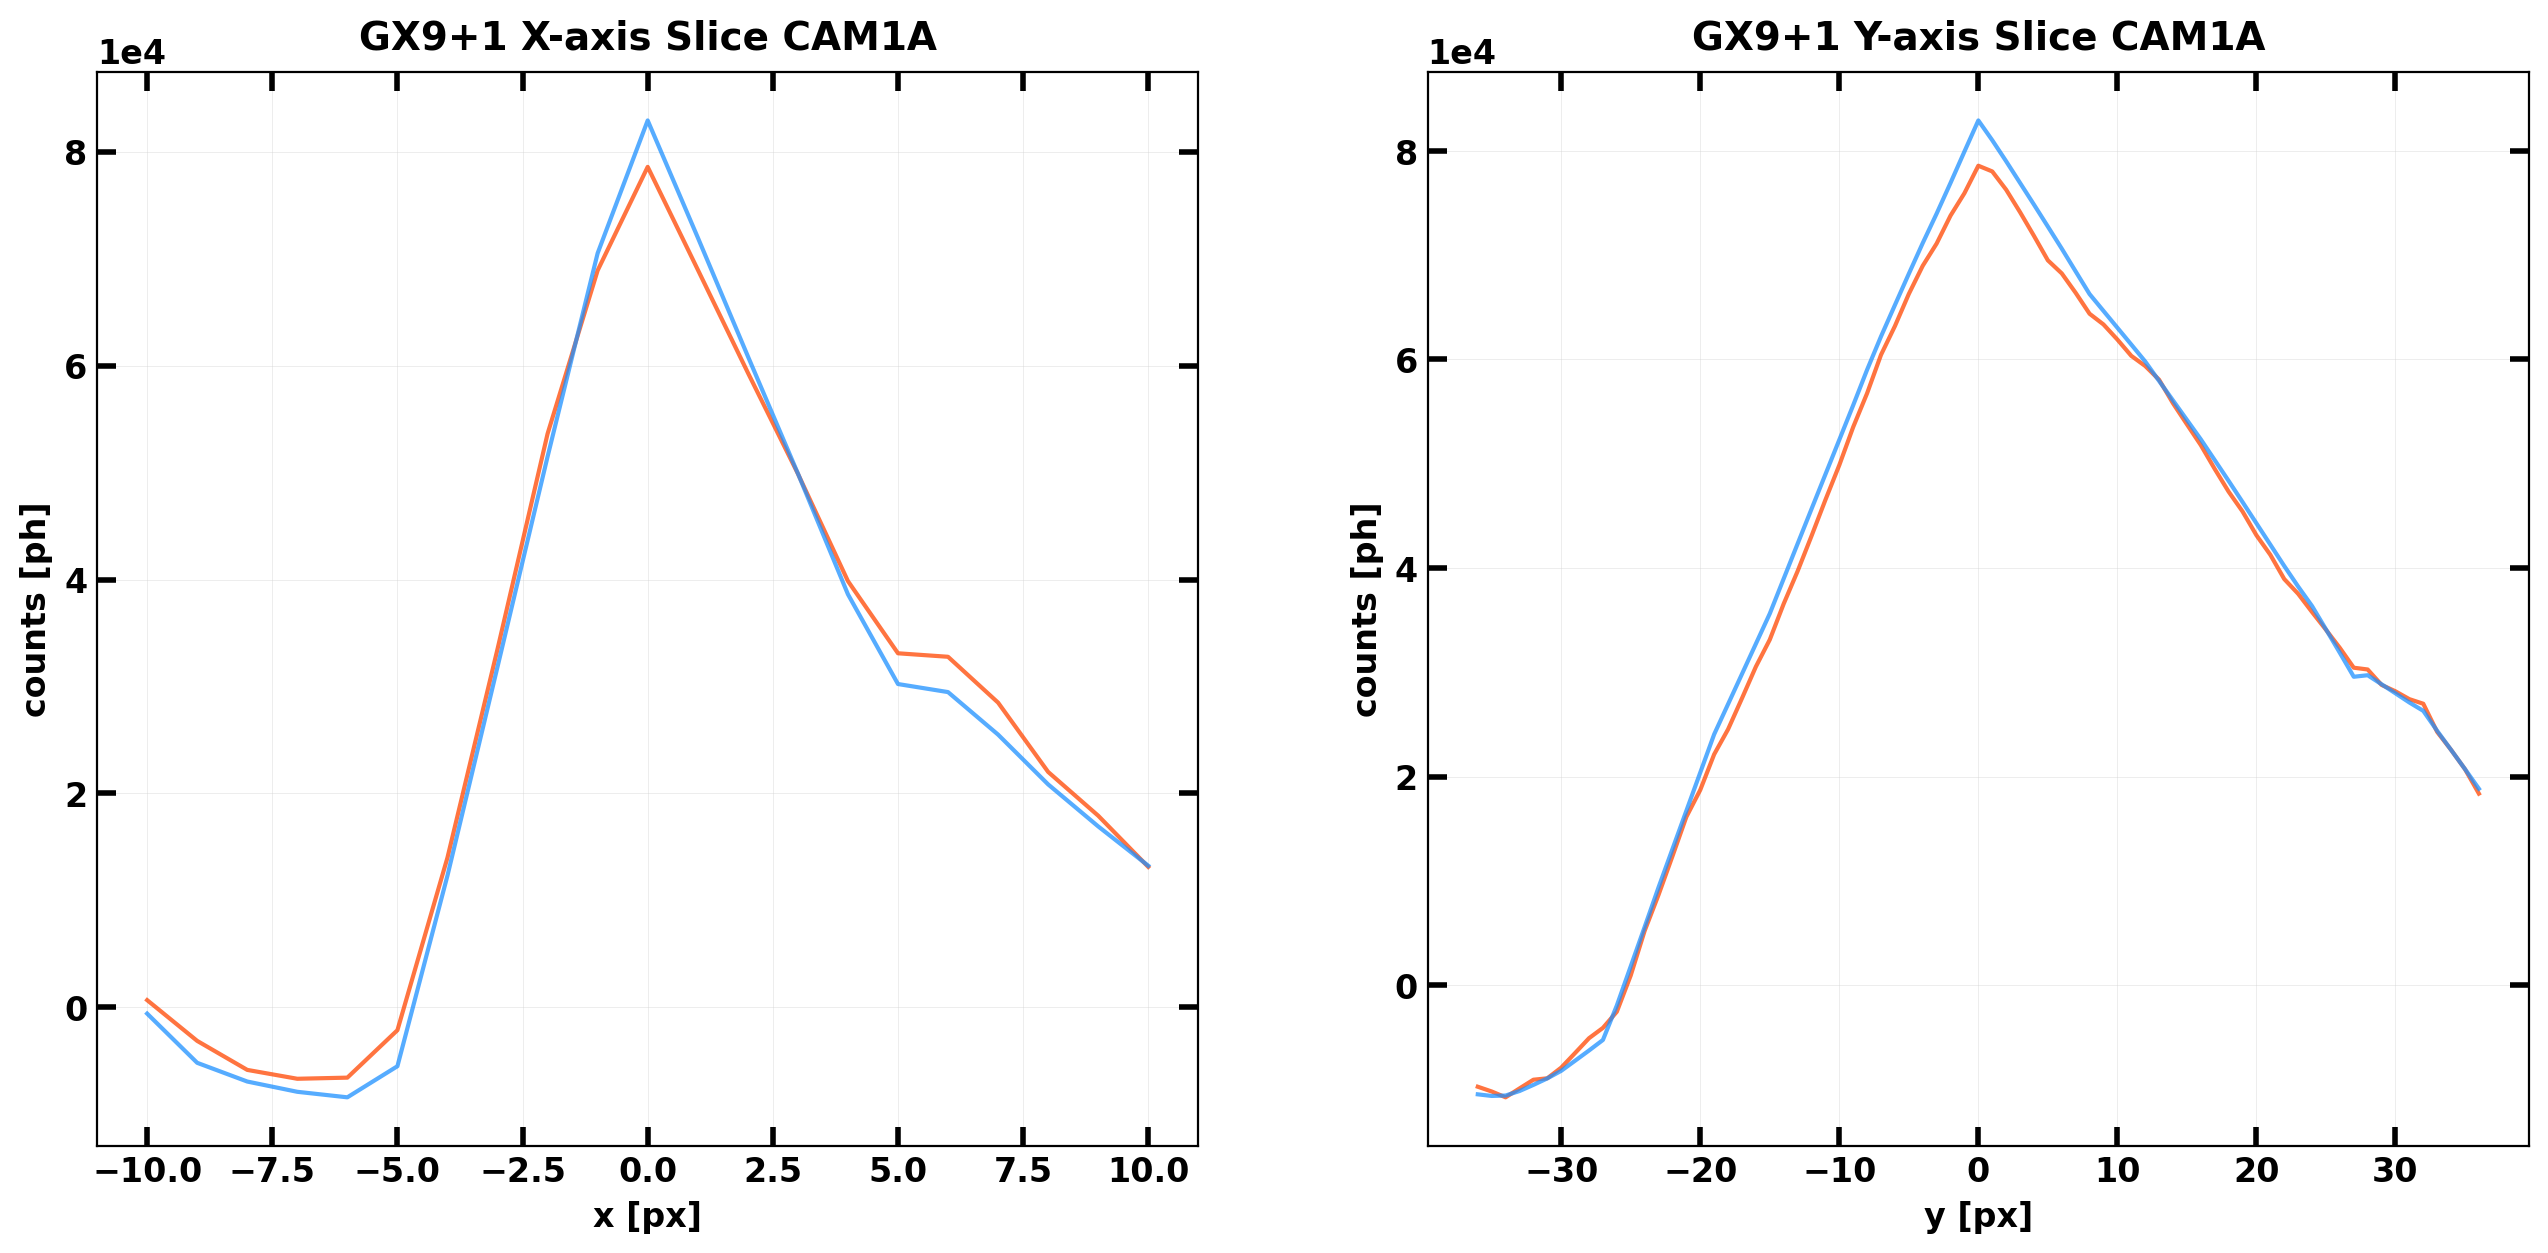

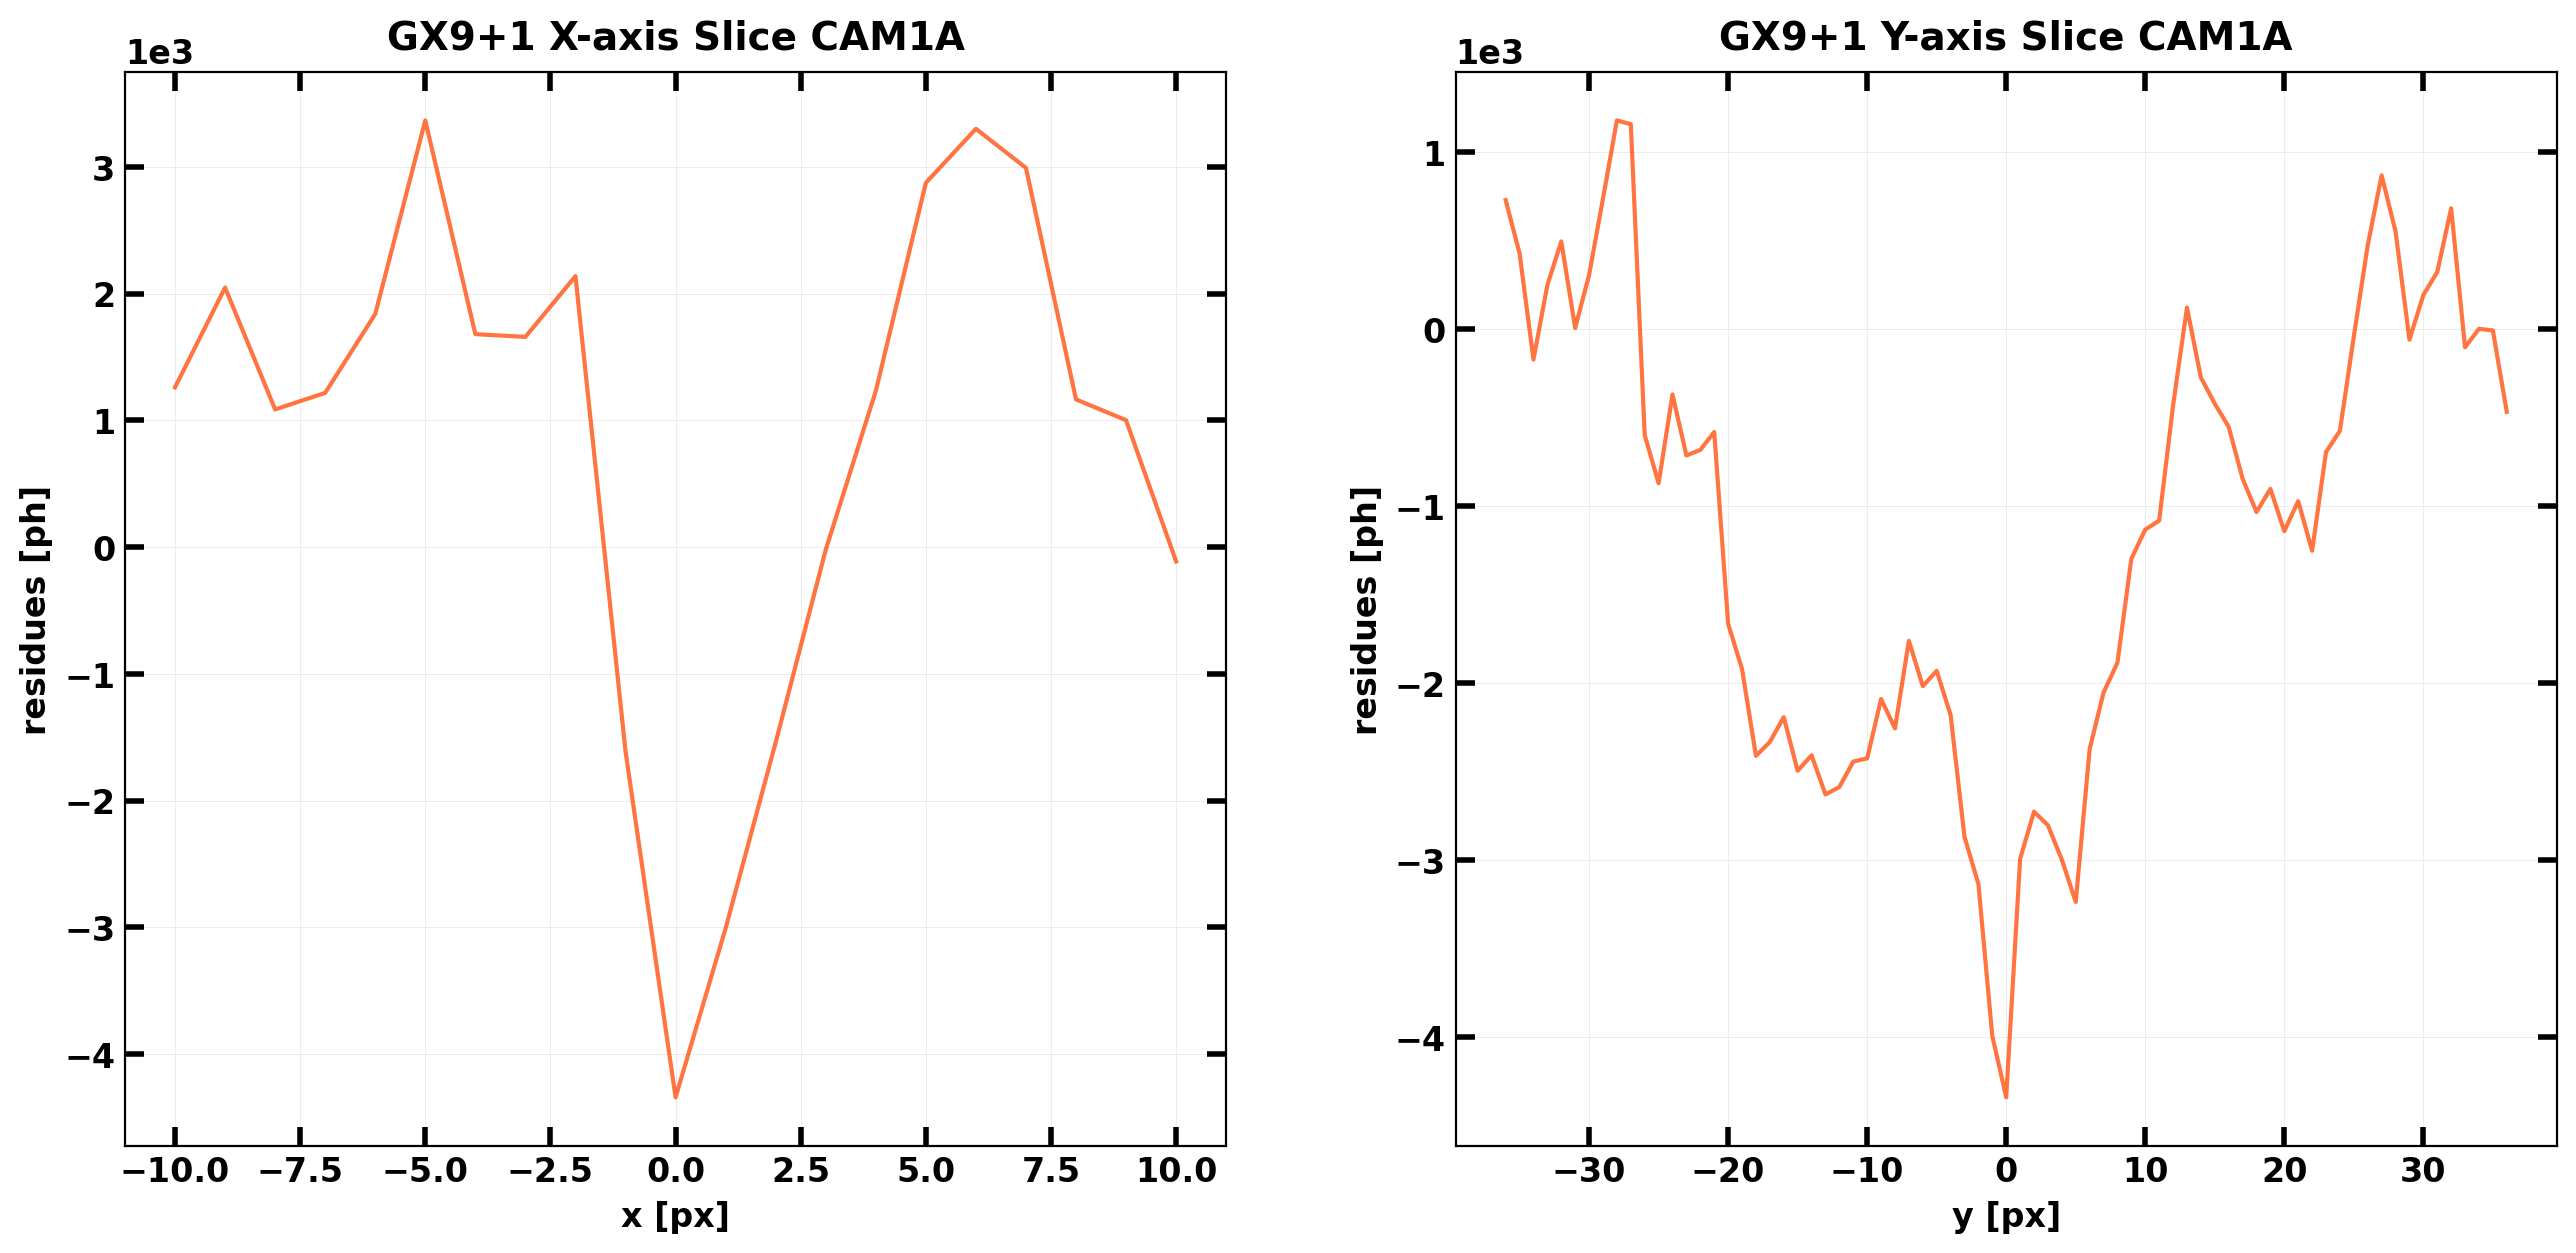

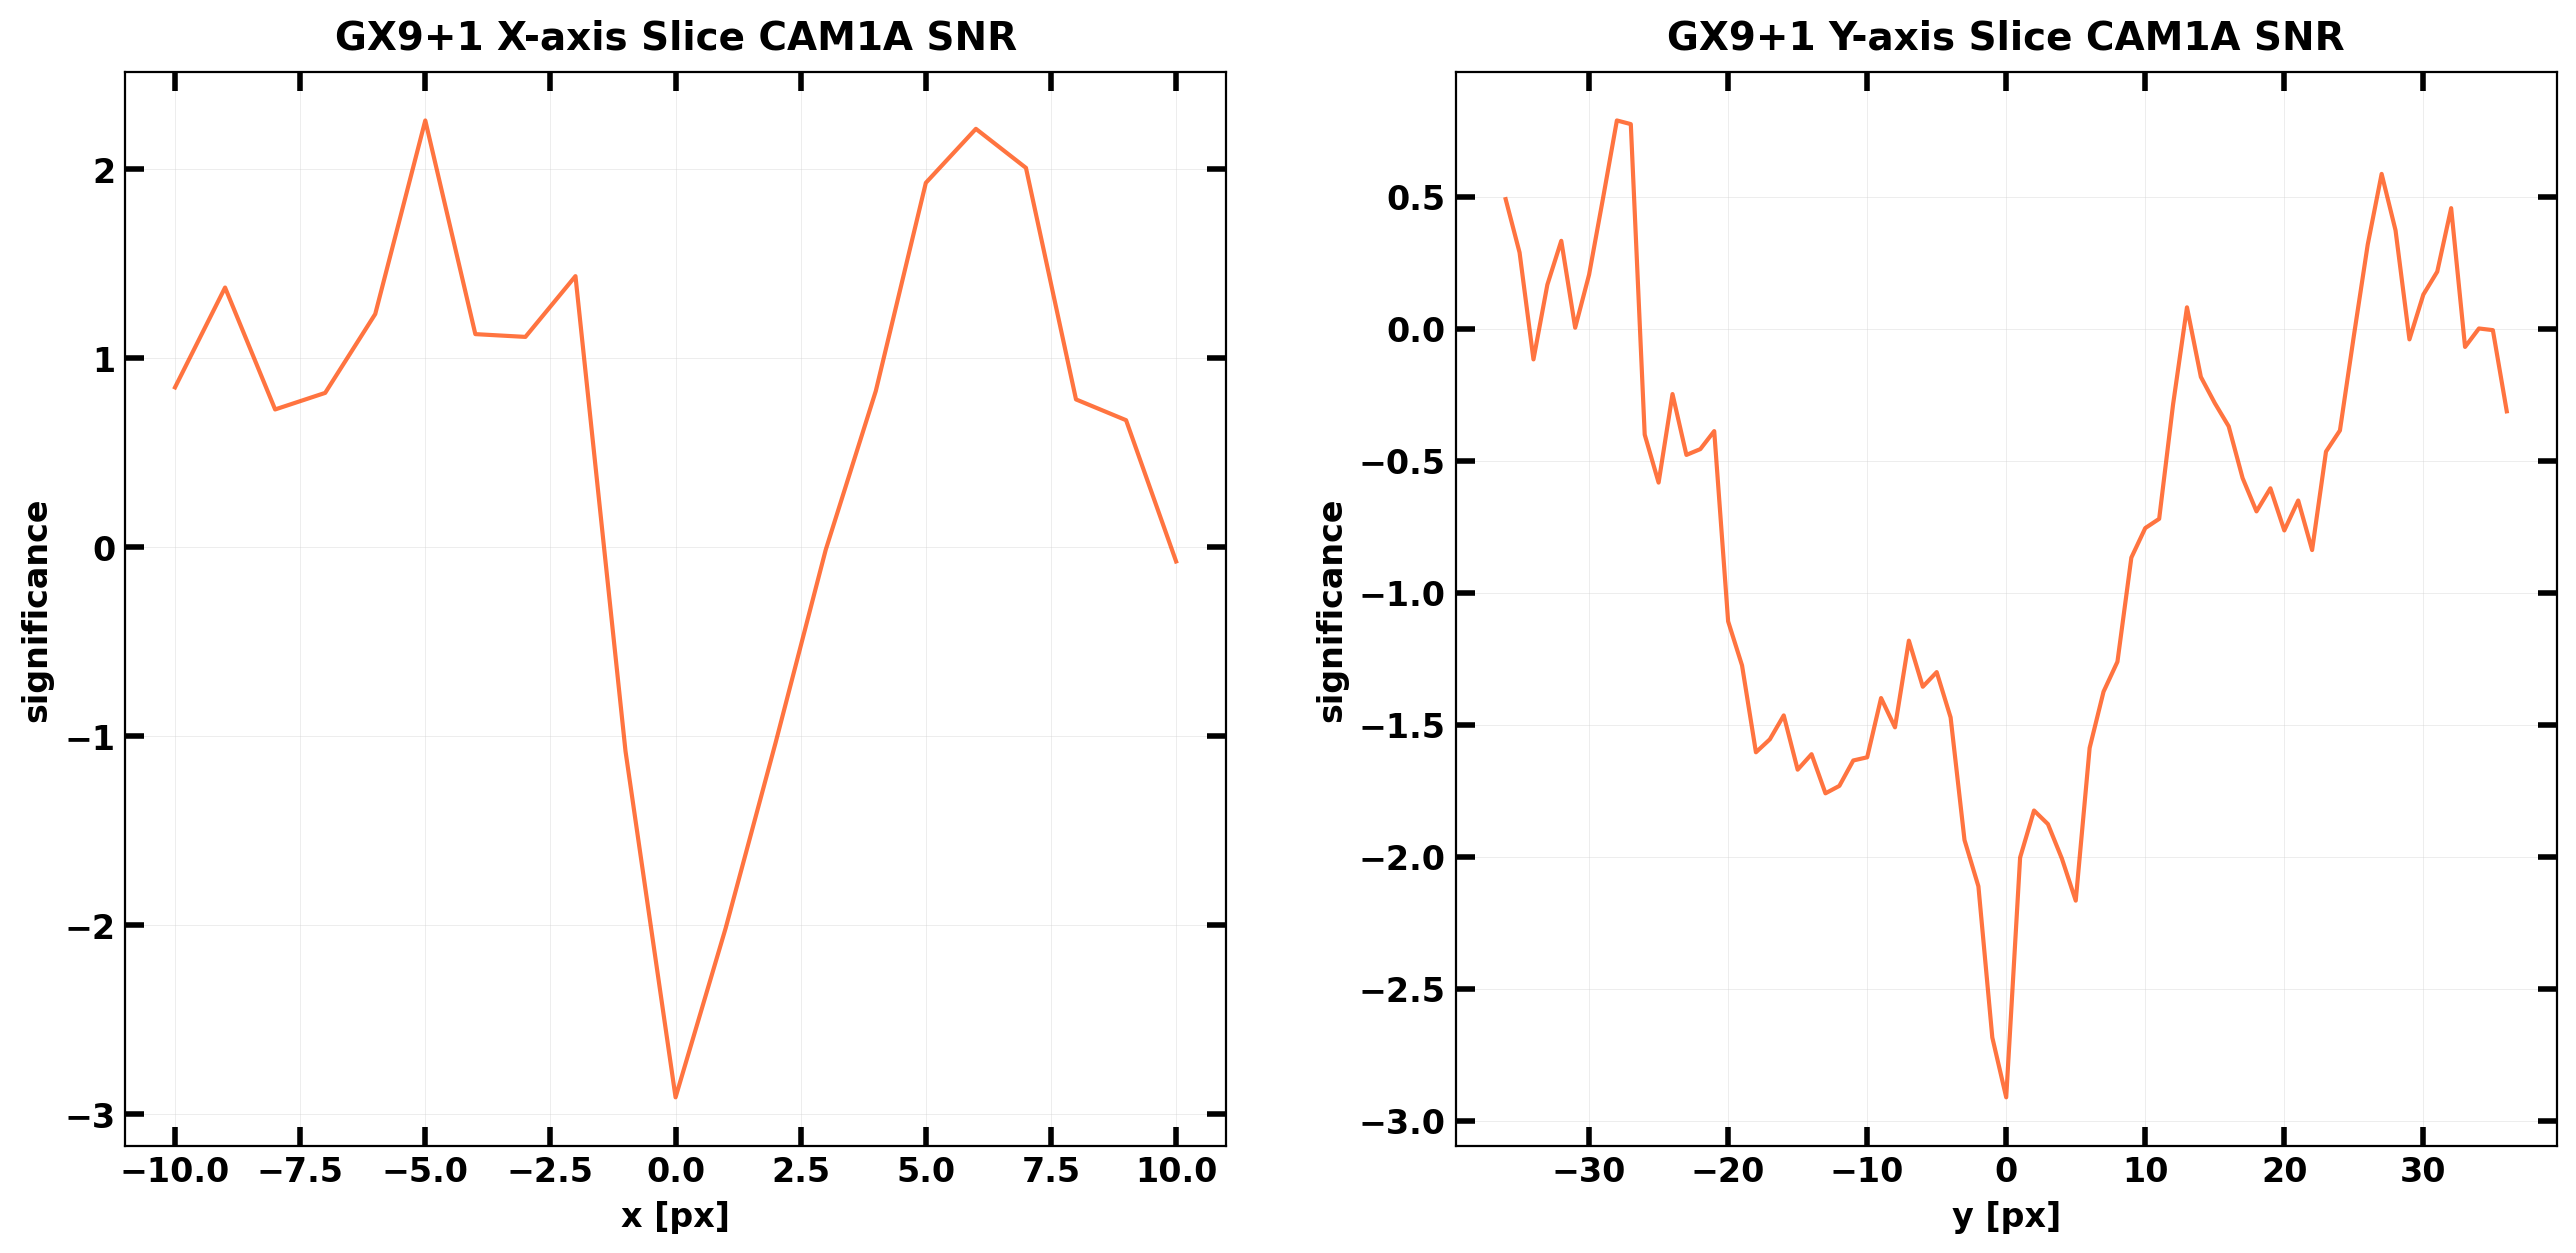

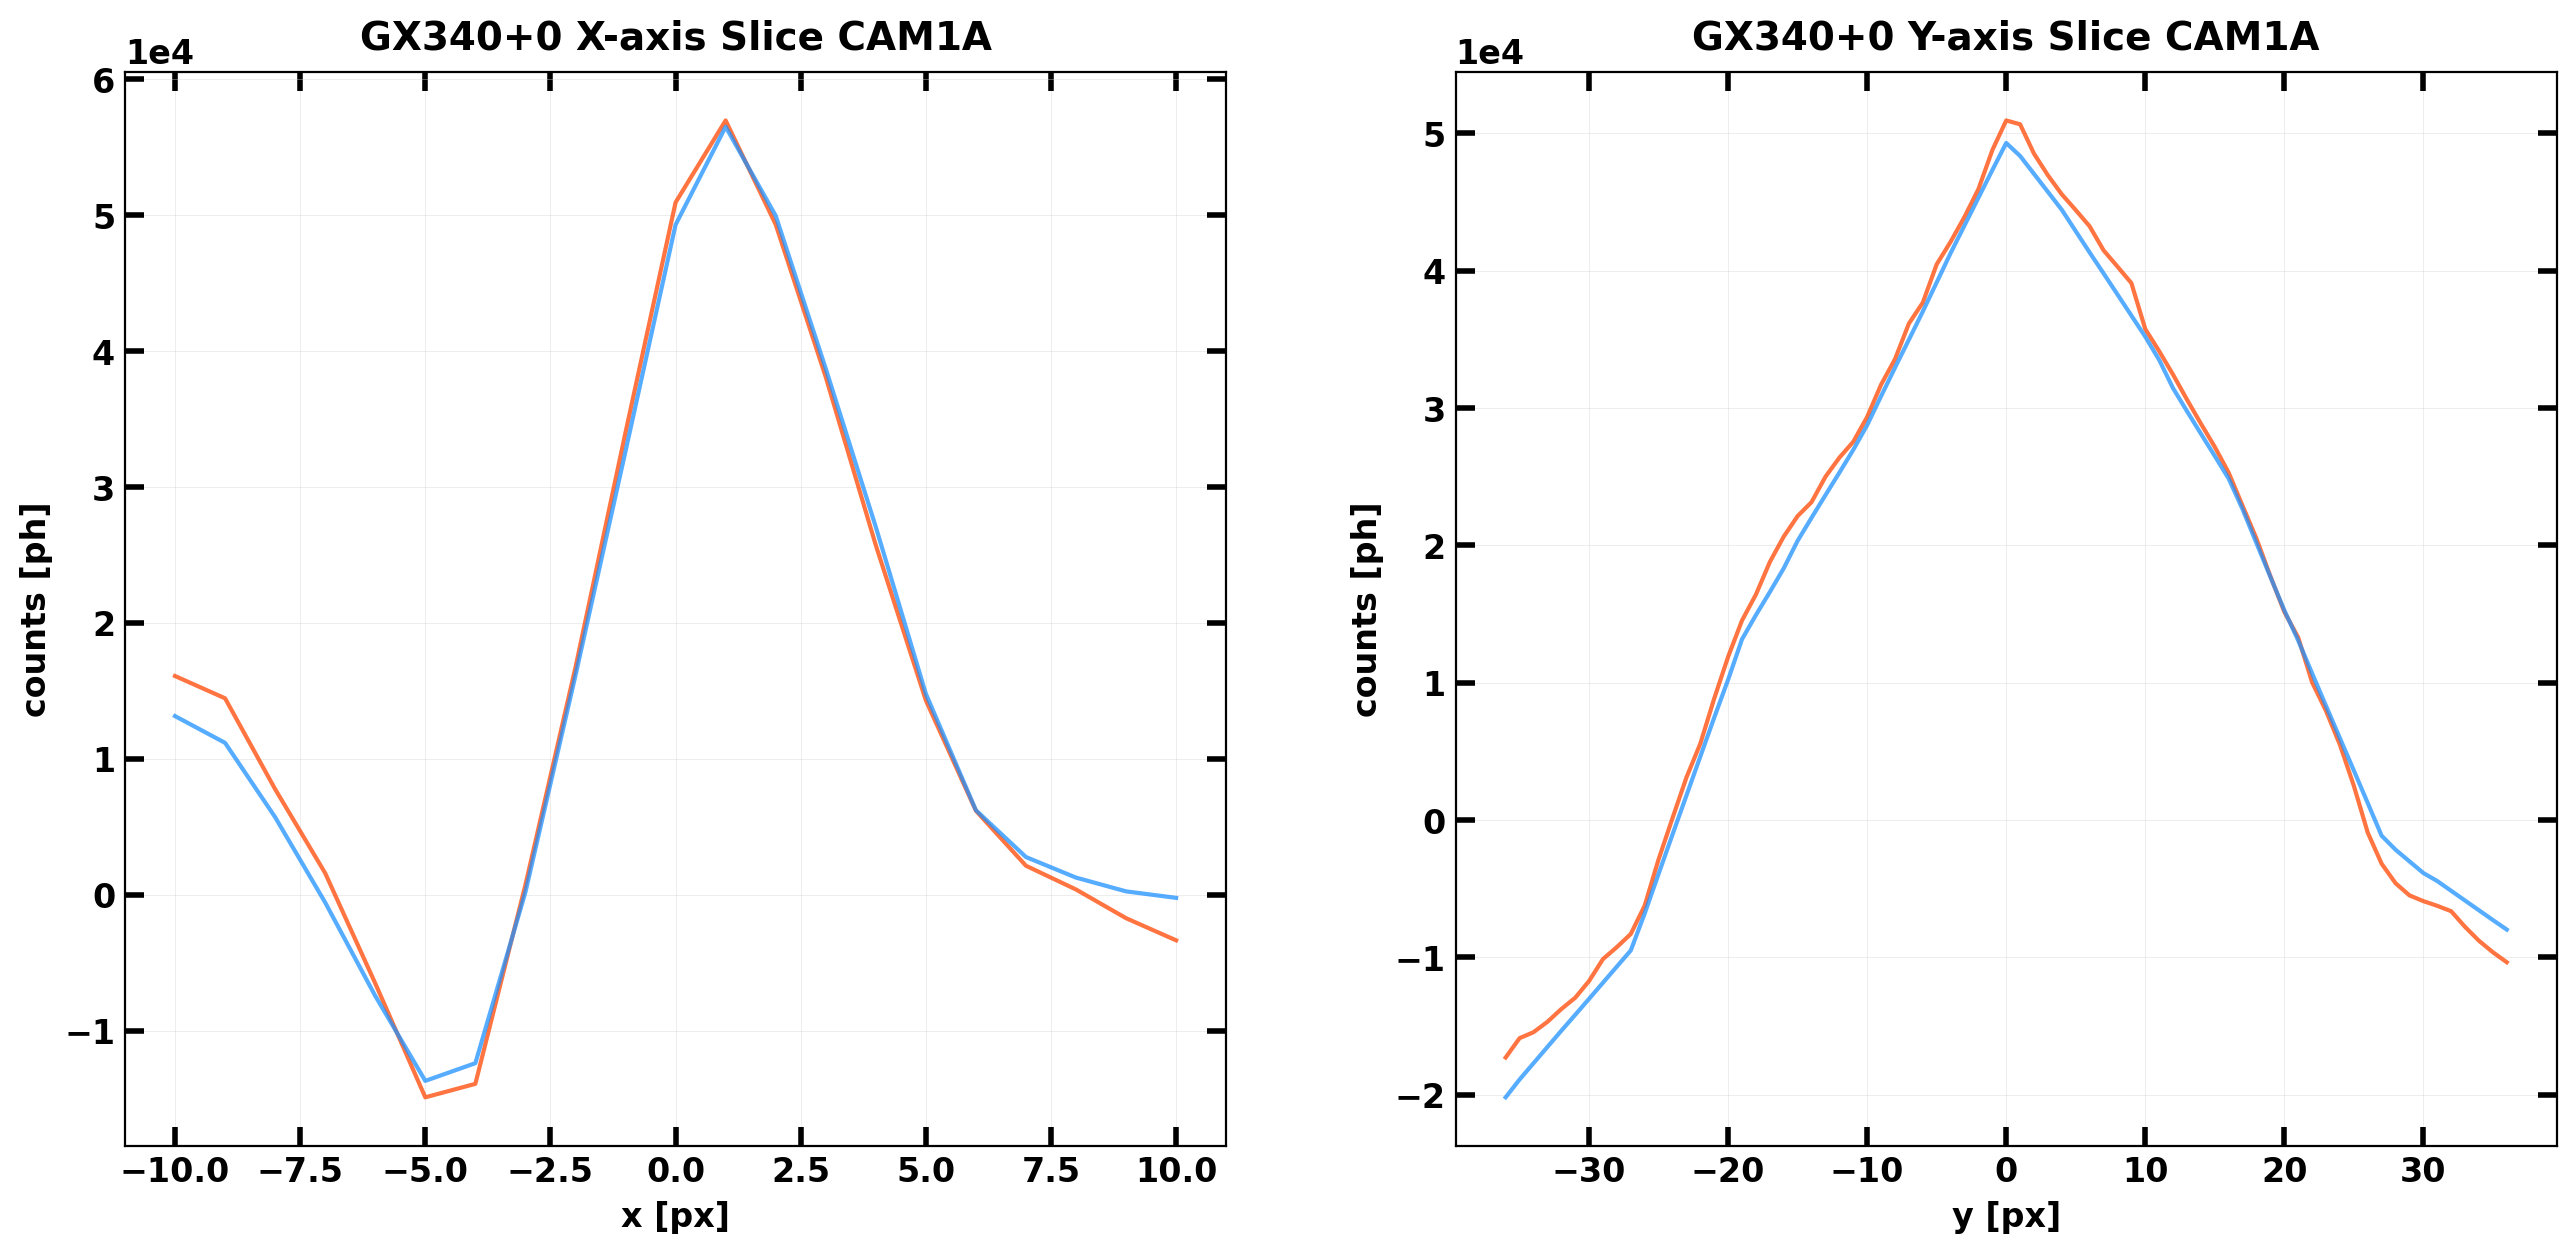

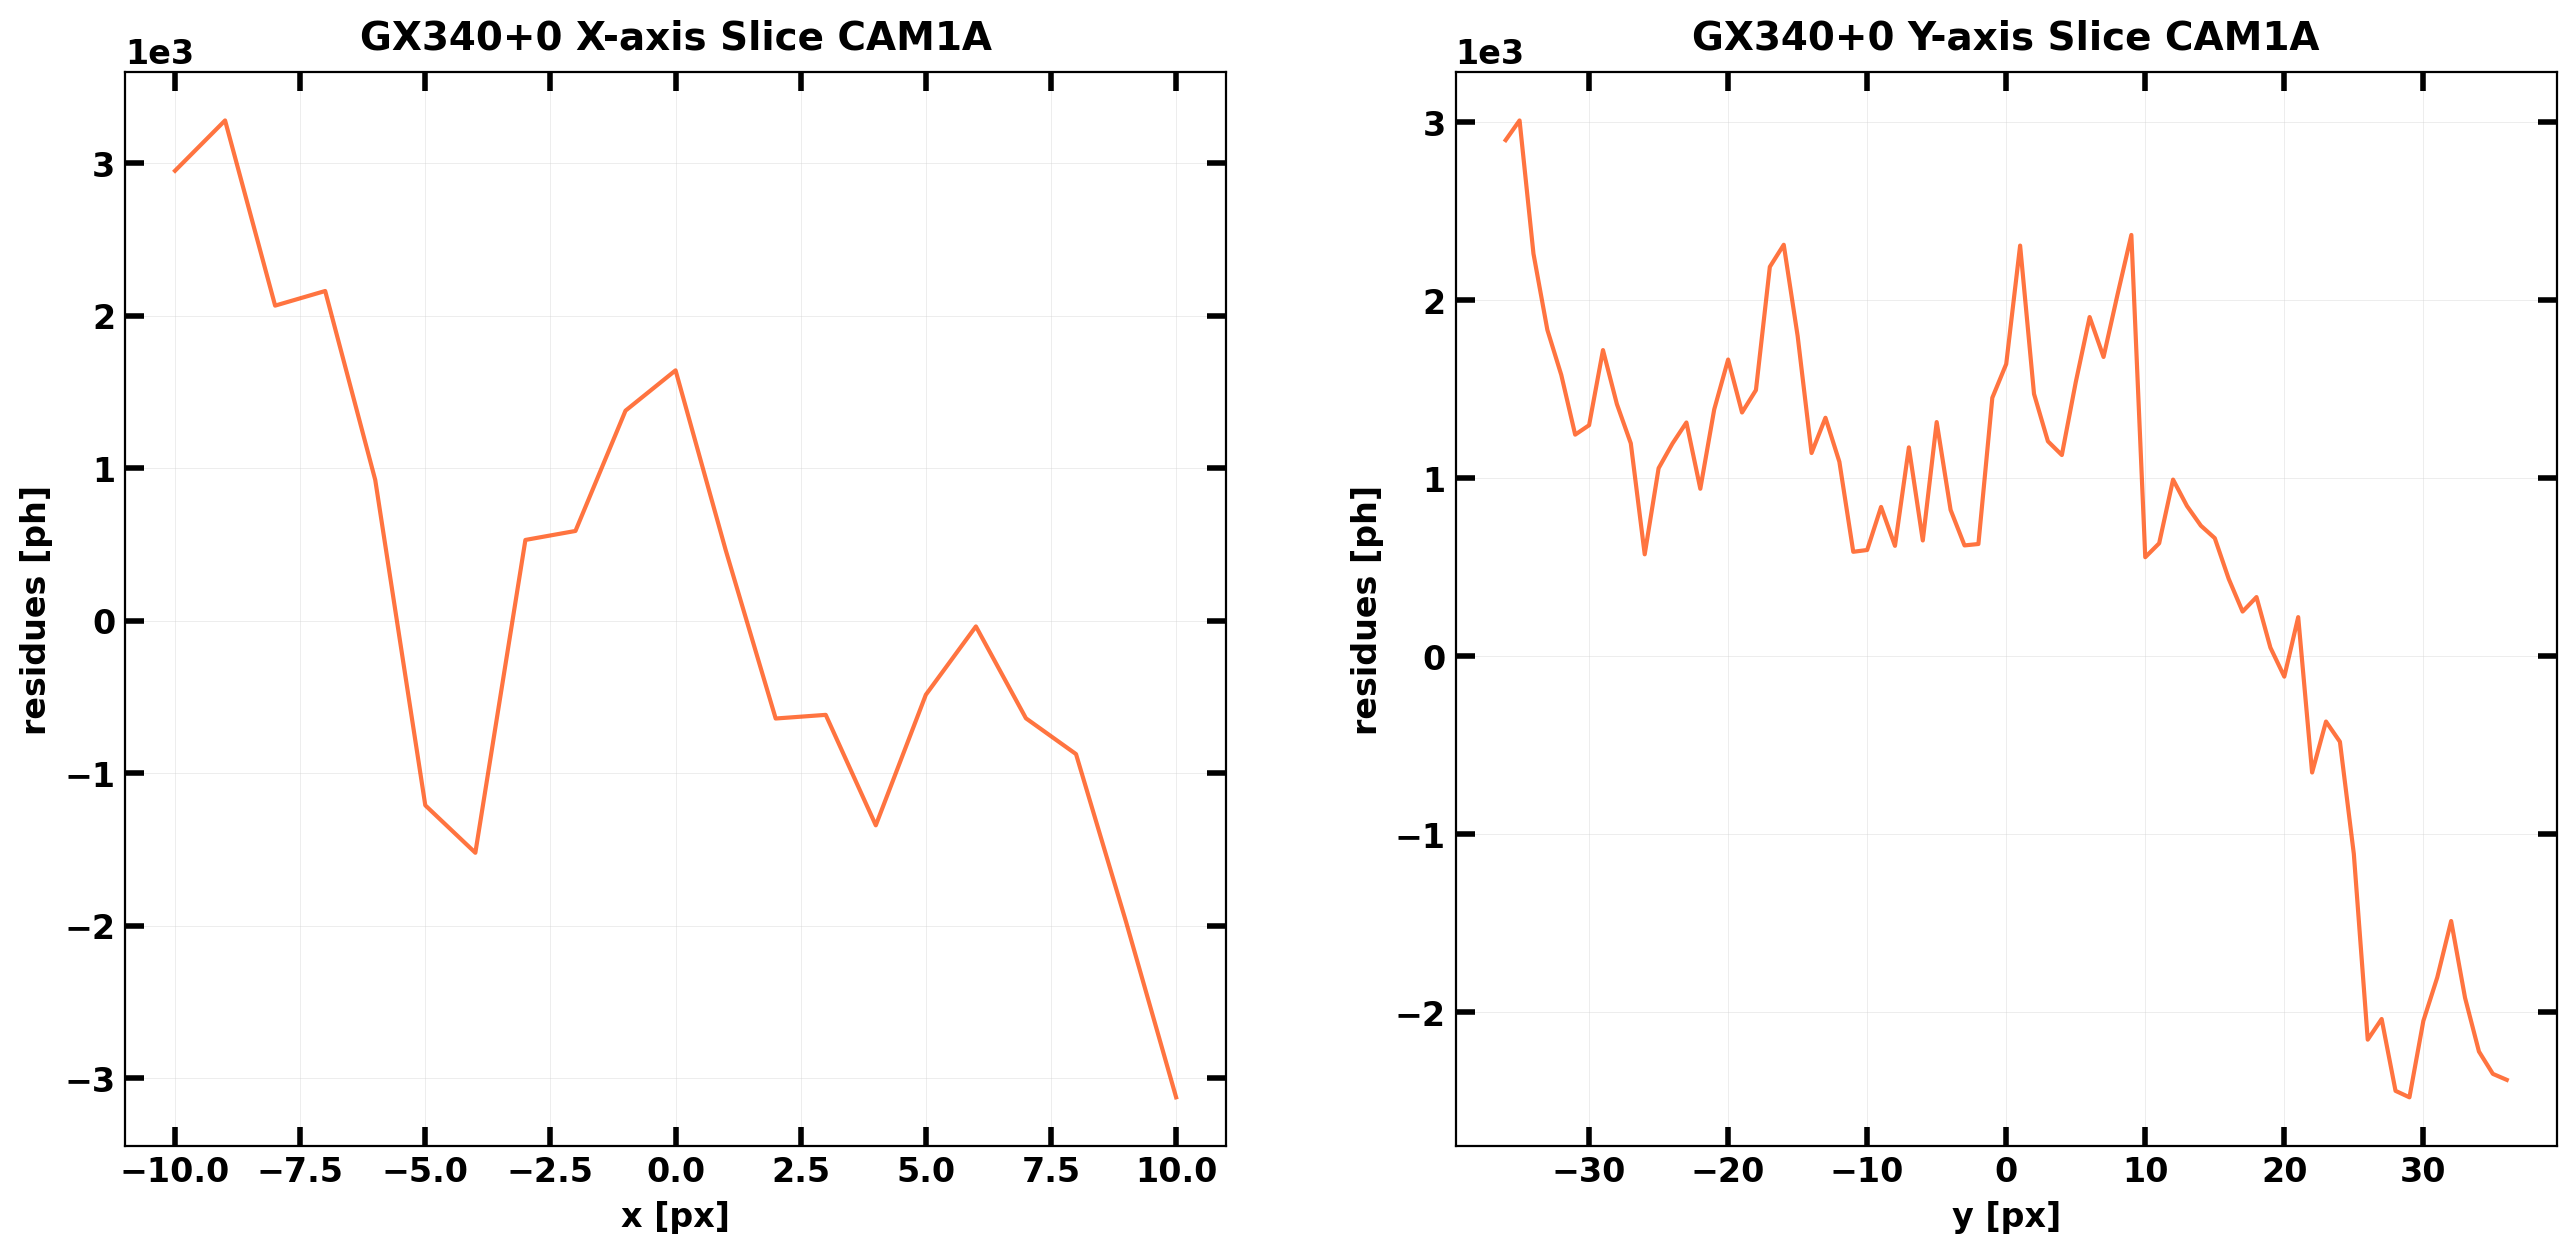

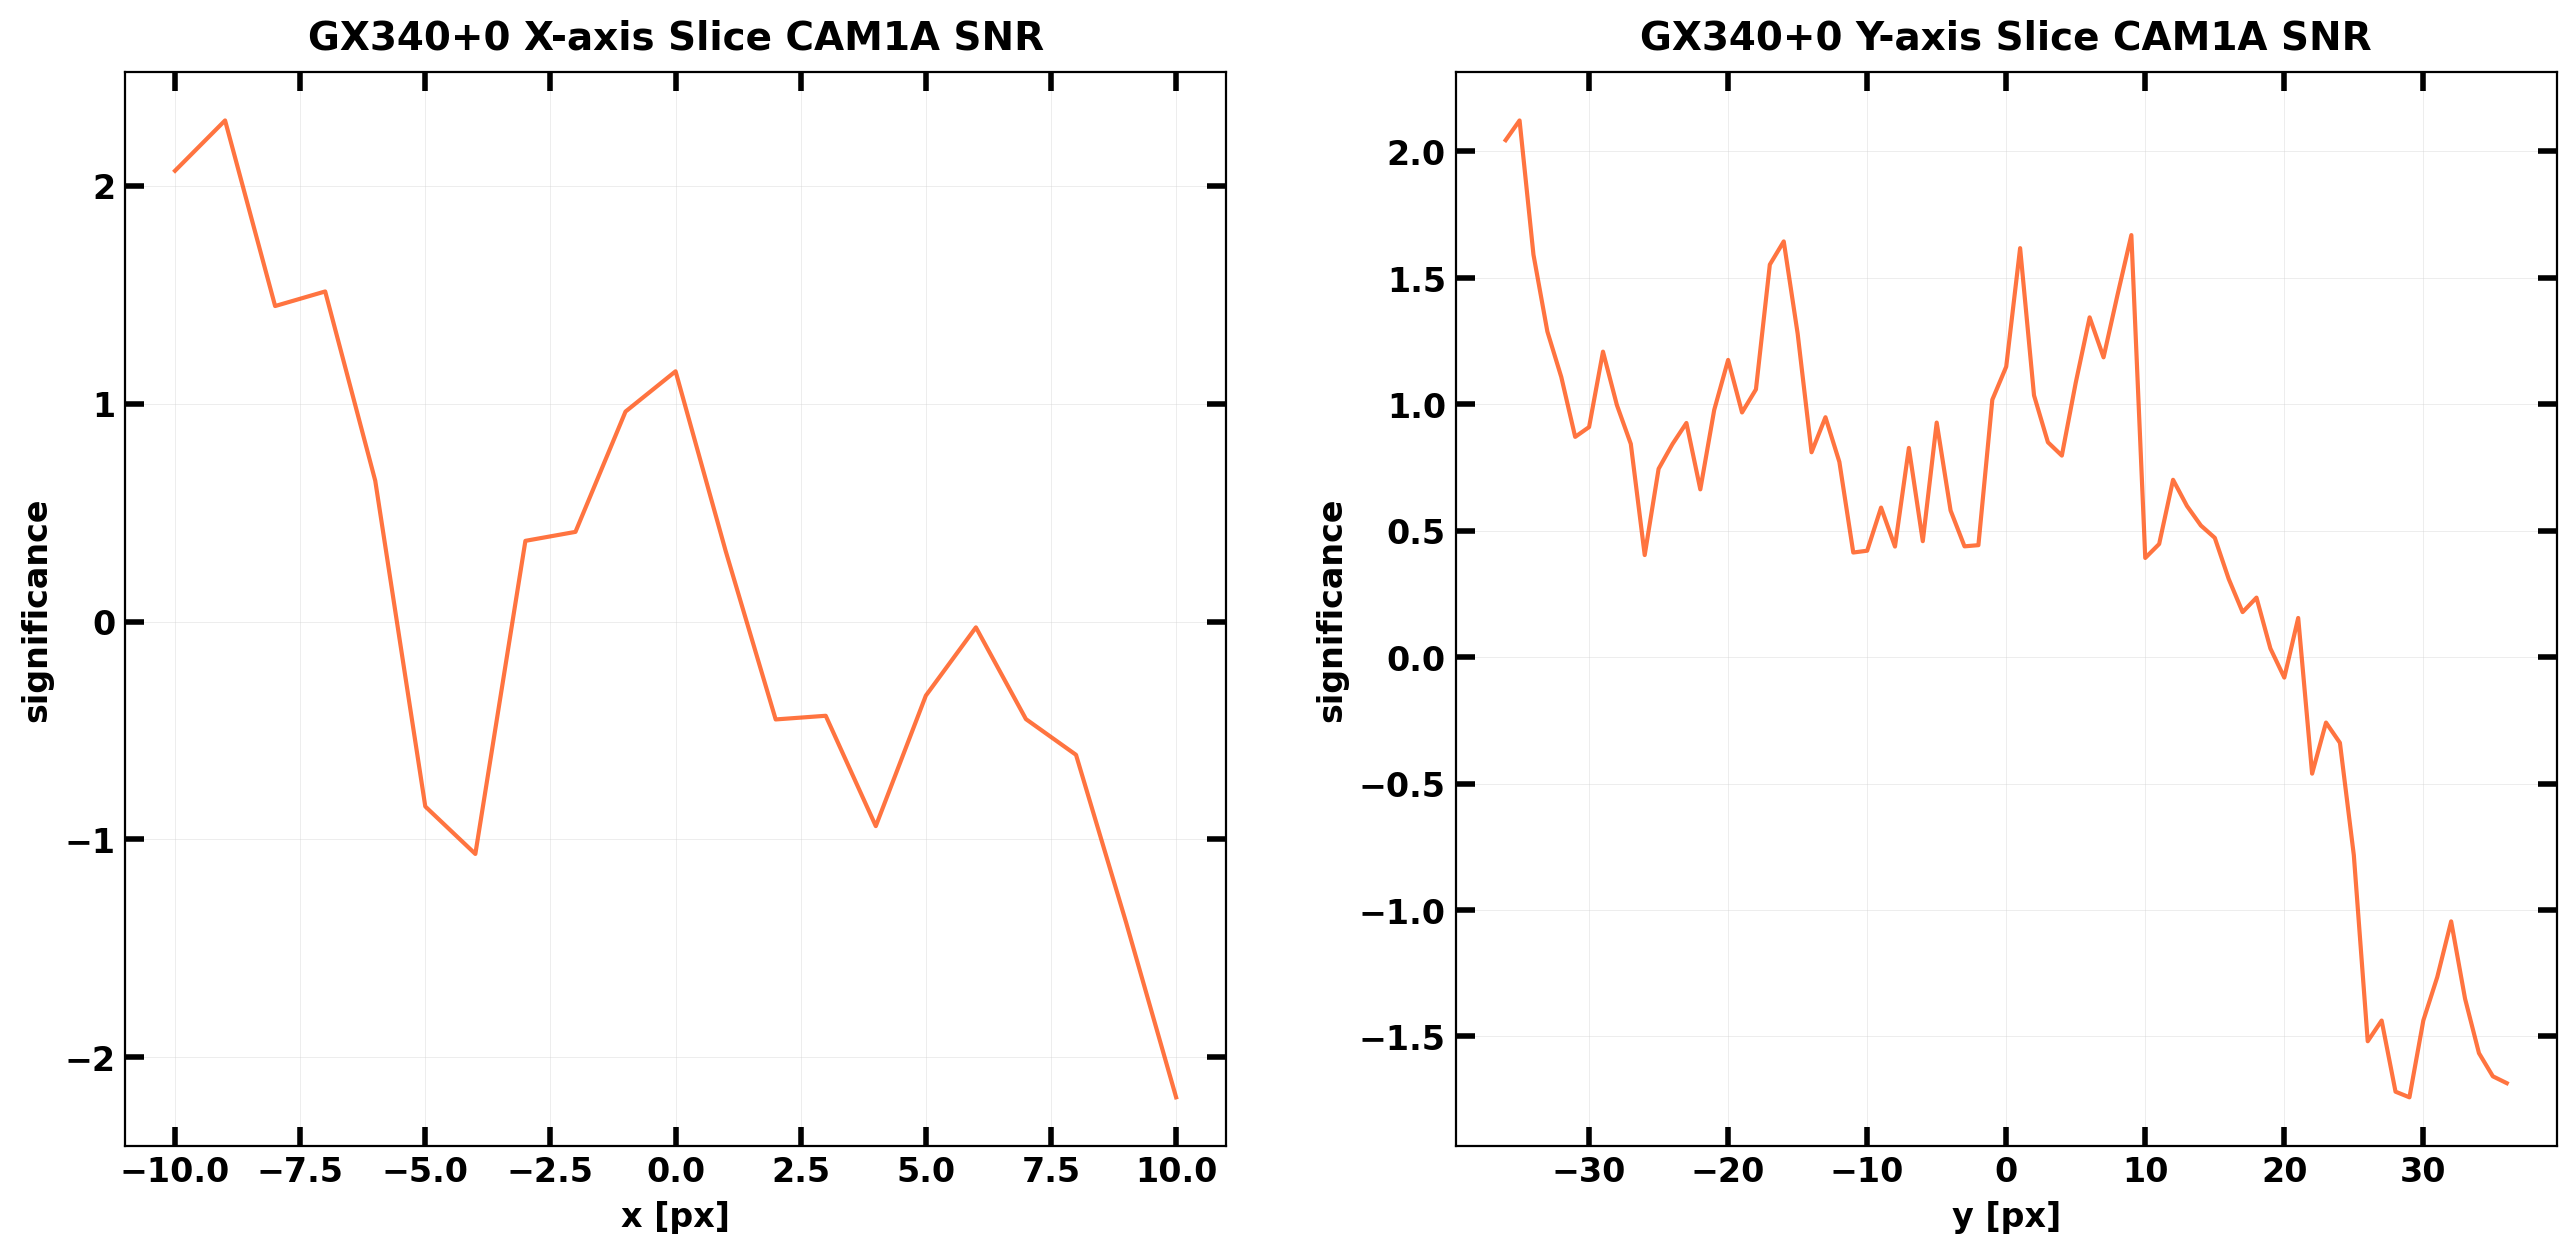

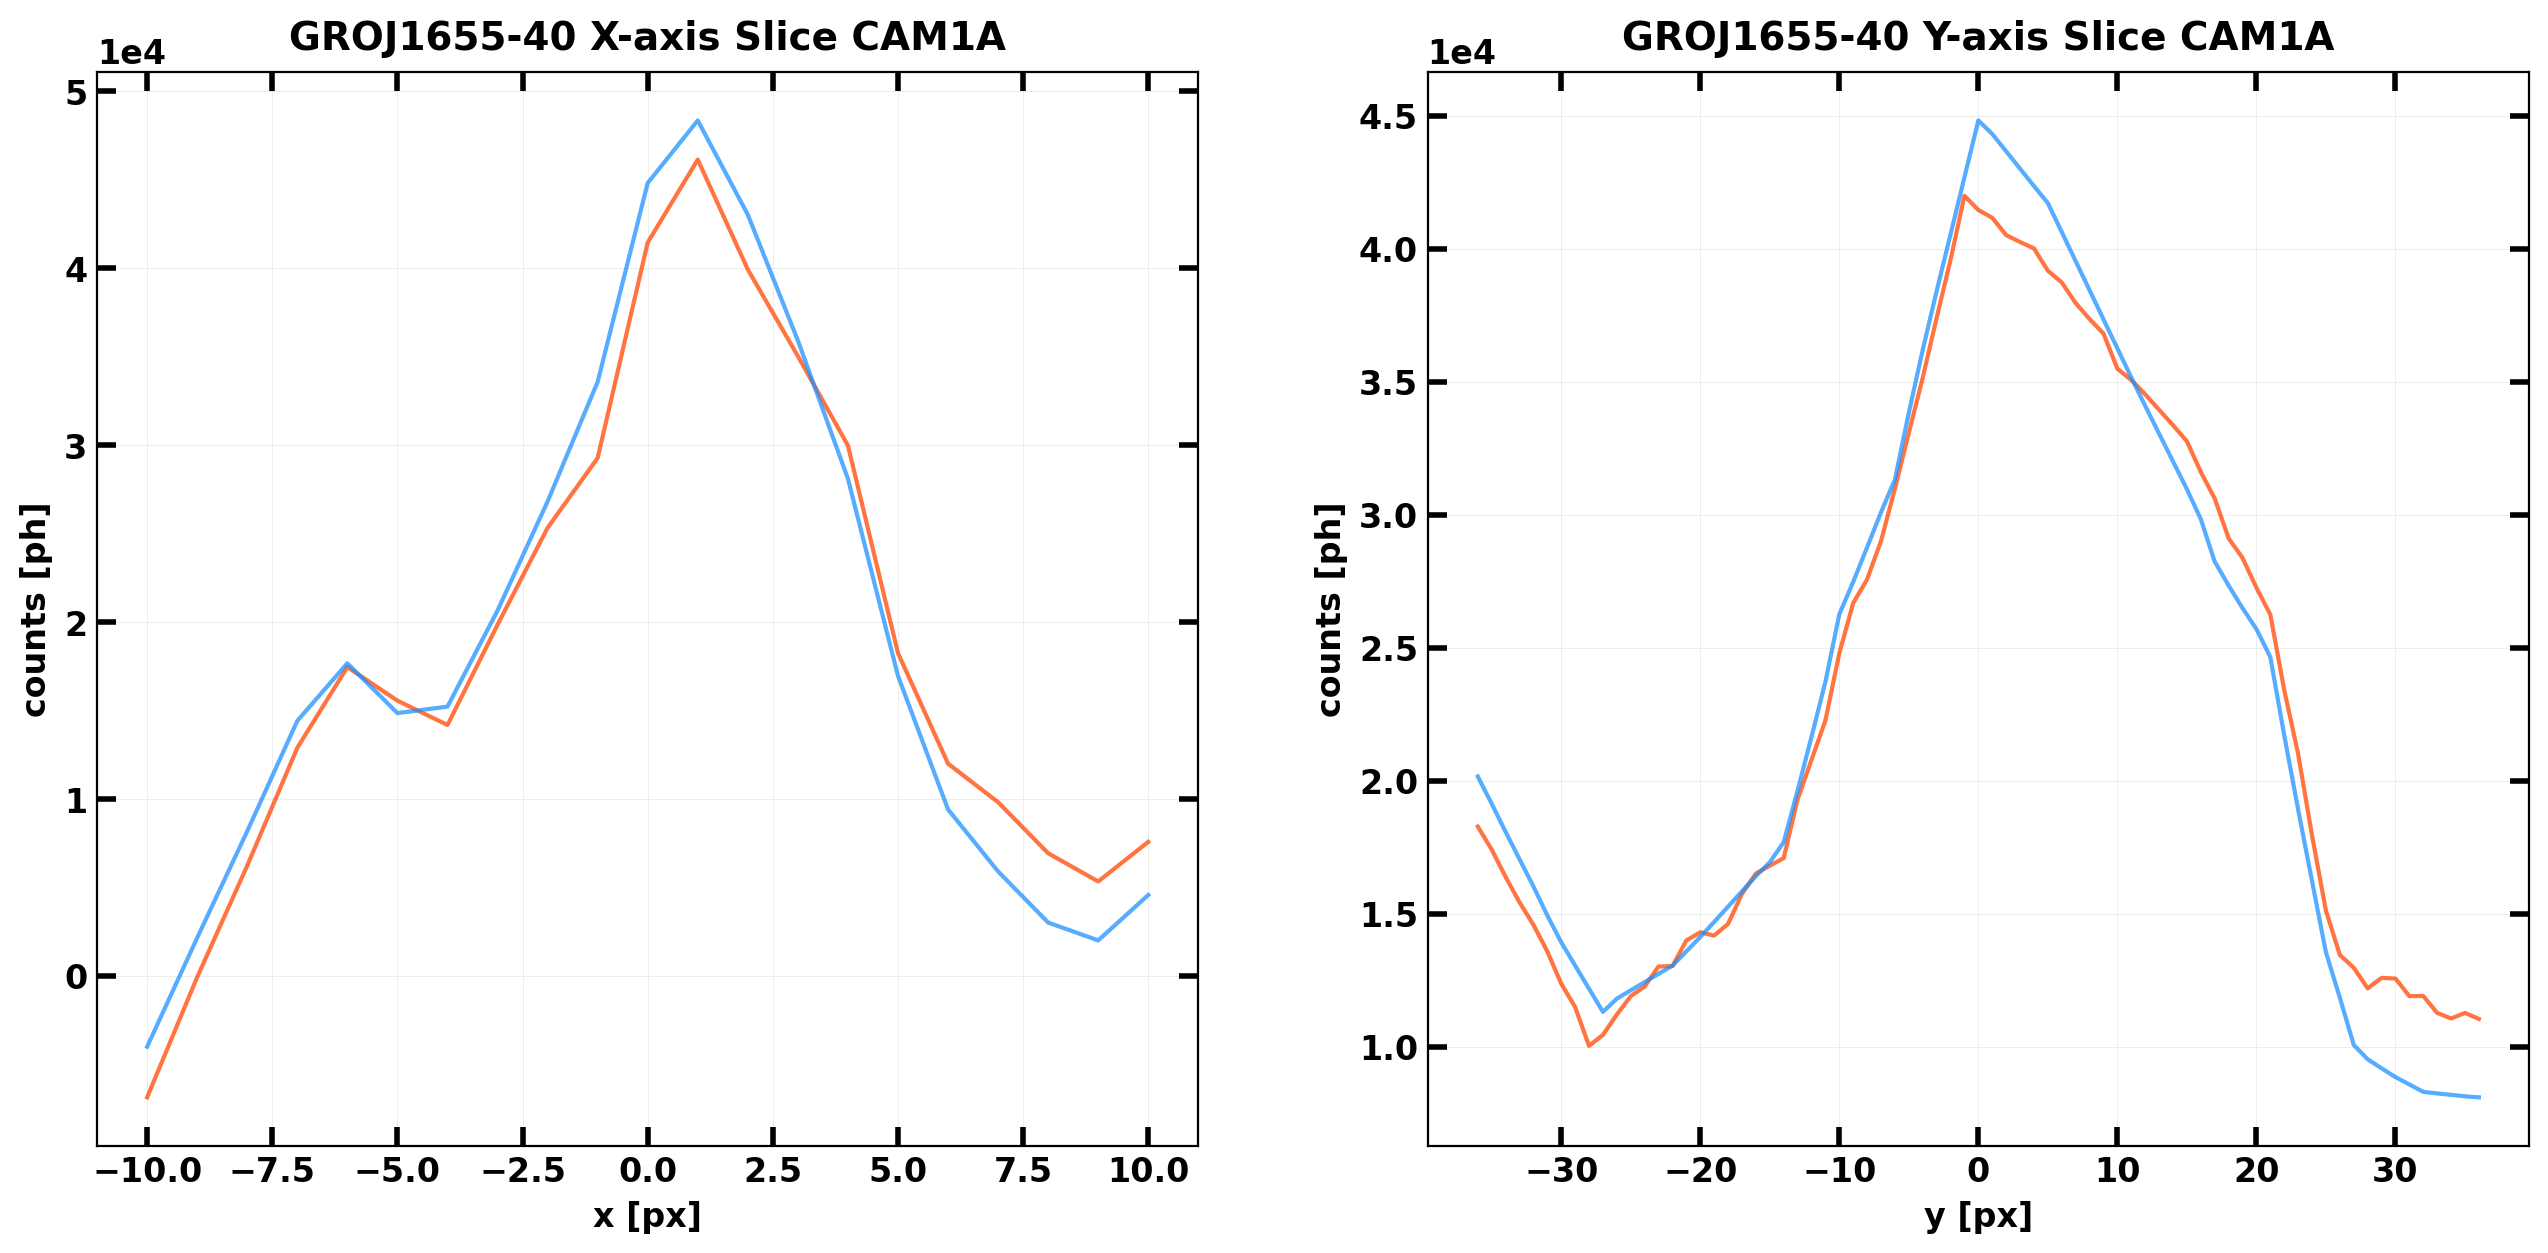

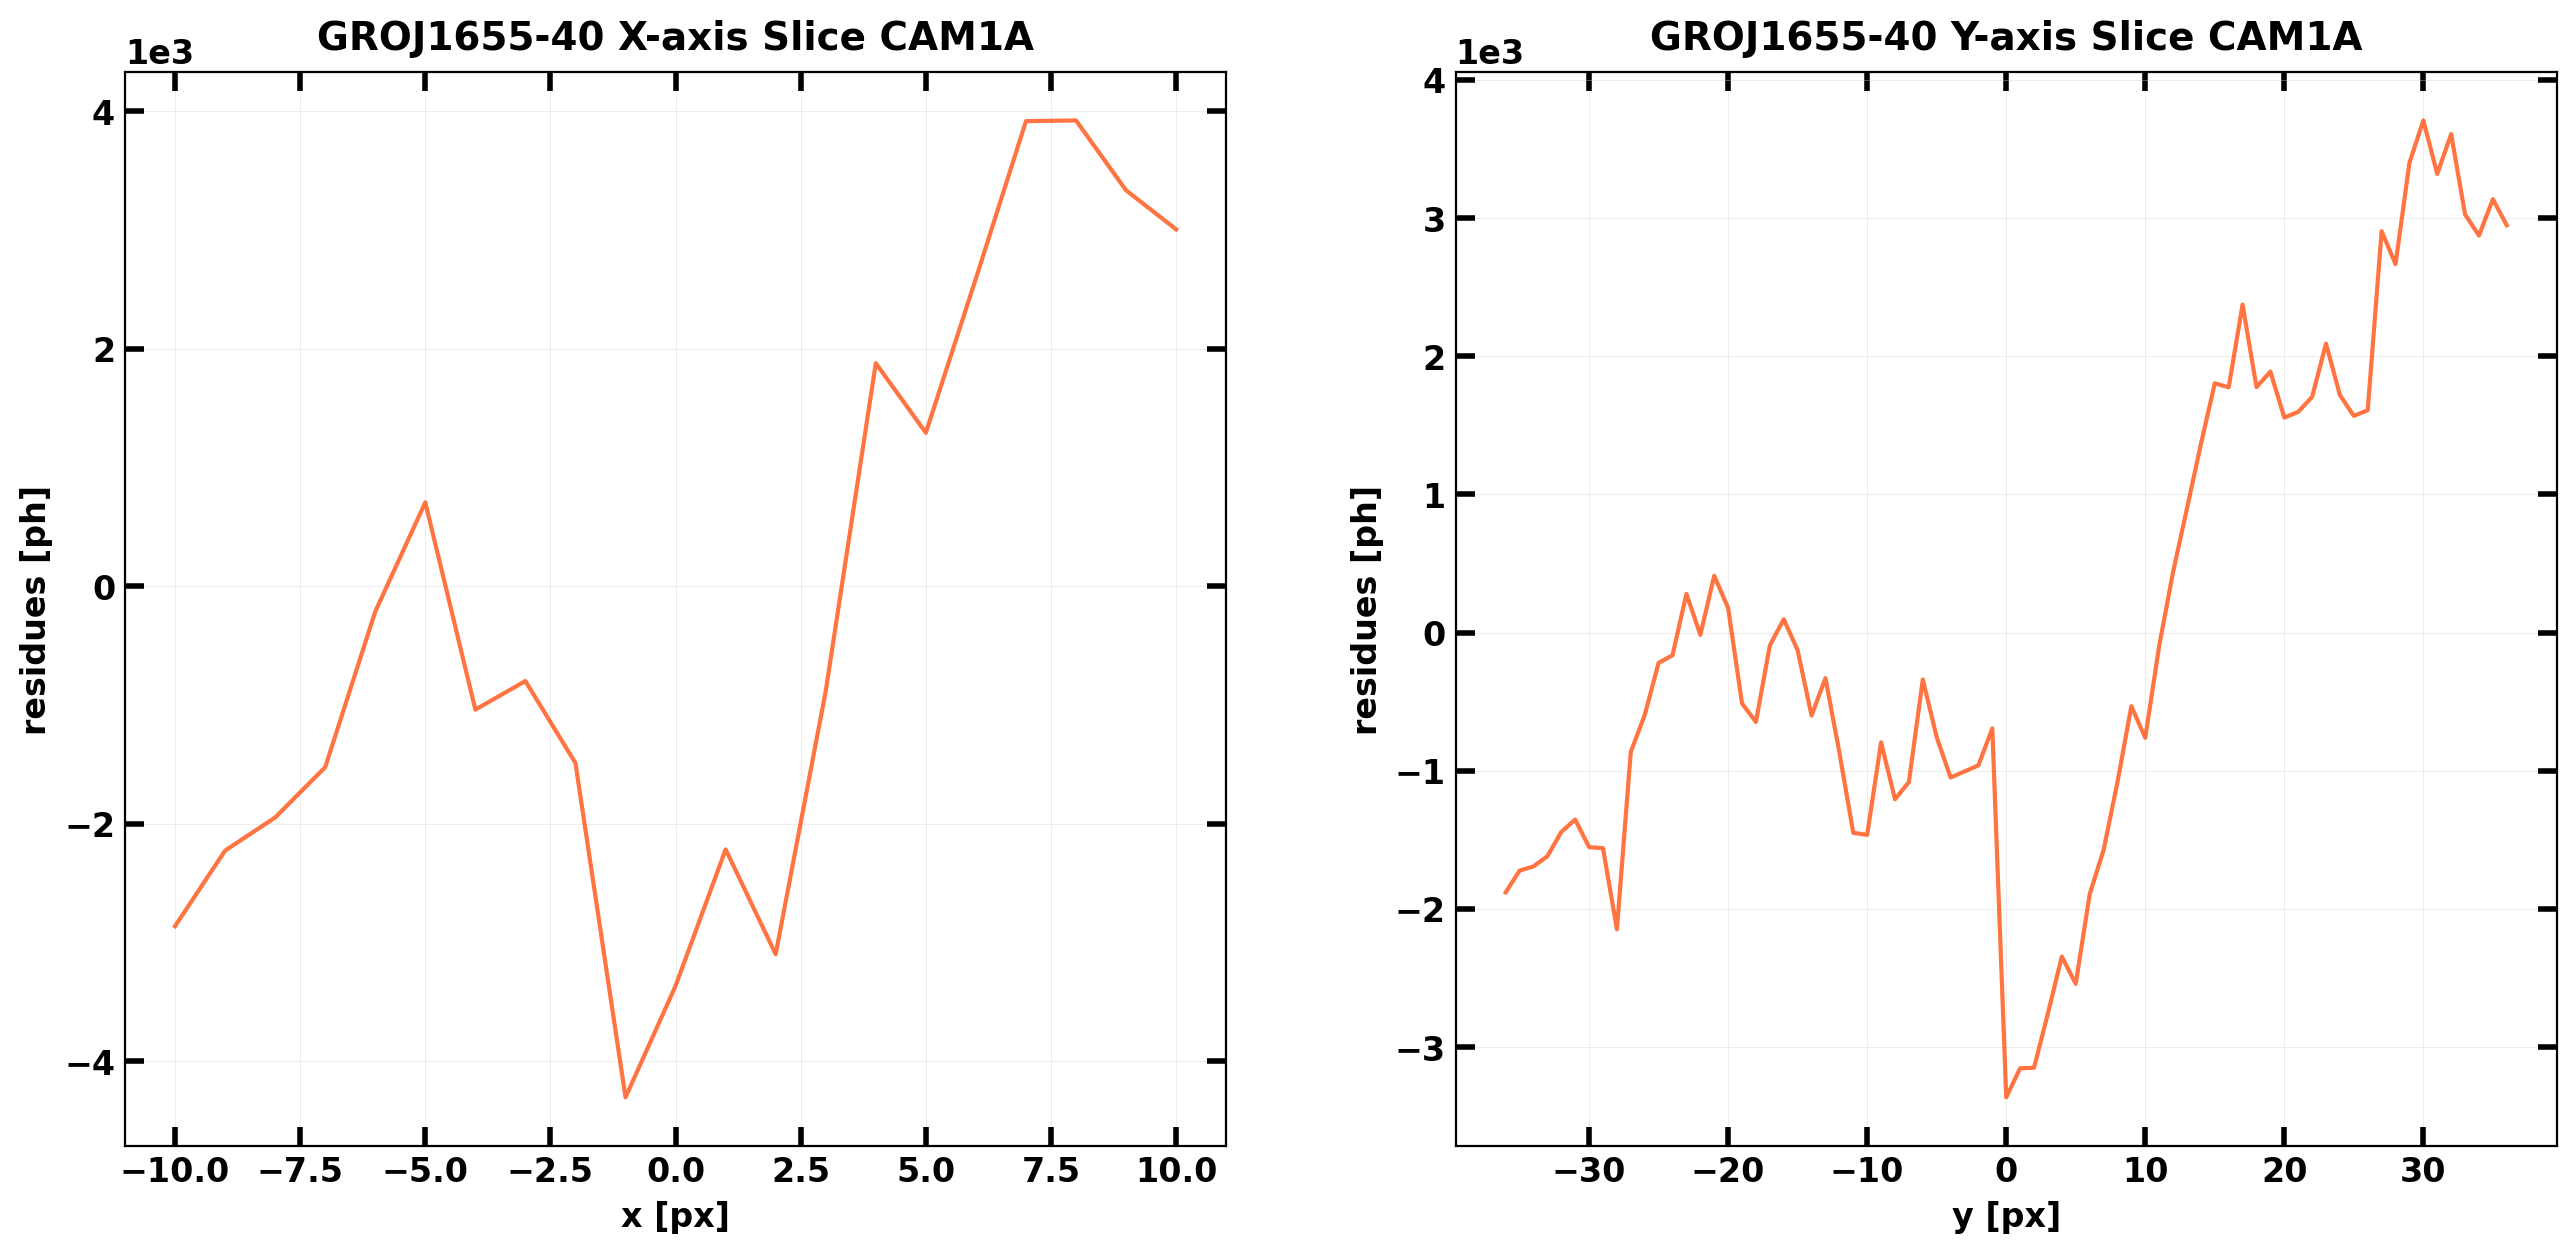

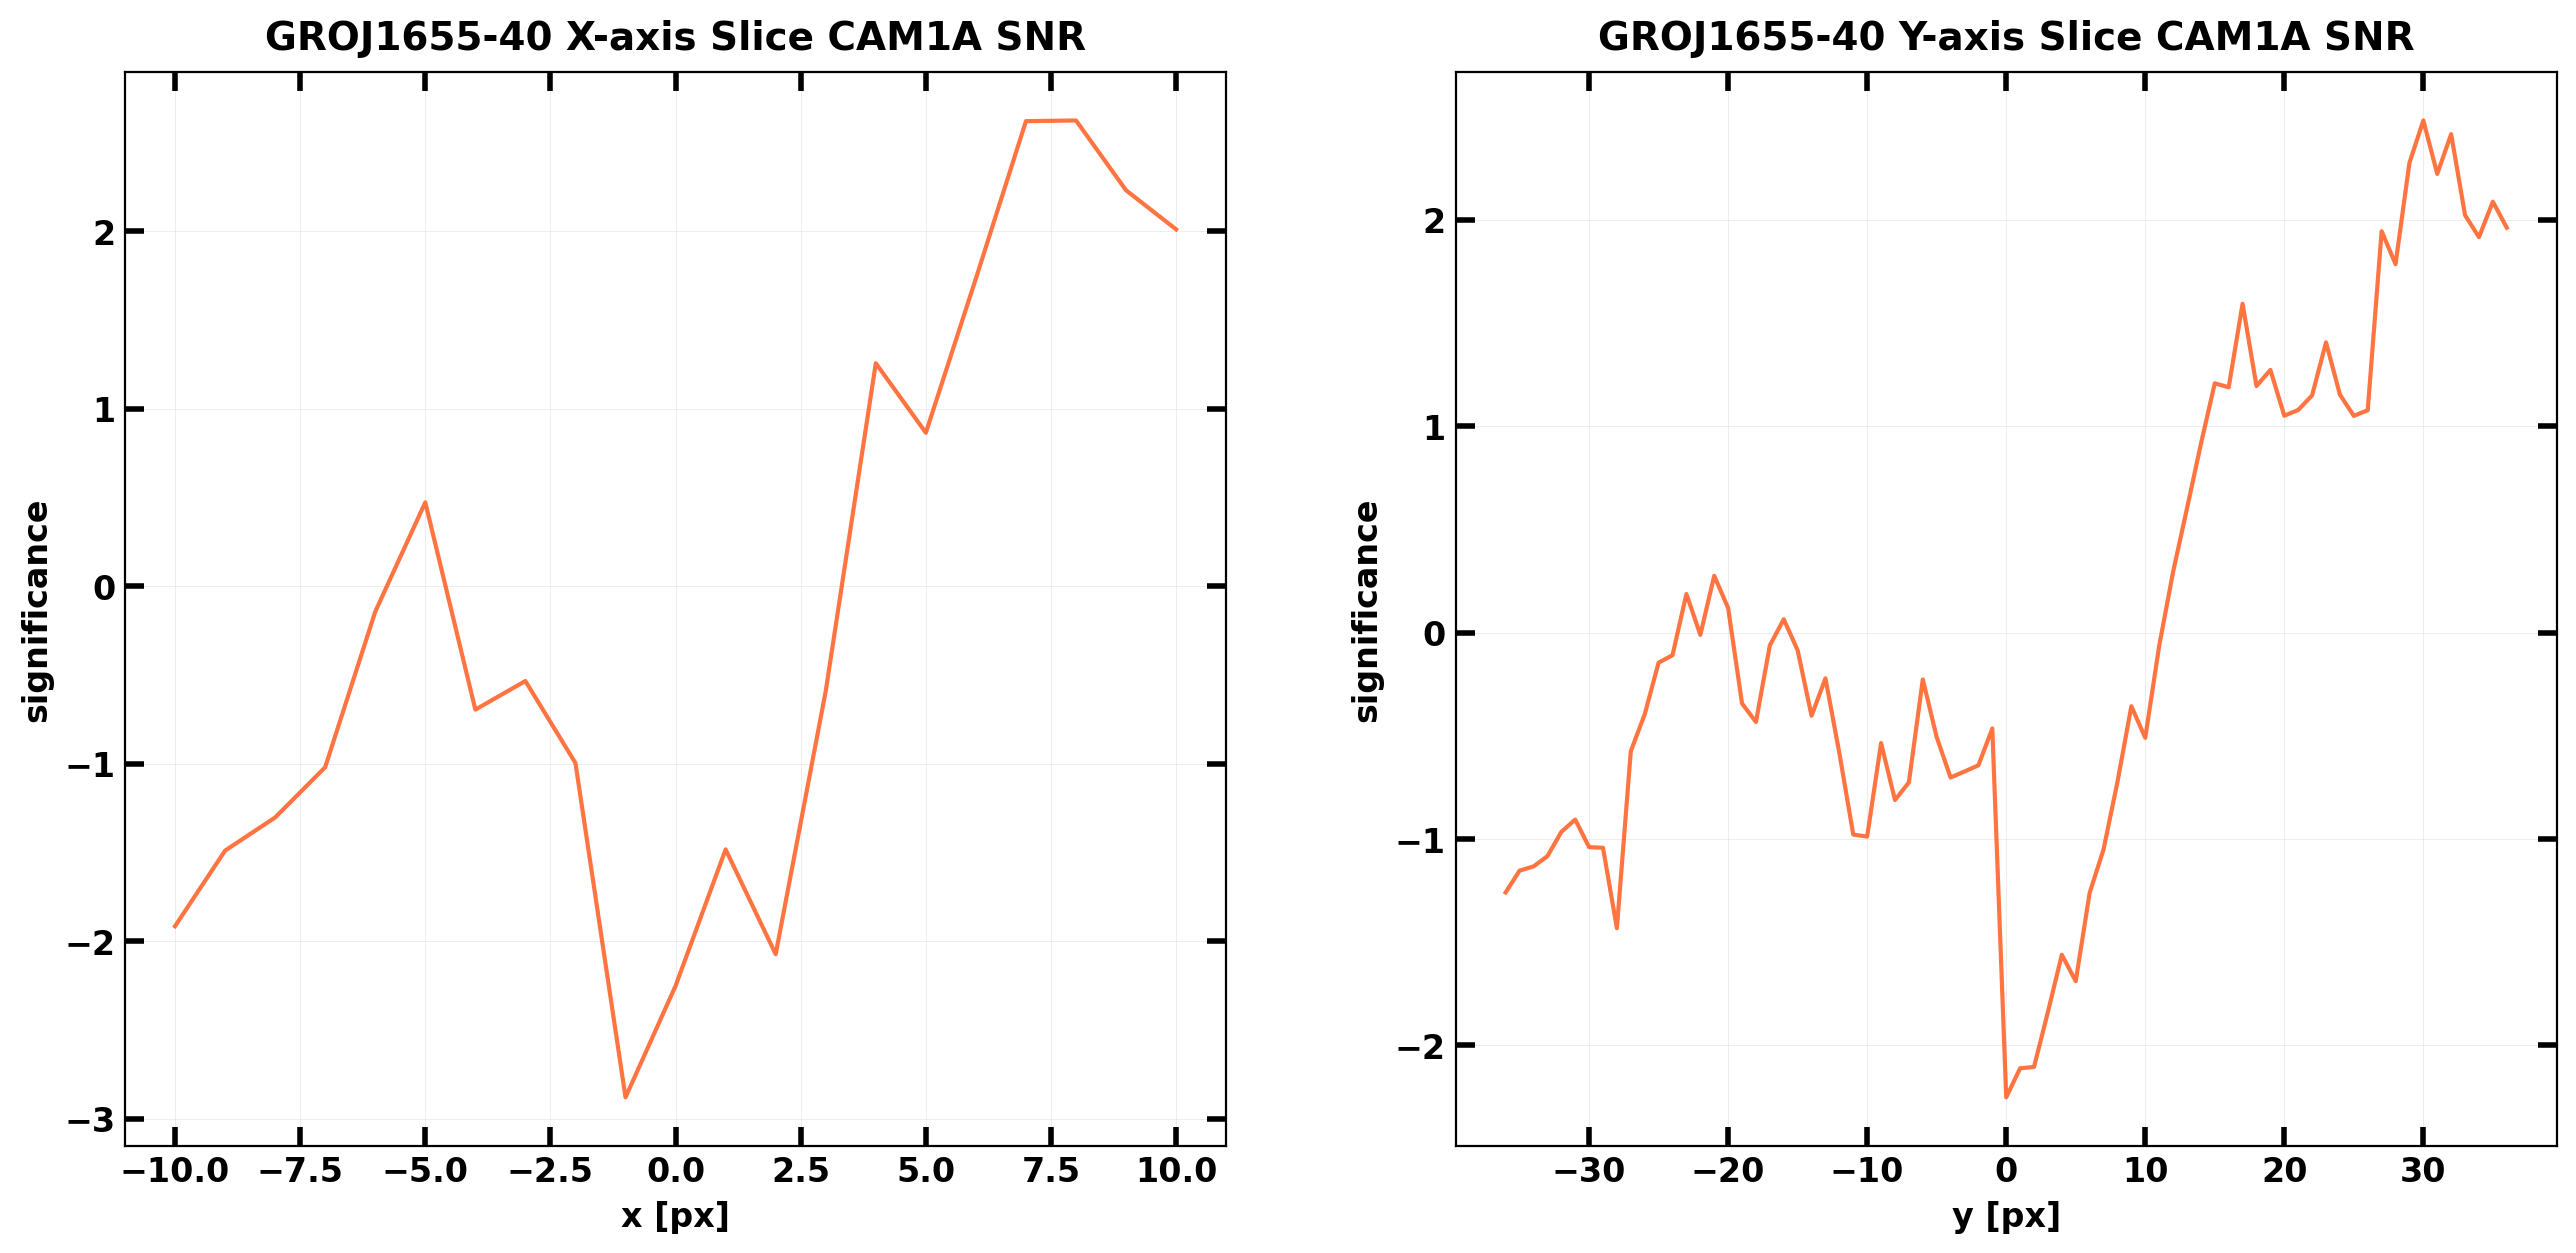

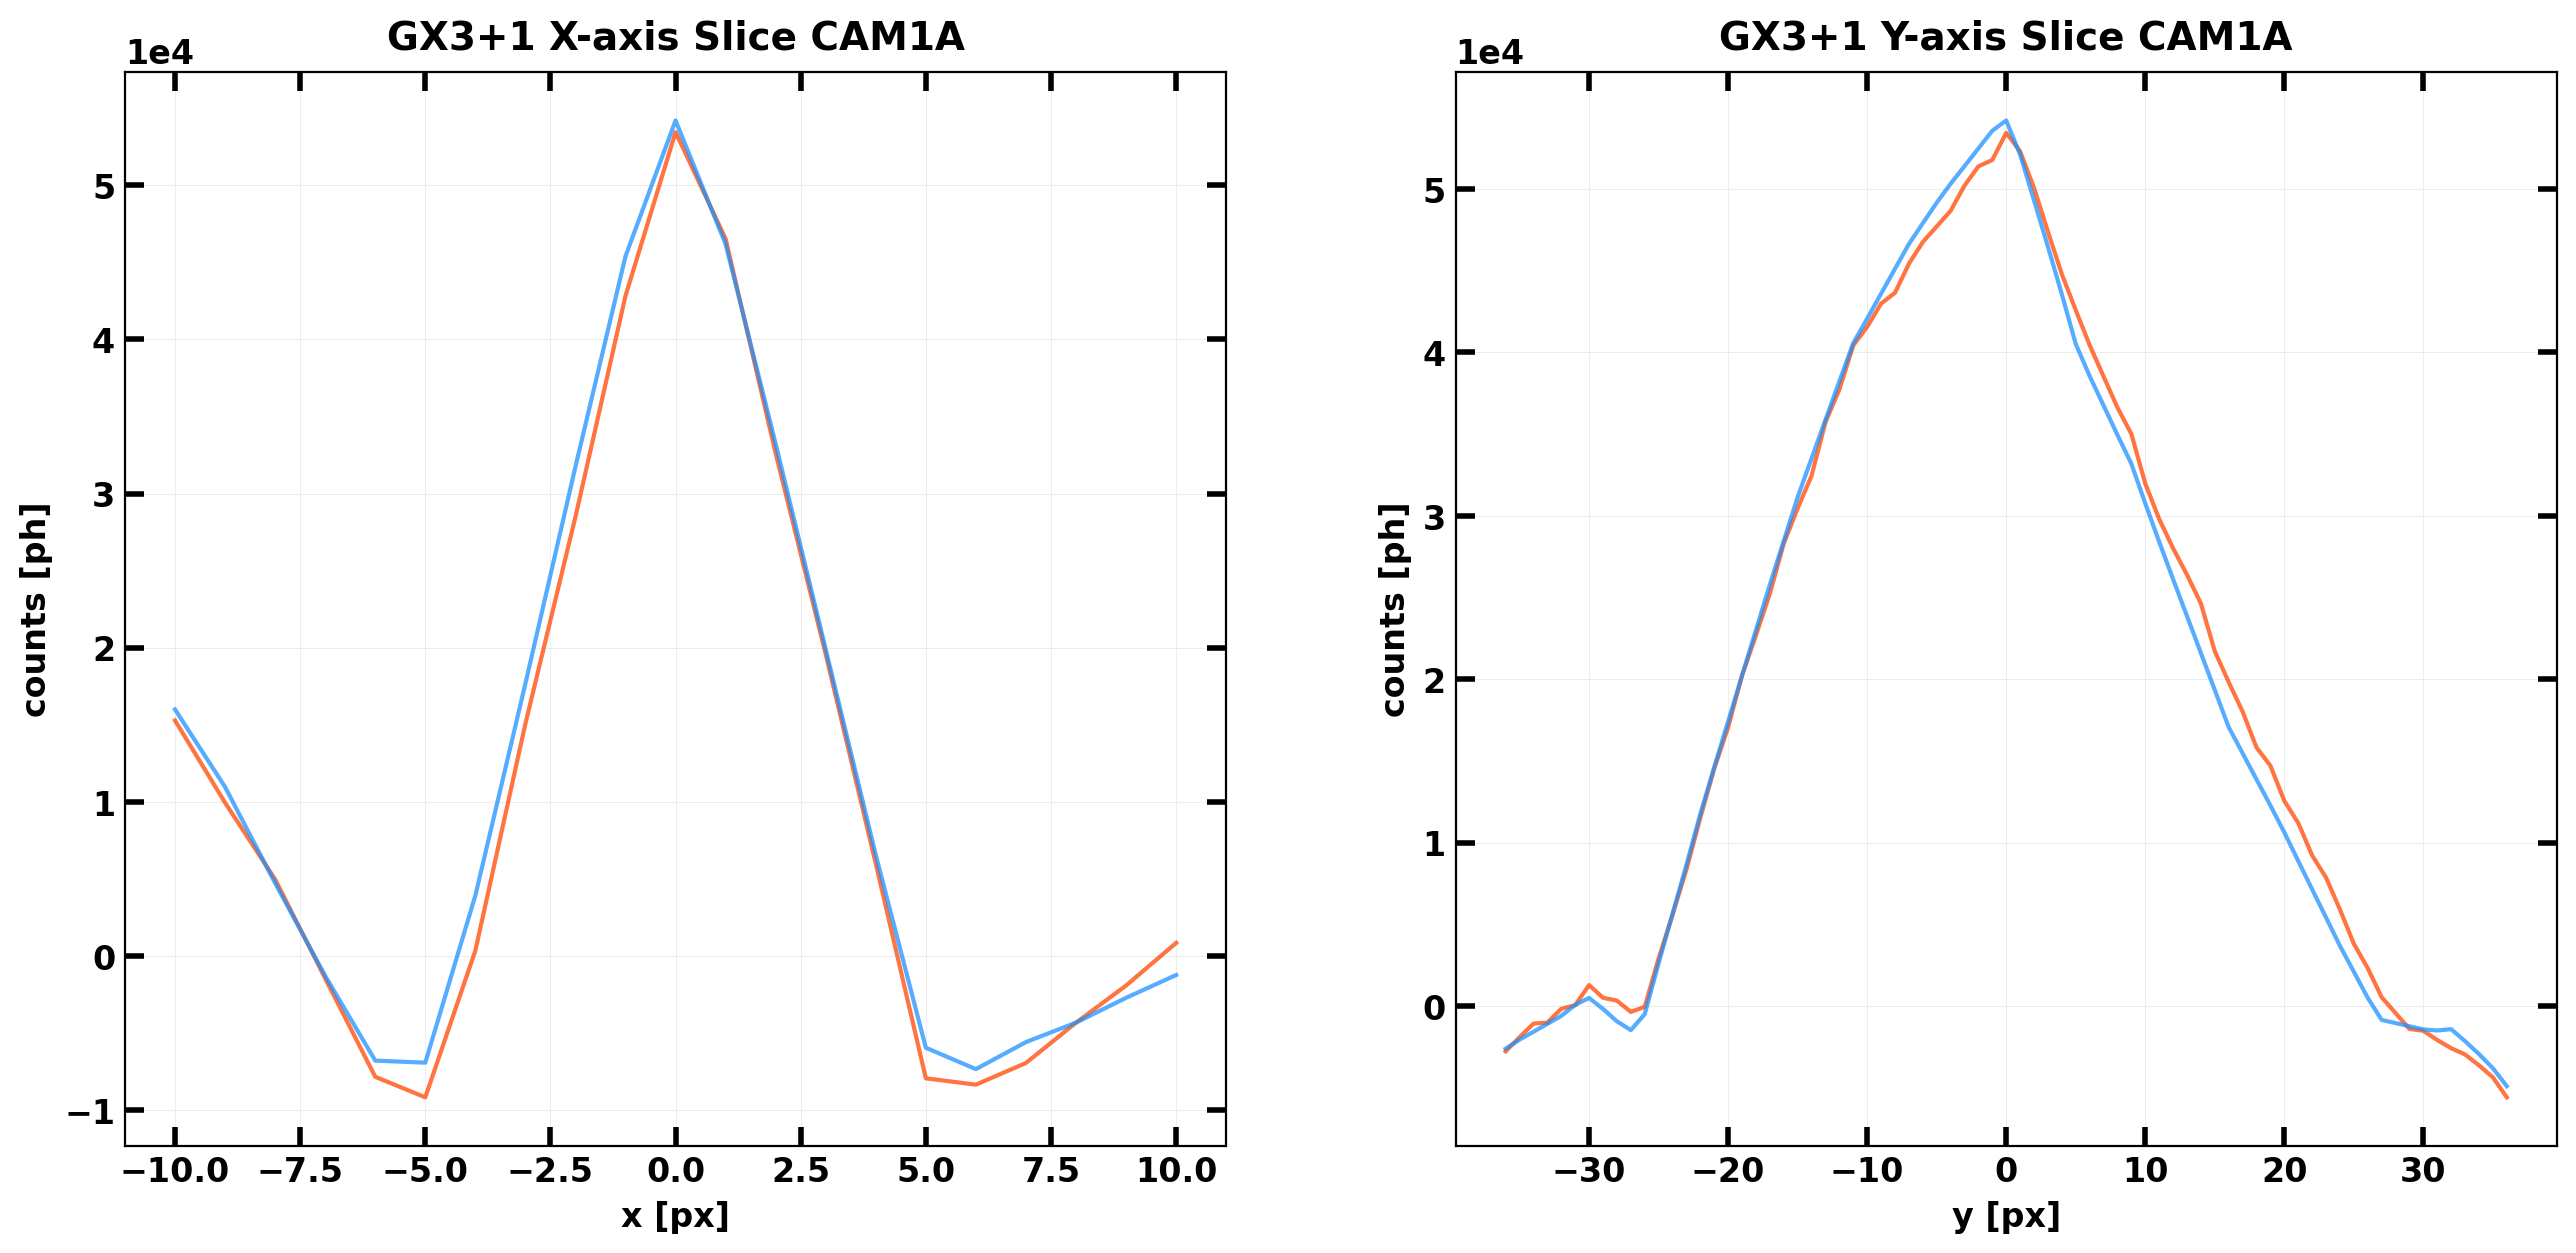

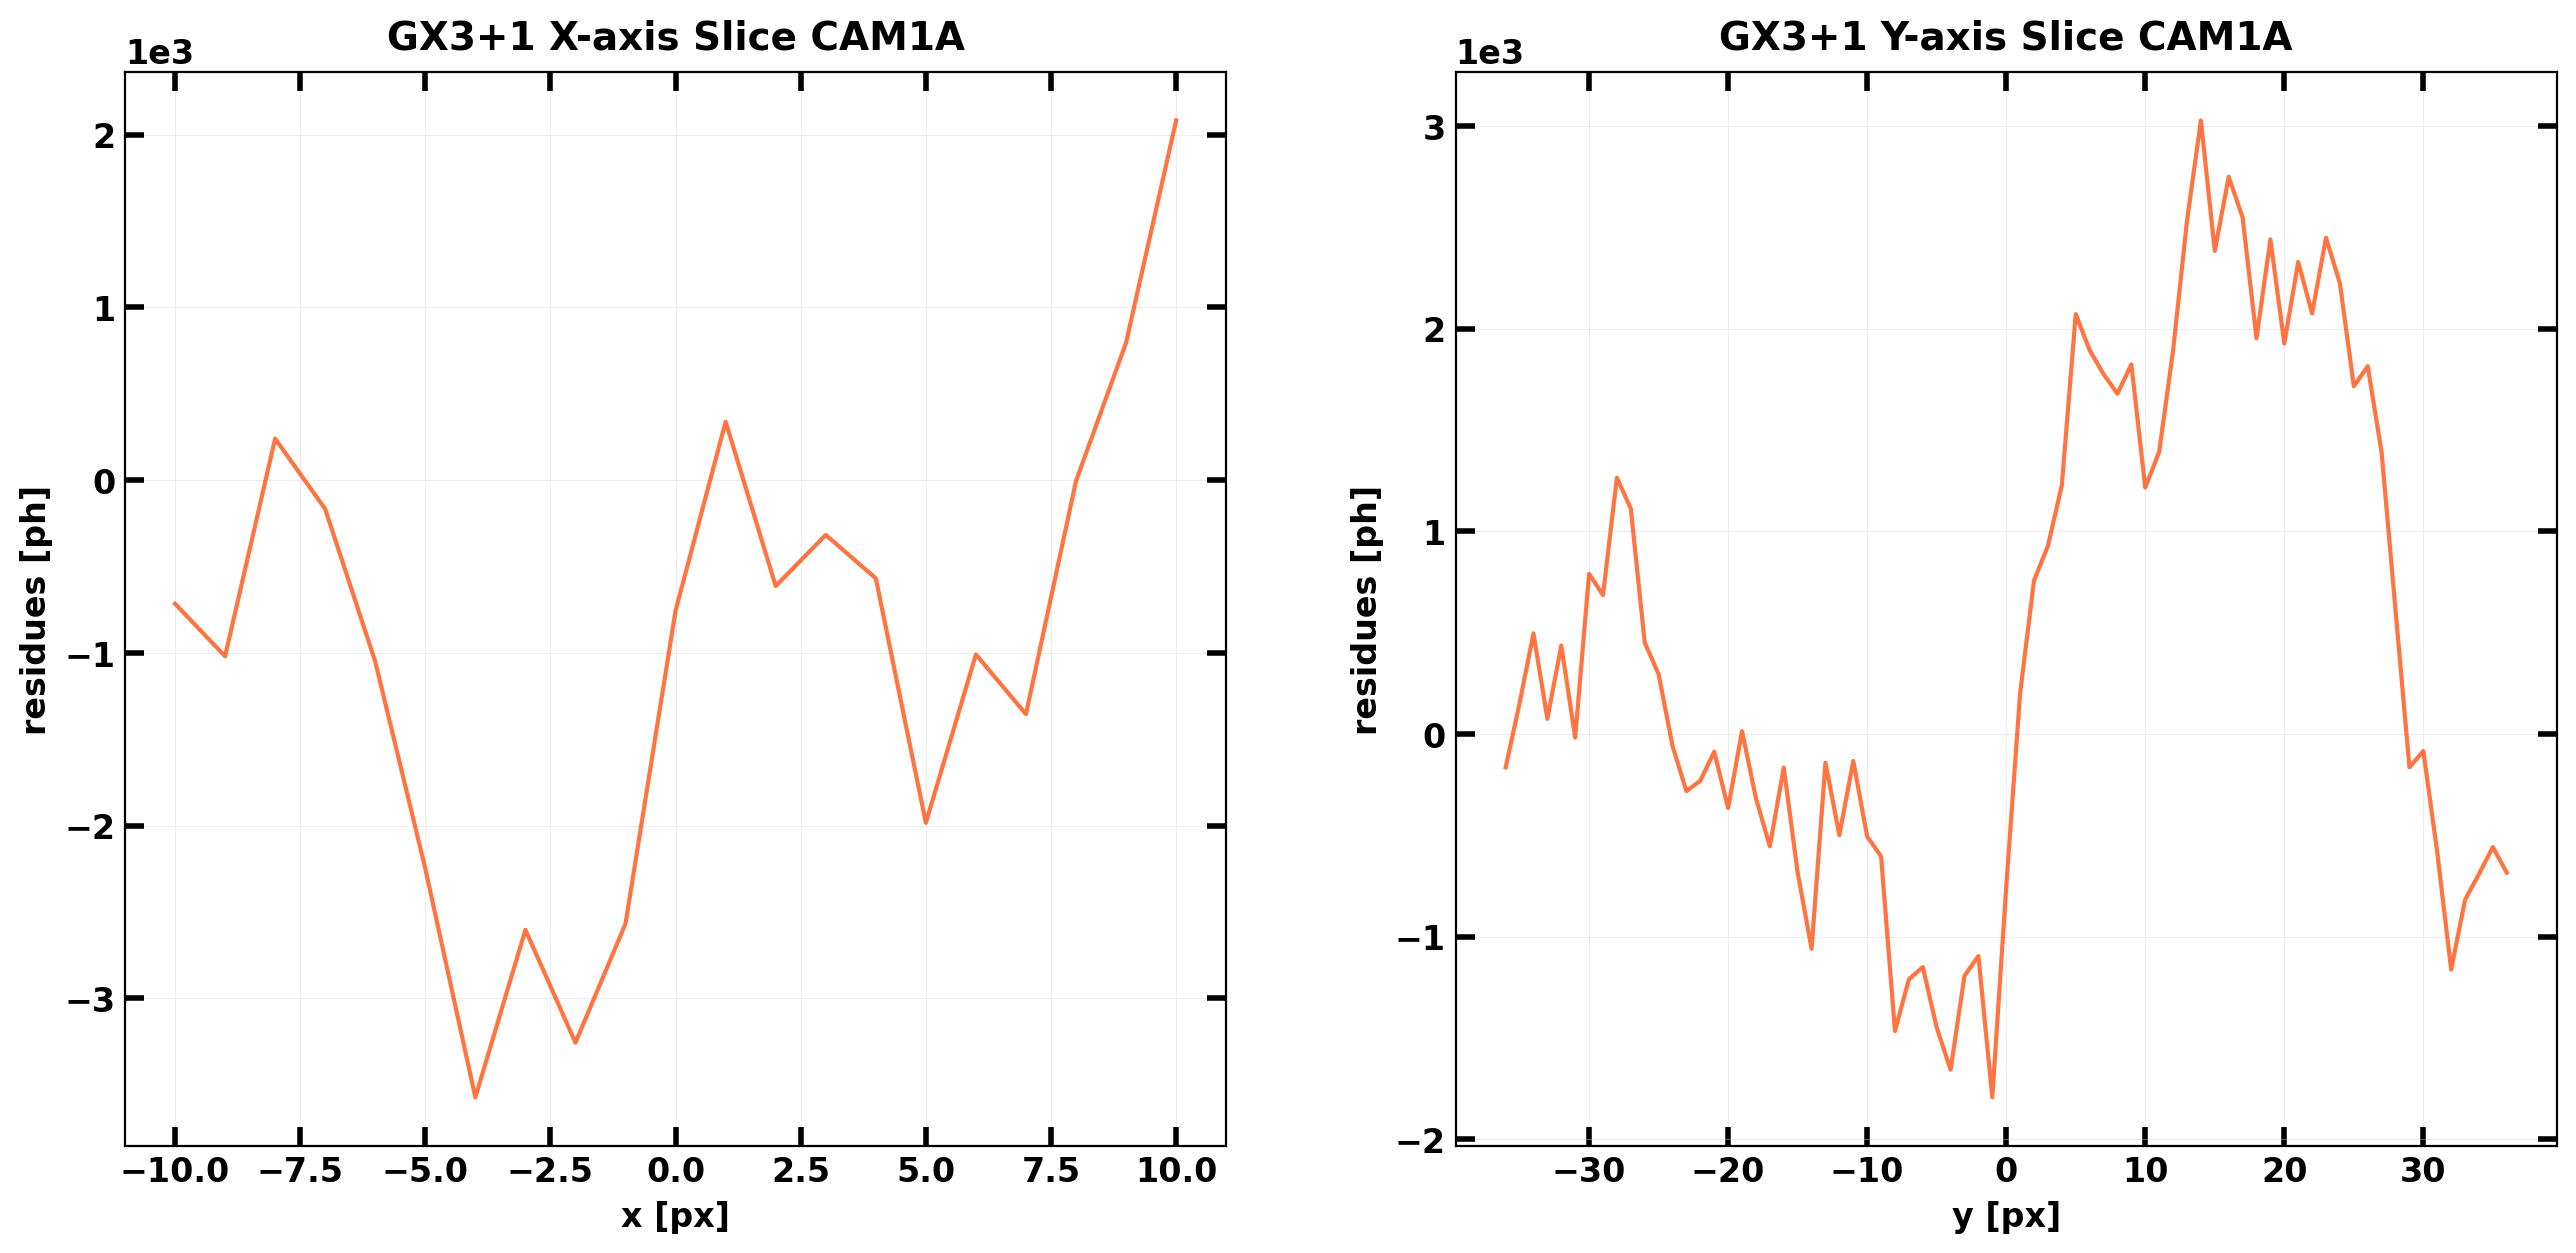

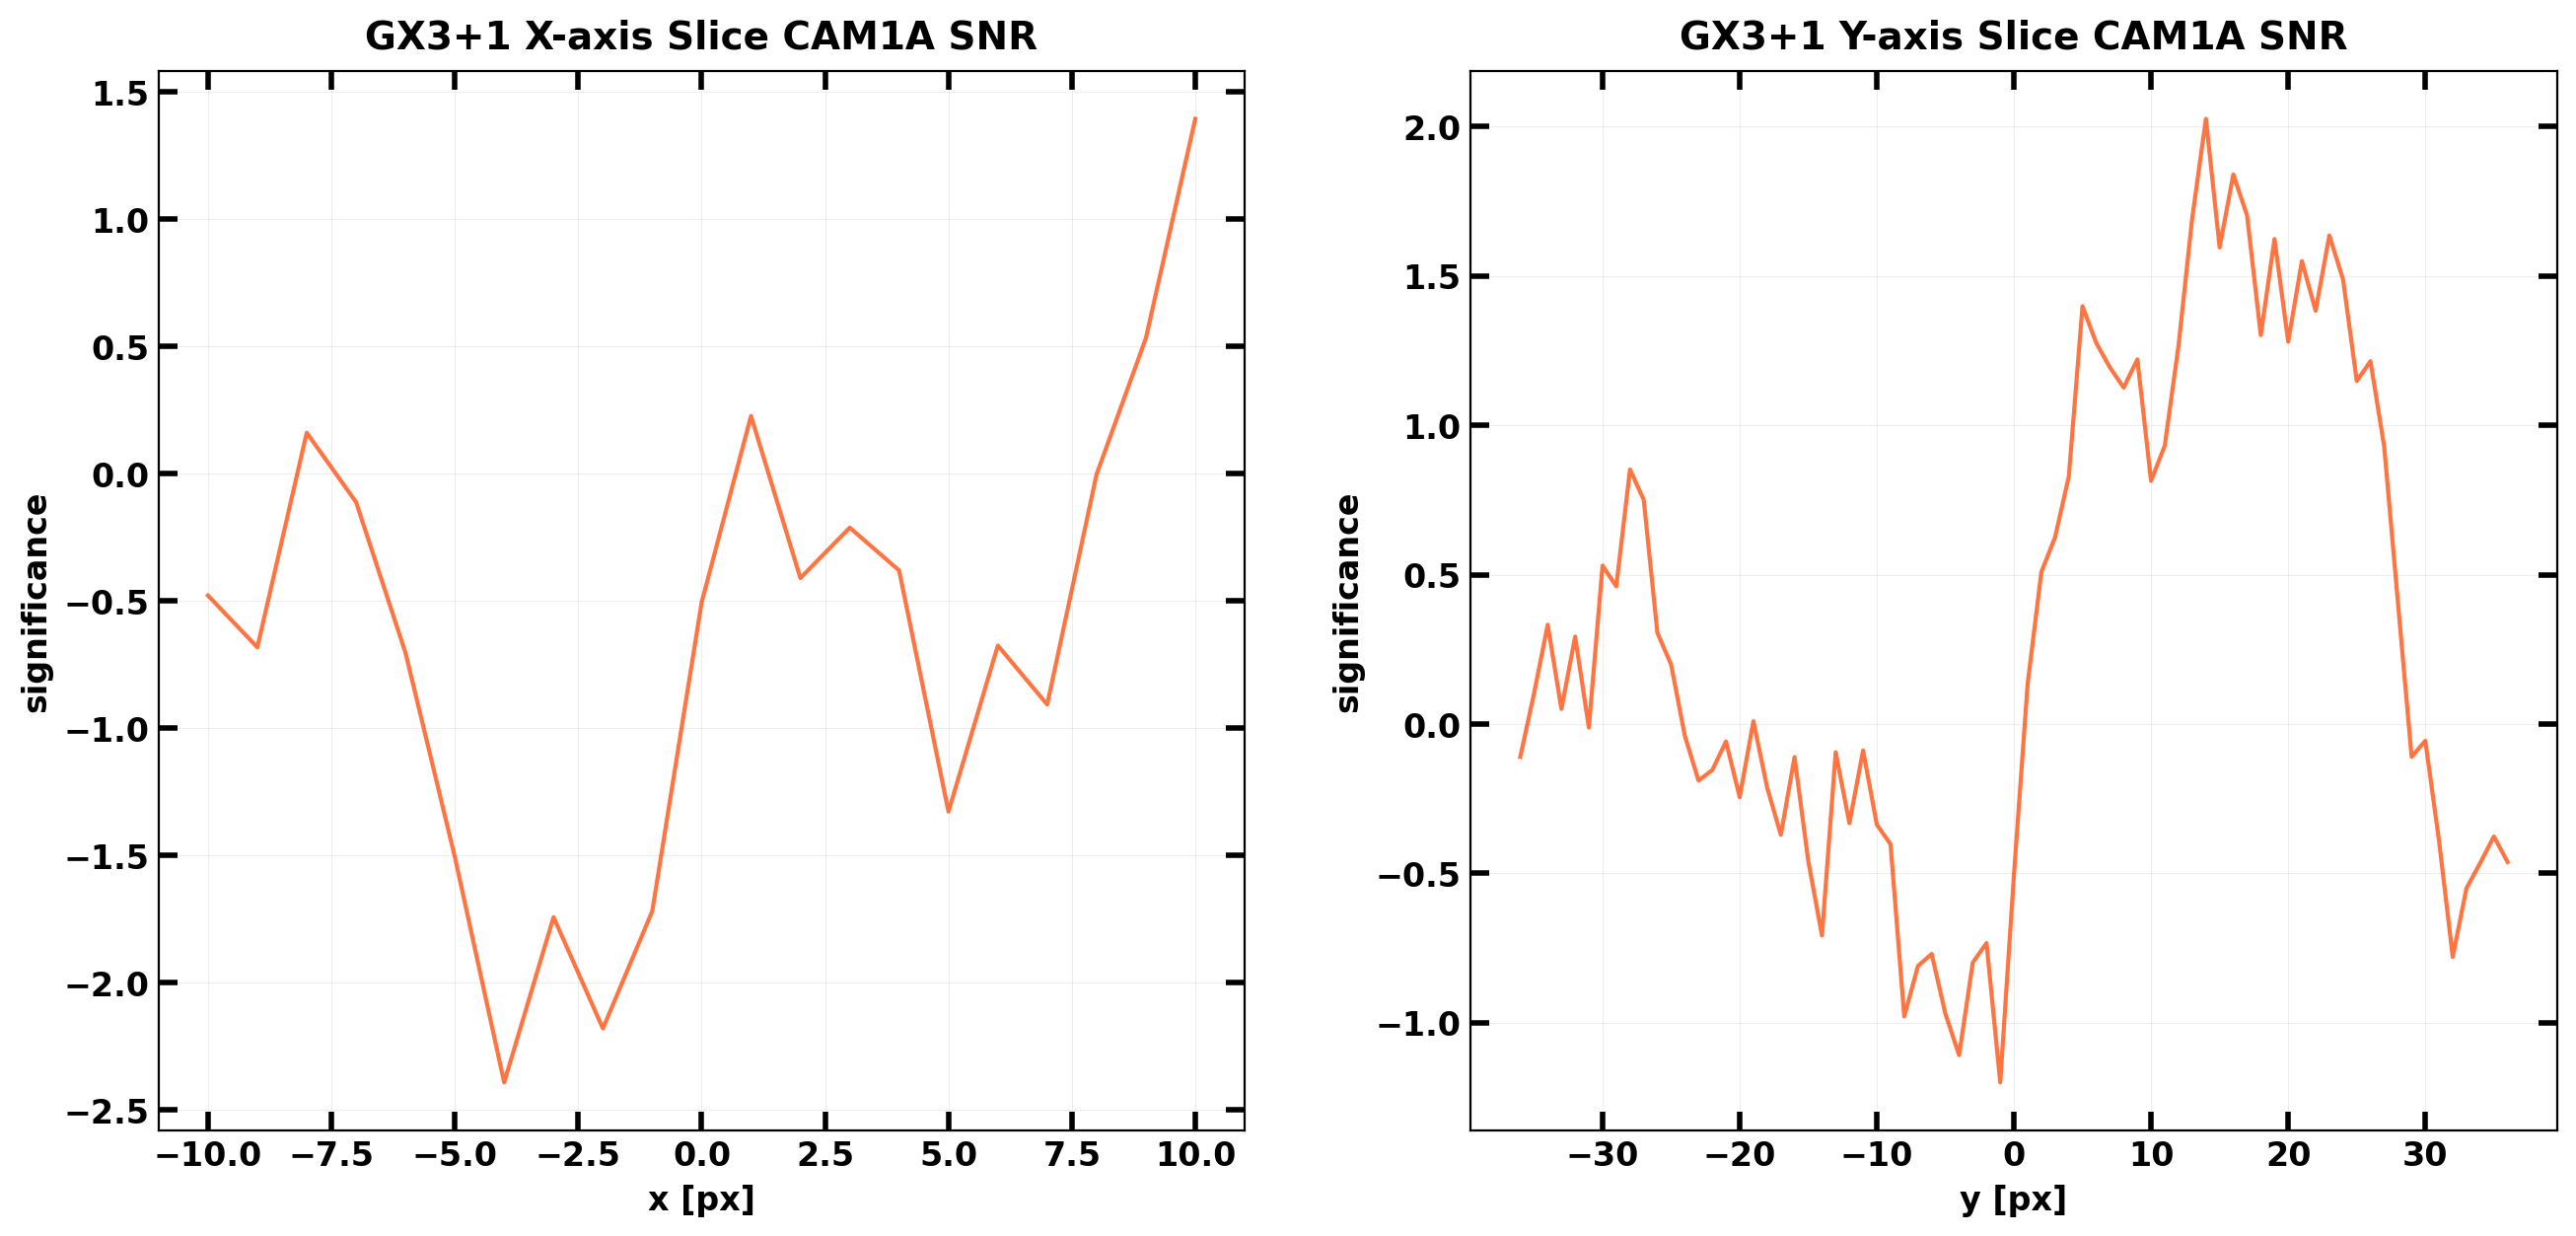

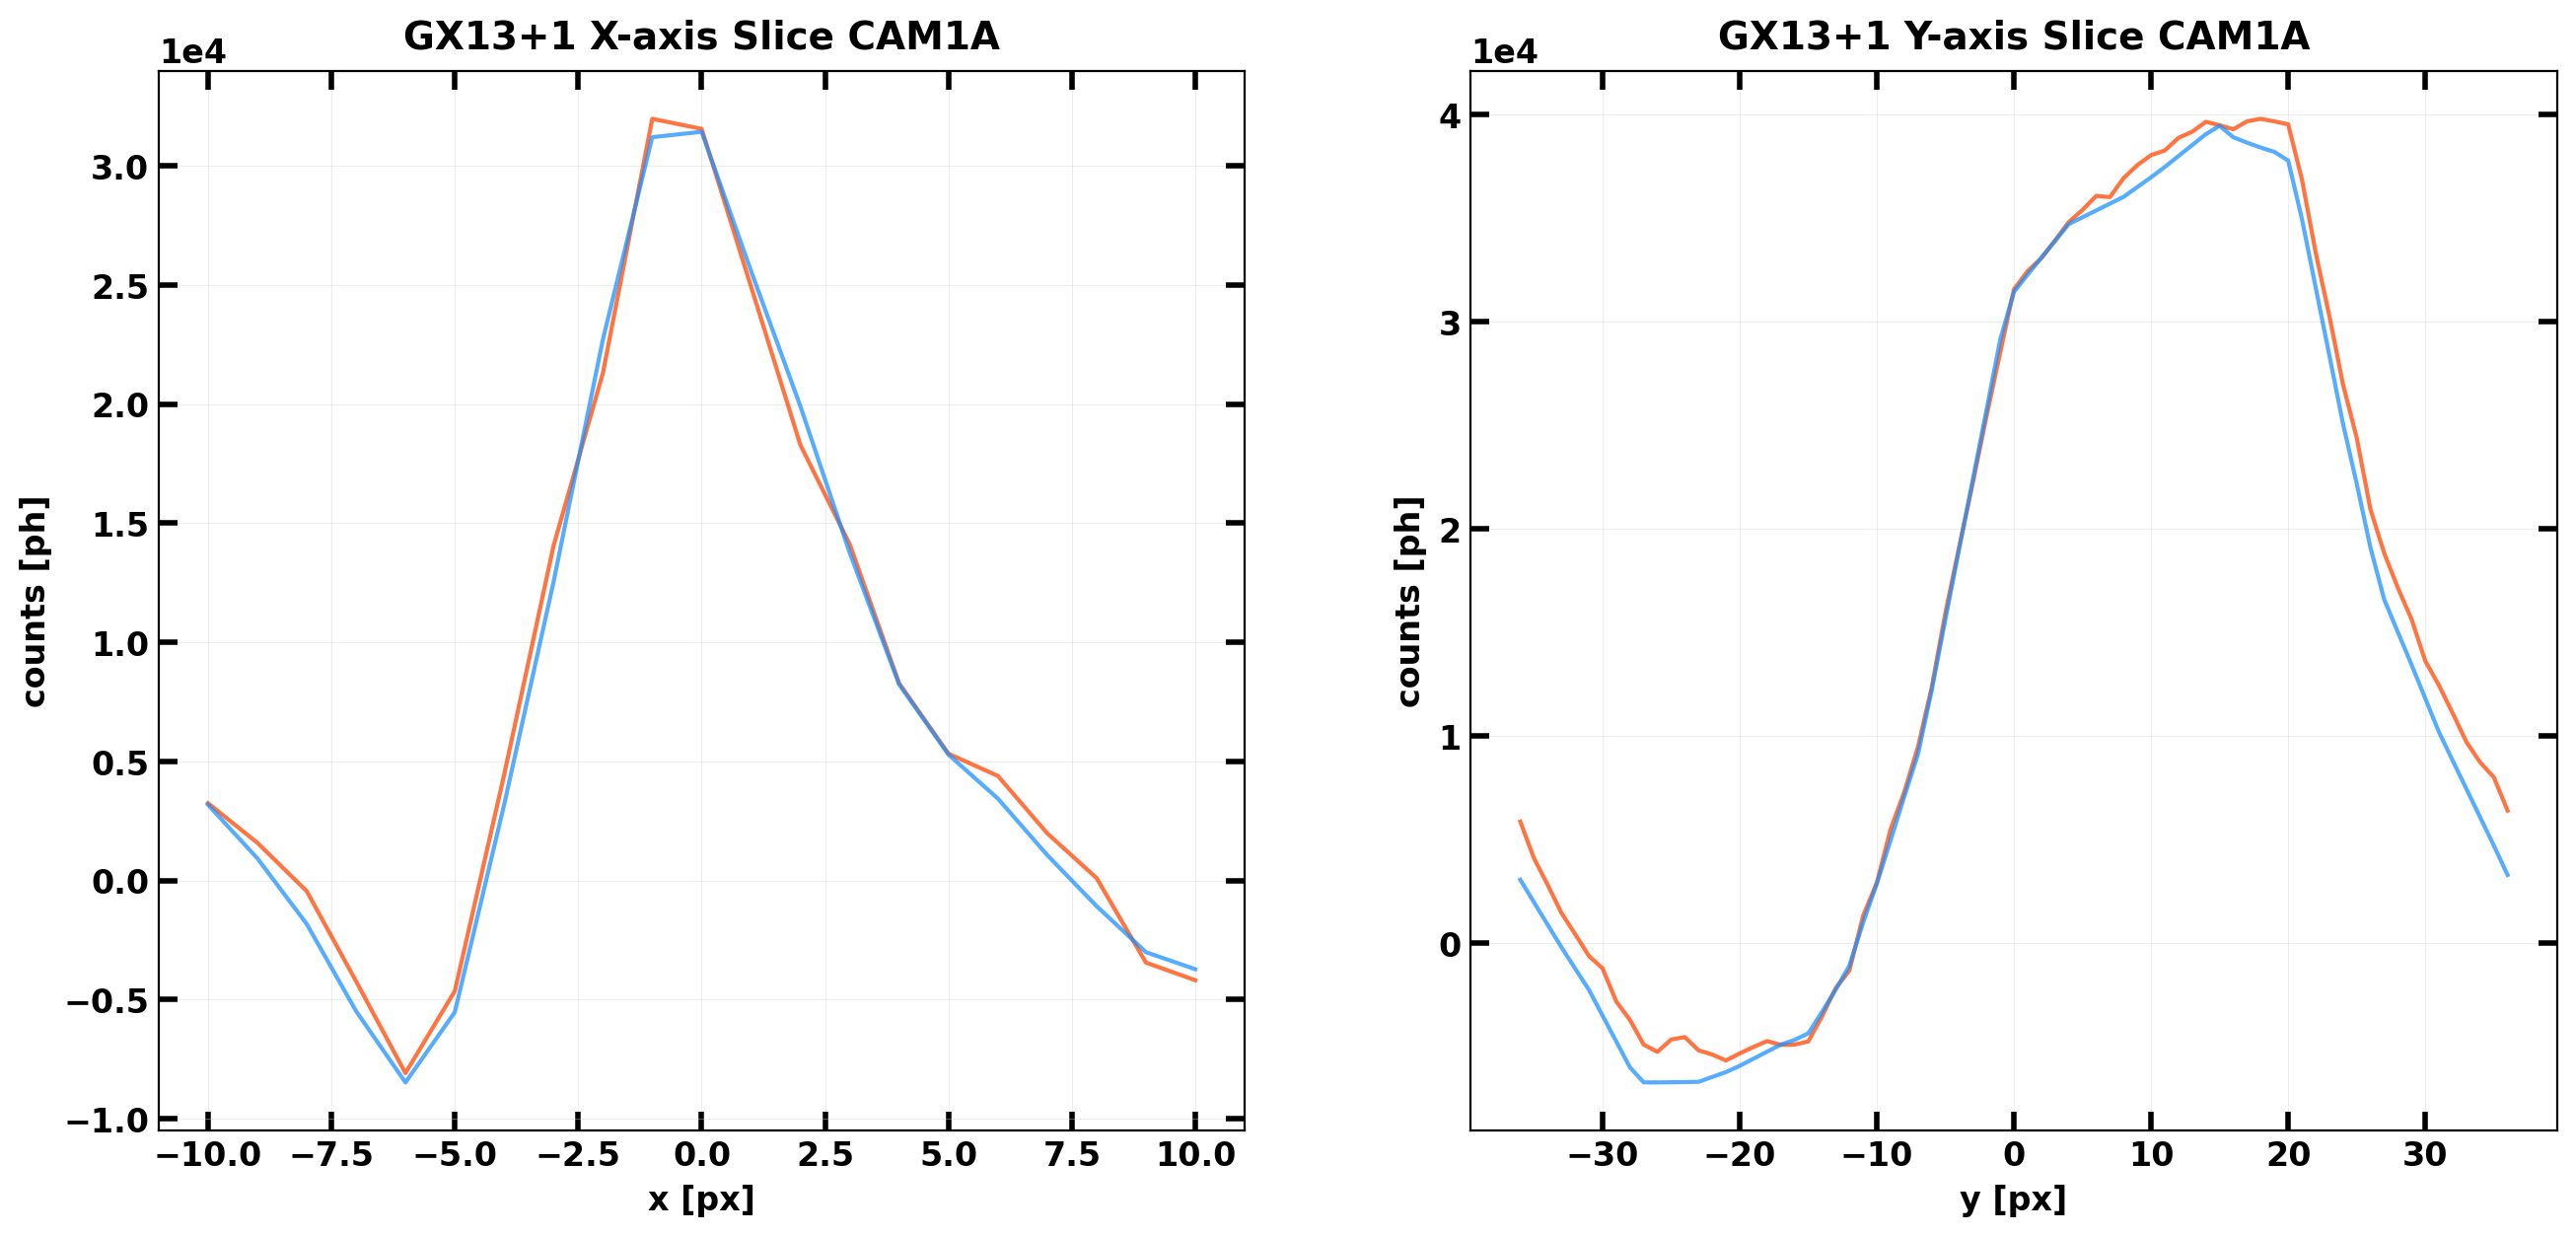

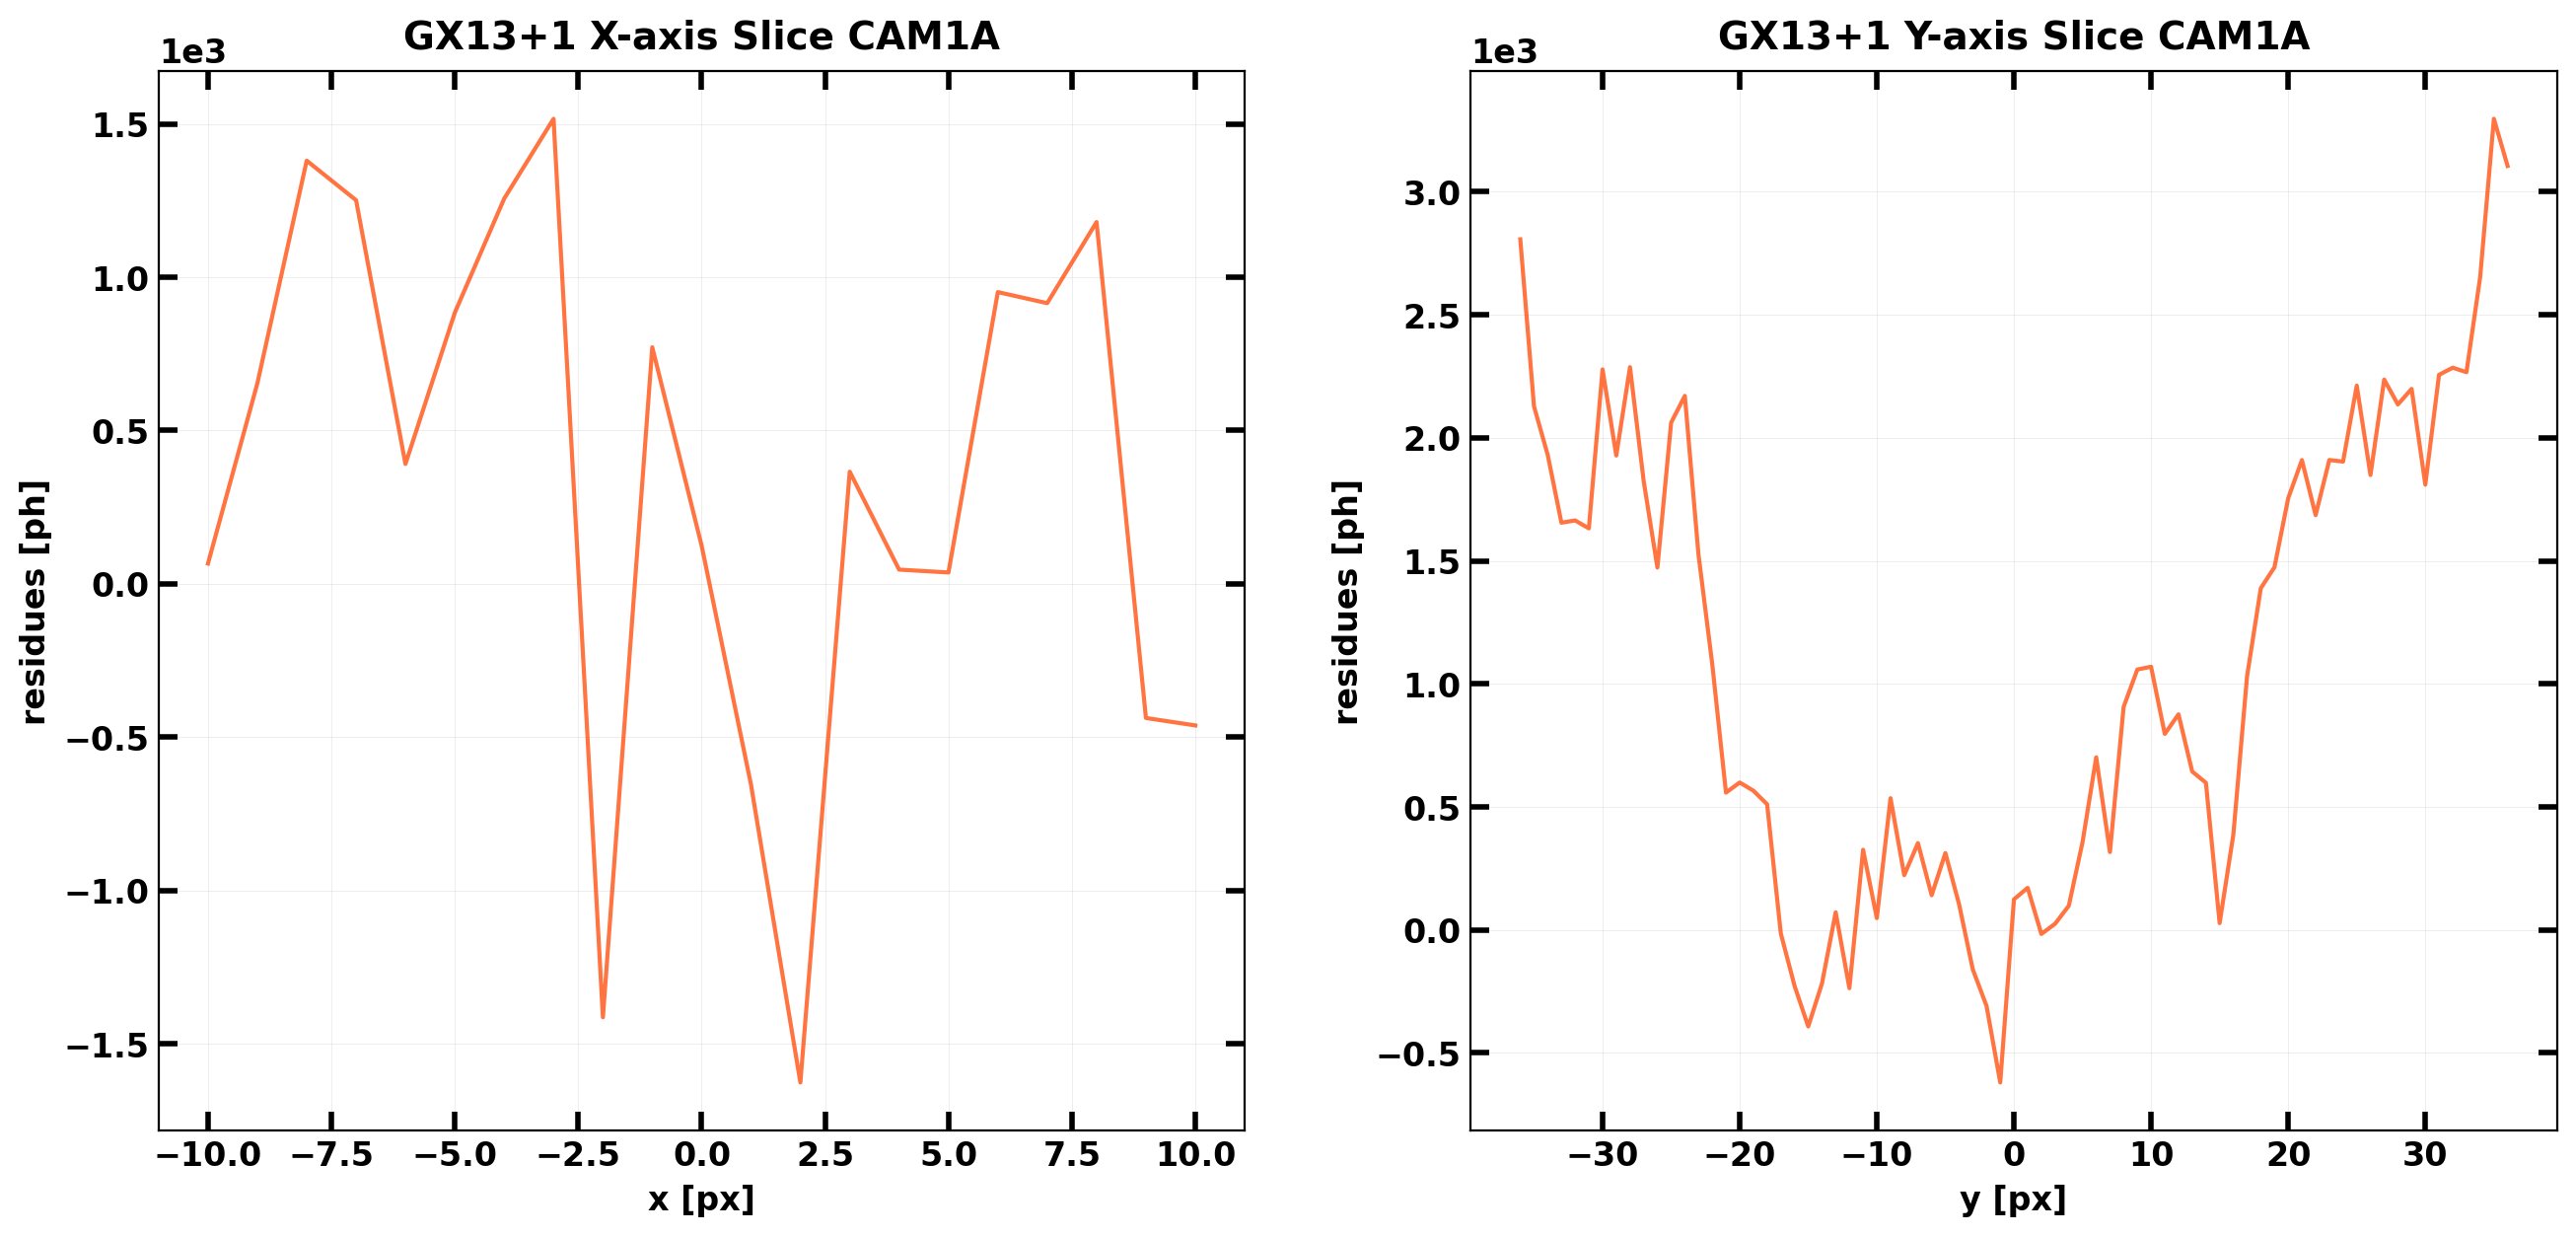

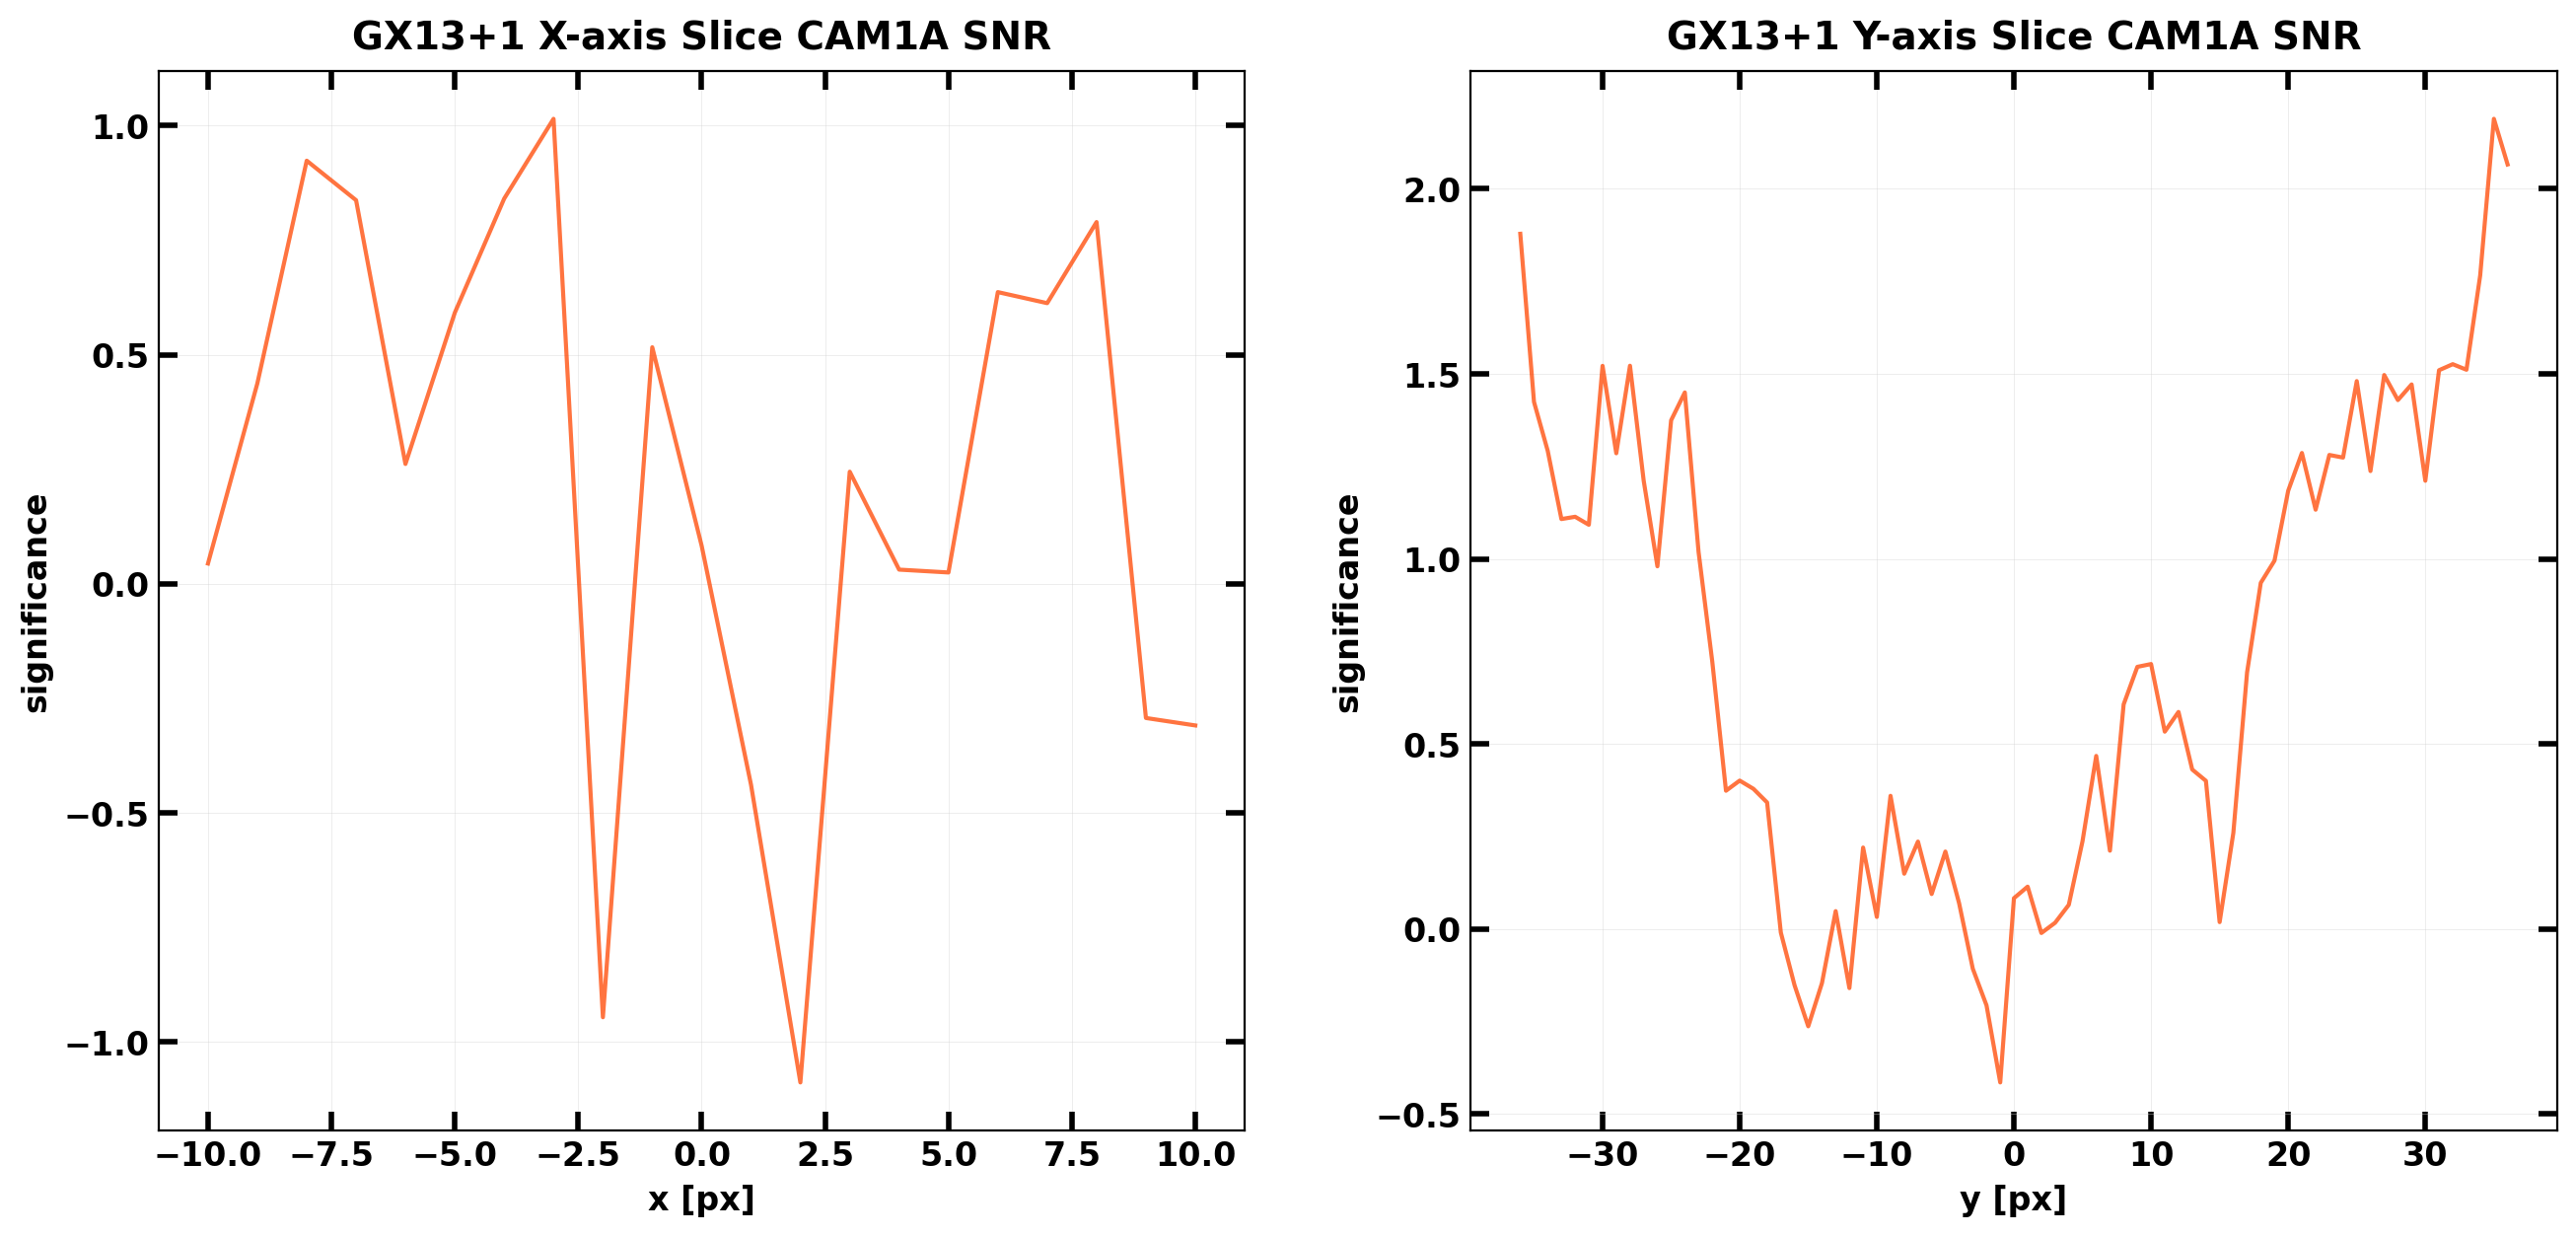

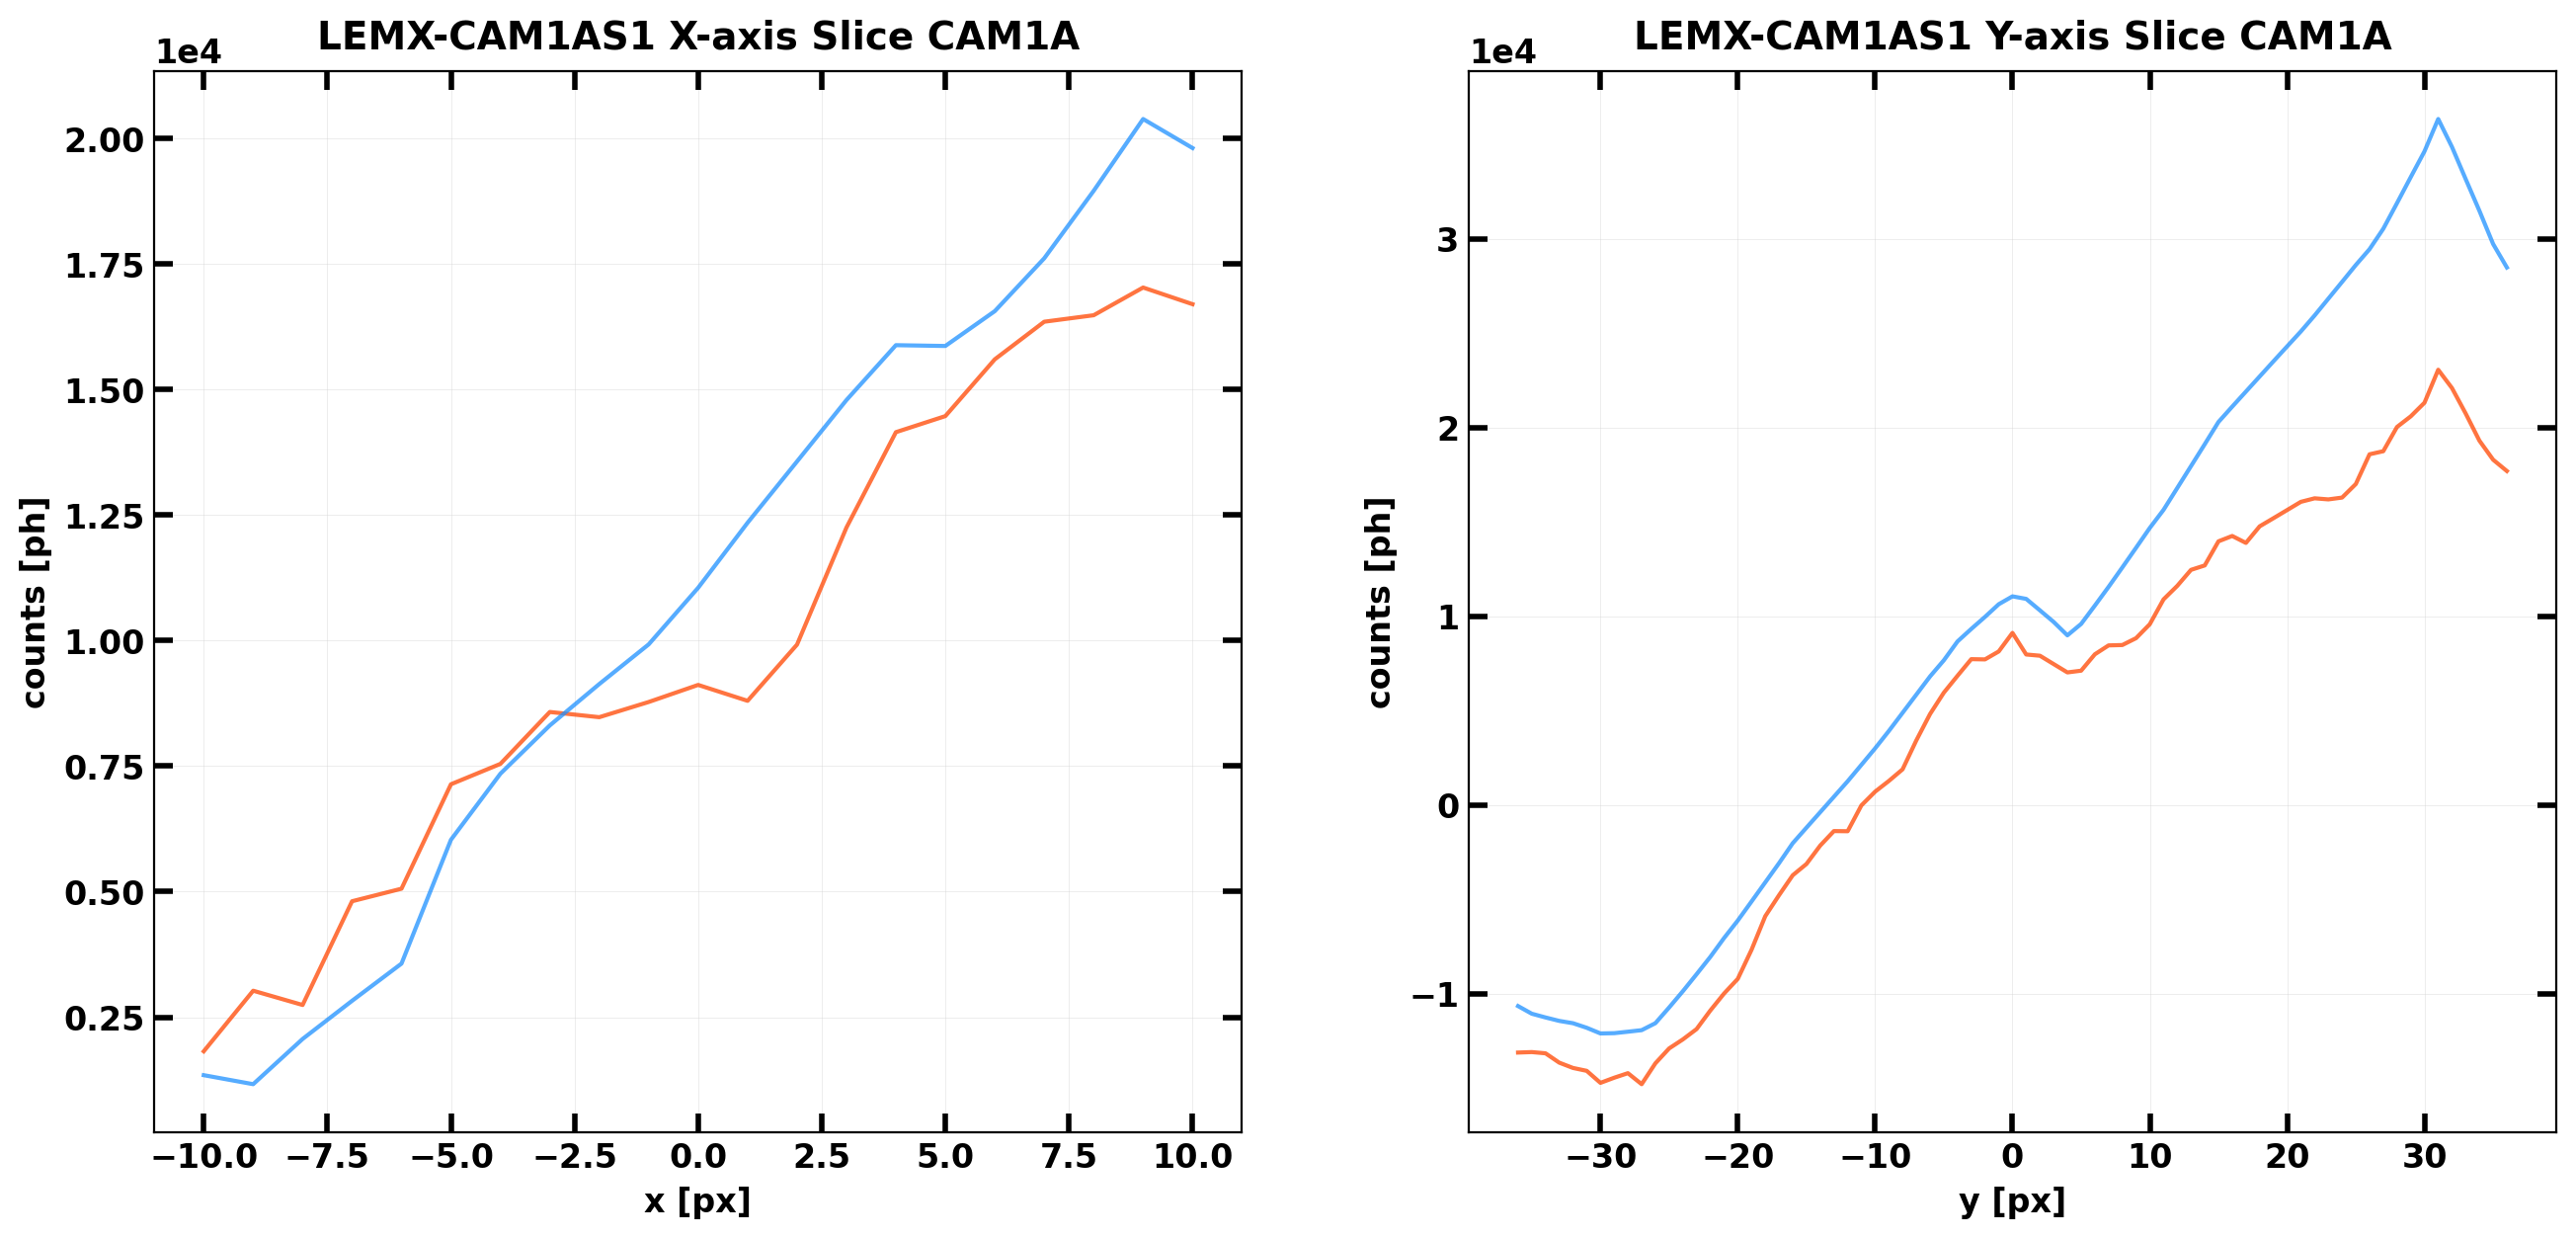

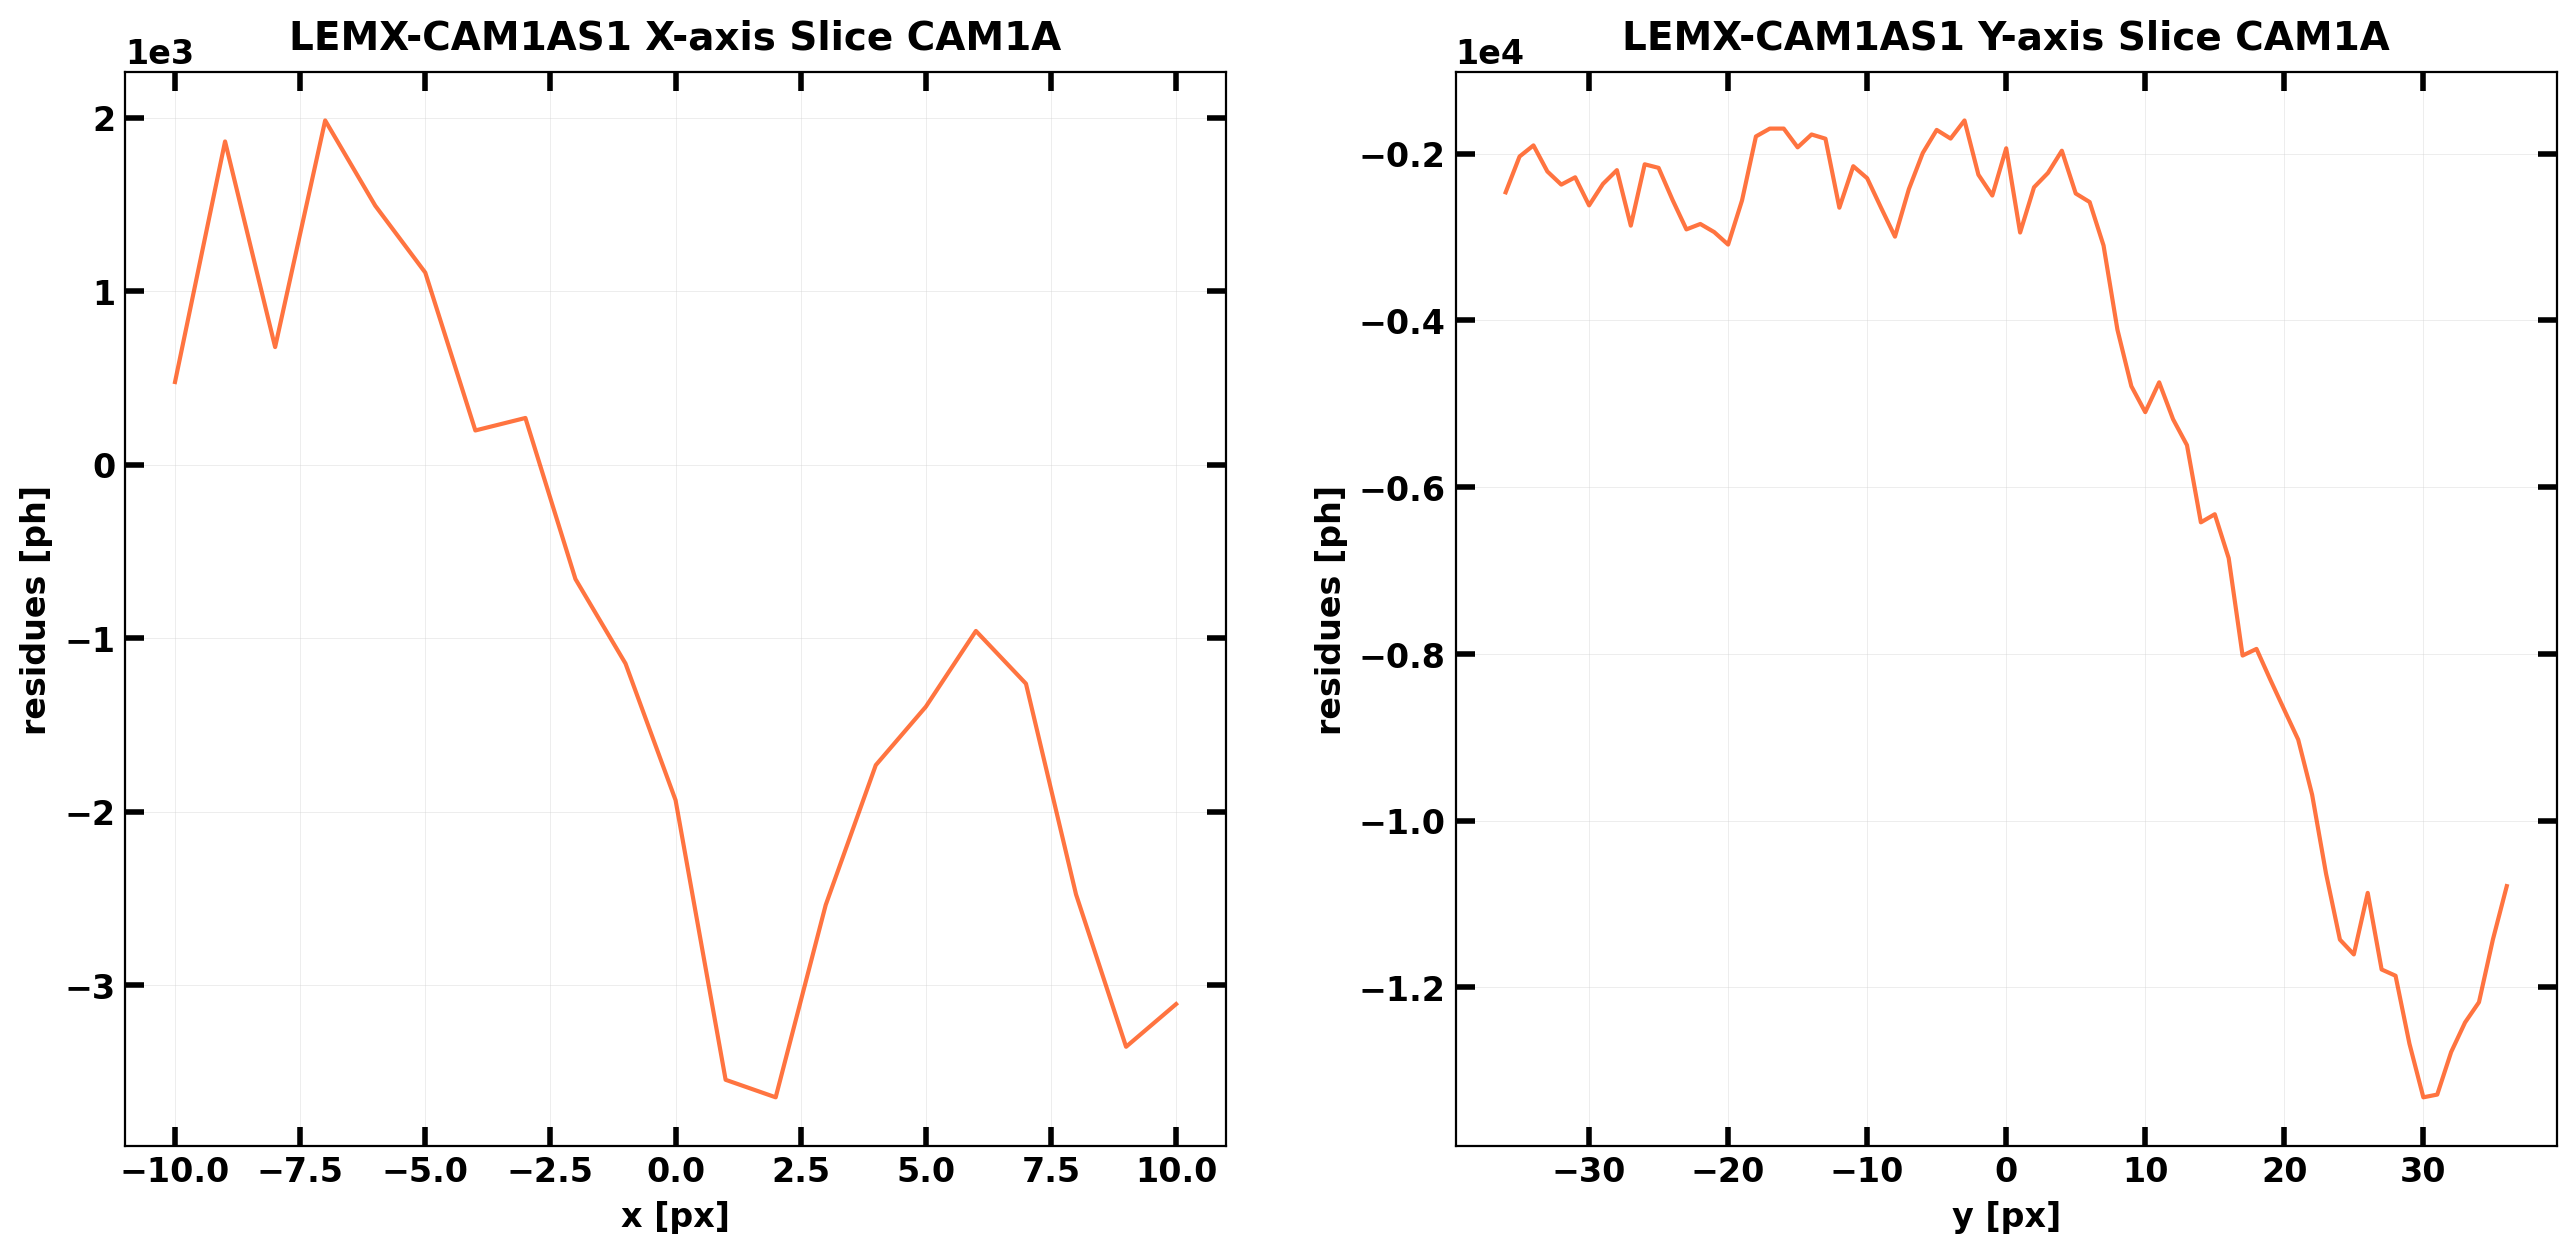

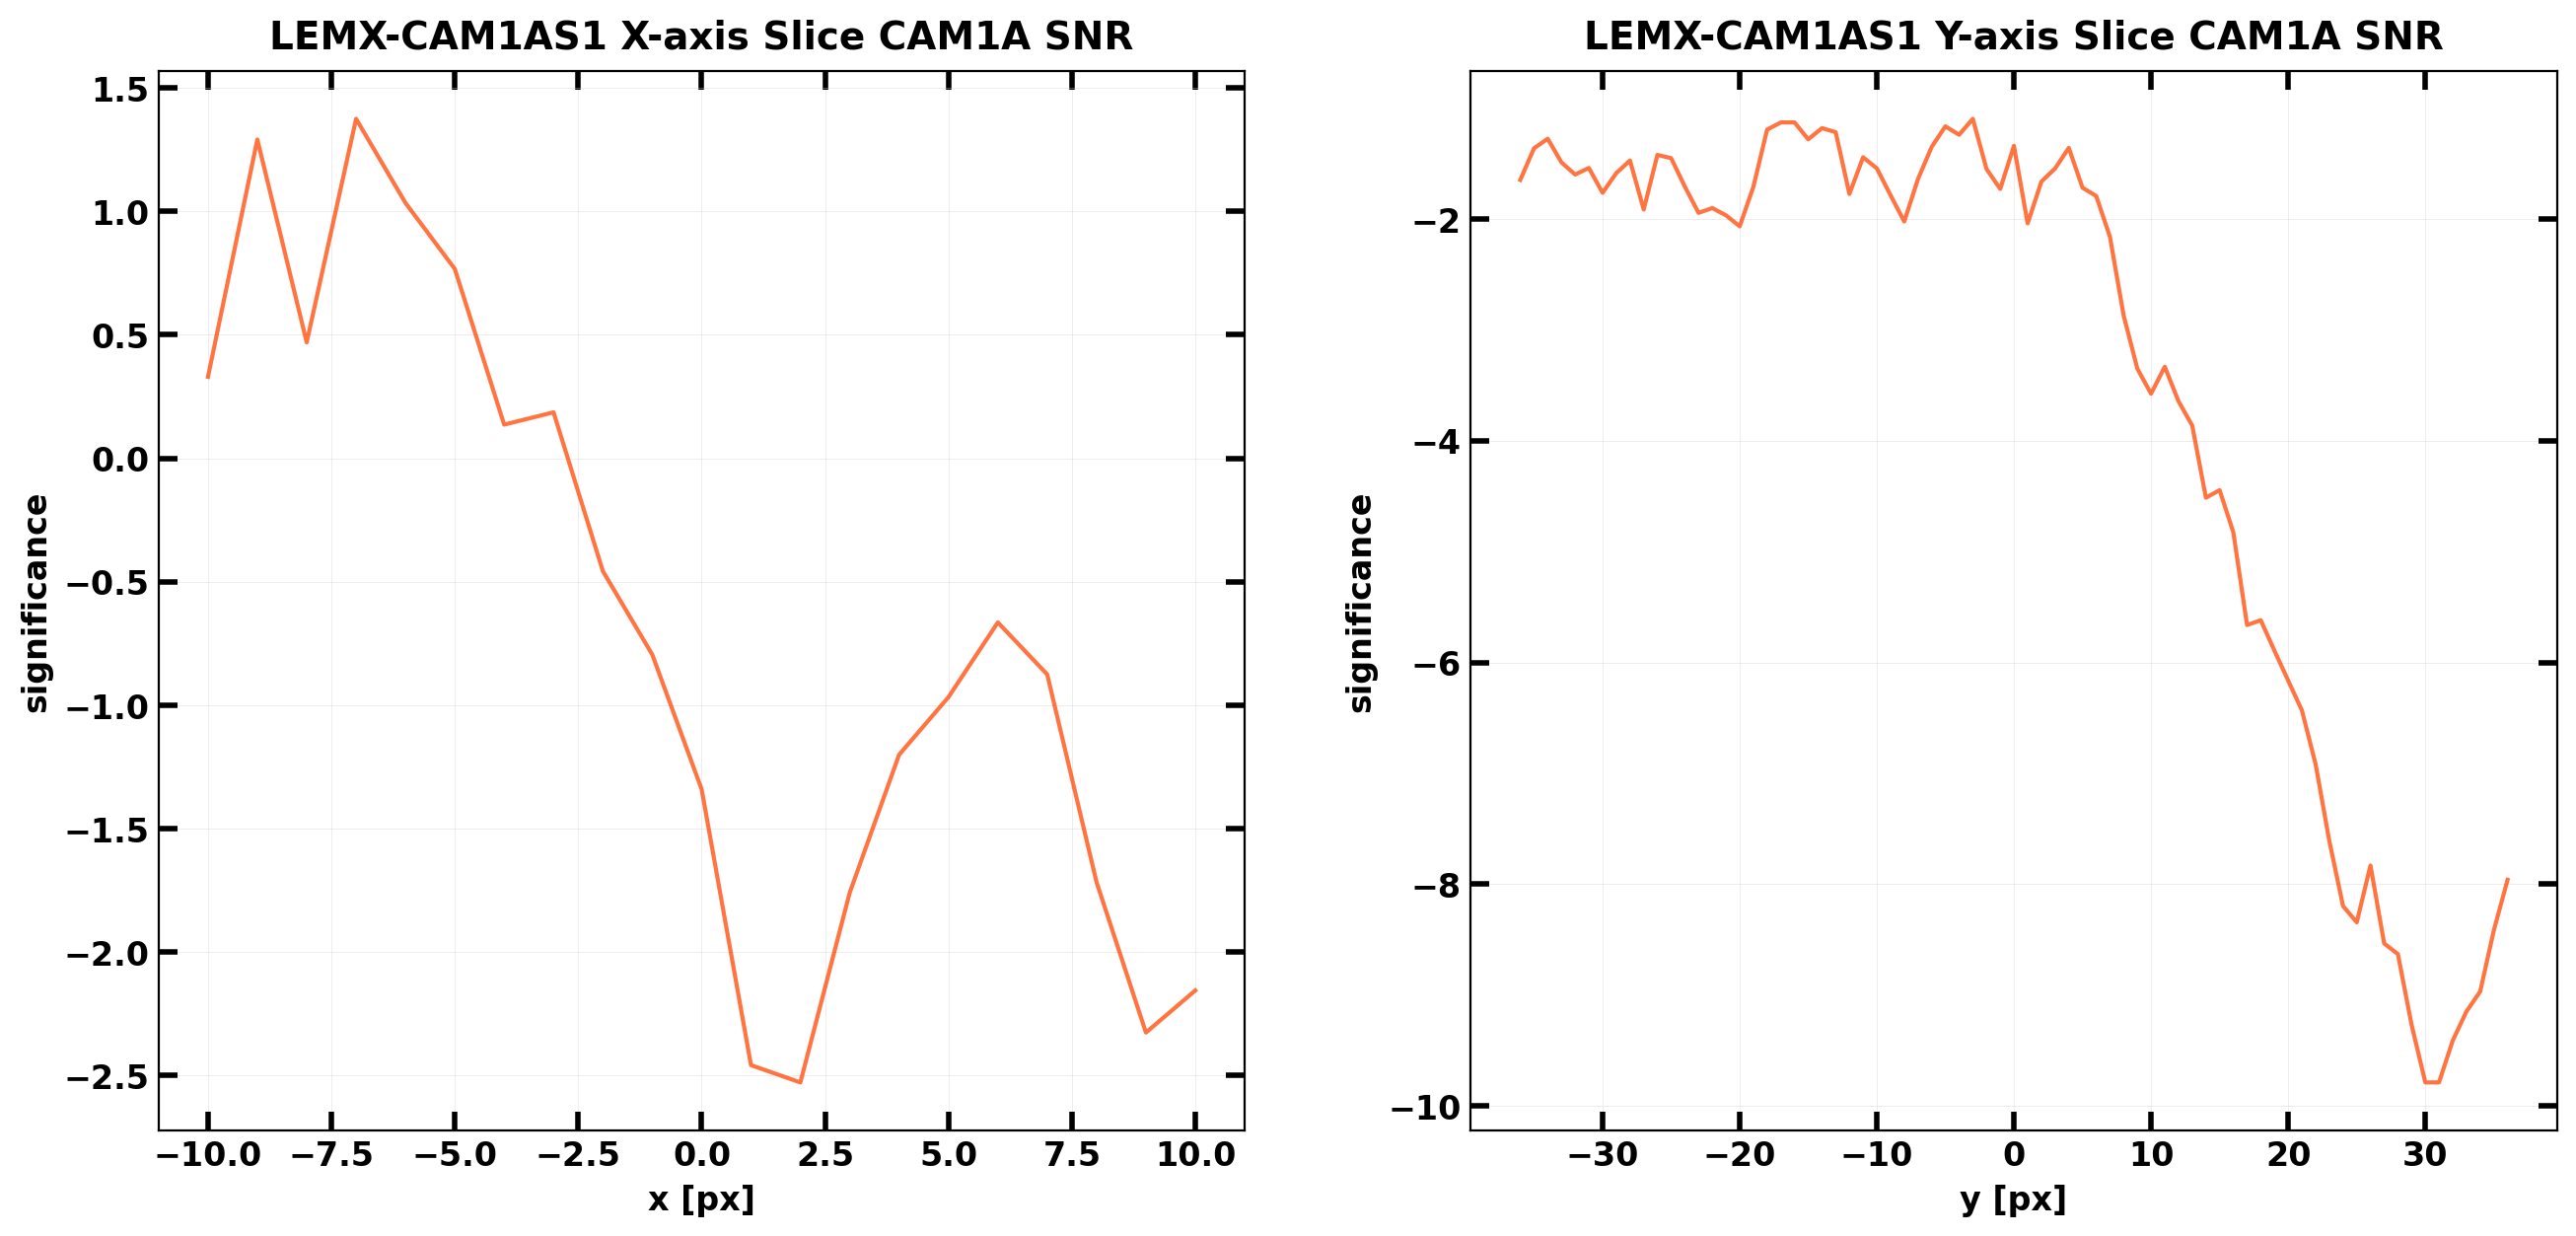

In [20]:
cropx, cropy = (
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
)

for tag in tags:
    ds.slices_plot(
        sky=(simul_sky_camA, retrieved_sky),
        pos=(tag.y, tag.x),
        crp=(cropy, cropx),
        source=tag.ID,
        ylabel='counts [ph]',
        cameraID=log_camA.name,
    )
    ds.slices_plot(
        sky=res_sky,
        pos=(tag.y, tag.x),
        crp=(cropy, cropx),
        source=tag.ID,
        ylabel='residues [ph]',
        cameraID=log_camA.name,
    )
    ds.slices_plot(
        sky=sky_significance(res_sky, varmap),
        pos=(tag.y, tag.x),
        crp=(cropy, cropx),
        source=tag.ID,
        ylabel='significance',
        cameraID=f'{log_camA.name} SNR',
    )